## 1. DATA LOAD

In [1]:
import json
from pathlib import Path

RESULT_DIR = Path("result")  # analysis.ipynb가 benchmark/ 안에 있다고 가정

# 집계 결과 (4 매핑 x 16 agent x 100 episode, compute_metrics() 출력)
with open(RESULT_DIR / "mapping_robustness_final.json", encoding="utf-8") as f:
    data = json.load(f)

MAPPINGS = data["config"]["mappings"]  # ["A_conservative", "B_moderate", "C_aggressive", "D_nonlinear"]
AGENTS = data["config"]["agents"]

# episode 원본 기록 (mapping별 jsonl, transcript/인용결함/outcome 등)
episodes_by_mapping = {}
for m in MAPPINGS:
    short = m.split("_")[0]  # "A_conservative" -> "A"
    path = RESULT_DIR / f"mapping_{short}_robustness_episodes.jsonl"
    with open(path, encoding="utf-8") as f:
        episodes_by_mapping[m] = [json.loads(line) for line in f]

print("mappings:", MAPPINGS)
print("agents:", len(AGENTS))
for m, eps in episodes_by_mapping.items():
    print(f"  {m}: {len(eps)} episodes")


mappings: ['A_conservative', 'B_moderate', 'C_aggressive', 'D_nonlinear']
agents: 16
  A_conservative: 1600 episodes
  B_moderate: 1600 episodes
  C_aggressive: 1600 episodes
  D_nonlinear: 1600 episodes


### 데이터 구조


#### 1. `mapping_robustness_final.json` — 집계 (4 매핑 × 16 agent × 100 episode 합산)

- **`config`**
  - `episodes_per_cell`: 100
  - `seed`: 1
  - `mappings`: `[A_conservative, B_moderate, C_aggressive, D_nonlinear]`
  - `agents`: 16개 라벨
- **`scores_by_mapping[mapping][agent]`** — agent가 그 매핑에서 100 episode 돌린 뒤 `compute_metrics()` 결과
  - `SE+` — 정규화 surplus (feasible episode 대상, headline 지표)
  - `AGR+` — feasible 중 합의 도달 비율
  - `CSE+` — 합의한 episode만 대상 SE+
  - `FAGR-` — infeasible인데 합의한 비율 (이 실험은 regime=overlap 고정이라 **항상 null**)
  - `CritViol%` — 프로토콜 위반 있었던 episode 비율
  - `citation_precision` — 언급한 결함 중 실제 결함 비율
  - `citation_coverage` — 실제 결함 중 언급한 비율 (recall)
  - `hallucination_rate` — 없는 결함을 지어낸 episode 비율
  - `utilization_proximity` — 결함 인용 턴에서 가격을 실제로 그 방향(양보)으로 움직였는가
  - `severity_calibration_rho` / `severity_calibration_n` — 인용 결함의 price_impact vs 실제 가격변동폭 상관, 표본수
  - `subtle_misaligned_gap` / `_n_caught` / `_n_missed` — Subtle-Misaligned 결함을 잡았을 때 vs 놓쳤을 때 CSE+ 차이
  - `detection_rate_{quadrant}` / `_n` — quadrant별 탐지율 (quadrant ∈ obvious_aligned / subtle_aligned / obvious_misaligned / subtle_misaligned)
  - `calibration_rho_{quadrant}` / `_n` — quadrant별 severity 보정 상관
- **`quadrant_scores_by_mapping[mapping][quadrant][agent]`** — 위와 동일한 dict, 그 quadrant에 속한 episode만으로 재계산 (+`n` 필드)
- **`overall_rho[metric][mapping쌍]`** — metric ∈ {`SE+`, `utilization_proximity`, `severity_calibration_rho`}, 매핑 6쌍(4C2) Spearman rho (전체 episode 기준)
- **`quadrant_rho[quadrant][metric][mapping쌍]`** — 위와 동일하되 quadrant별

#### 2. `mapping_{A,B,C,D}_robustness_episodes.jsonl` — 원본 episode 기록 (매핑당 1600줄 = 16 agent × 100 episode)

- (한 줄 = episode 하나)
  - `mapping`, `agent`, `family`, `regime`, `seed`, `episode_idx`
  - **`item`**
    - `category`, `title`, `listing_price`, `image_ref`
    - **`defects[]`** (아이템당 0~1개)
      - `id`, `description`, `defect_type`, `quadrant`, `severity`, `price_impact`
  - **`episode_config`**
    - `p_min`, `p_max`, `role_A`, `r_A` (agent 유보가격)
    - **`t_B`**: `r`, `urgency`, `stance` (상대방)
    - `opener`, `K` (최대 턴), `harshness`
  - **`transcript[]`** (턴별)
    - `turn`, `side`, `decision`, `price`, `message`, `sentiment`, `posture`, `cited_defect_ids`
  - **`violations[]`**
    - `turn`, `side`, `type`
  - `outcome` — 합의 가격(float) 또는 `None`(결렬)

## 2. DATA ANALYSIS

### Figure 1

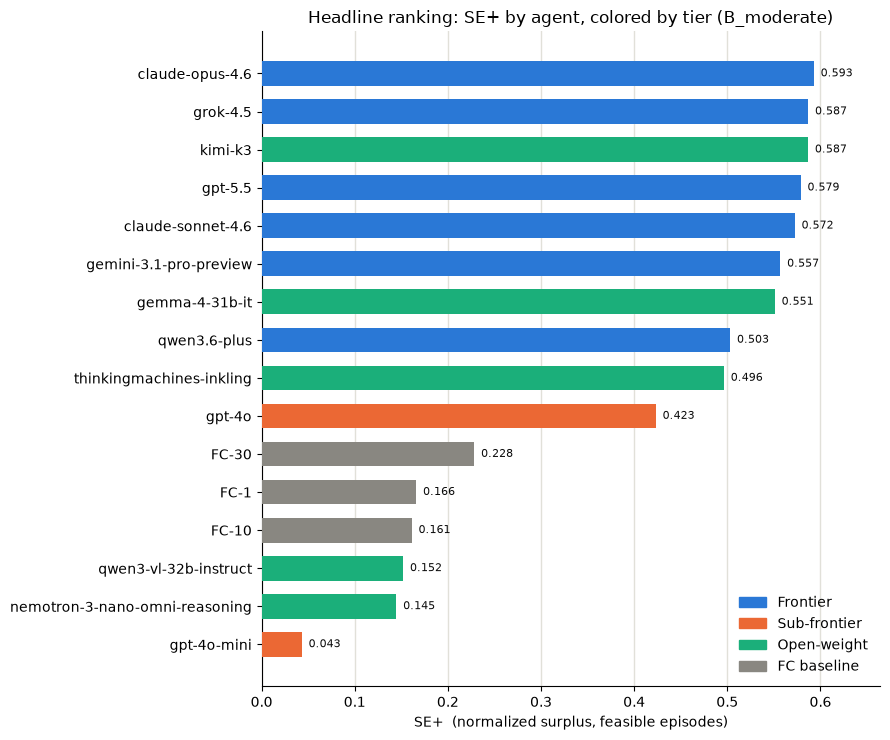

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

MAIN_MAPPING = "B_moderate"

TIER = {
    "FC-1": "FC baseline", "FC-10": "FC baseline", "FC-30": "FC baseline",
    "gpt-4o-mini": "Sub-frontier", "gpt-4o": "Sub-frontier",
    "gemma-4-31b-it": "Open-weight", "qwen3-vl-32b-instruct": "Open-weight",
    "thinkingmachines-inkling": "Open-weight", "nemotron-3-nano-omni-reasoning": "Open-weight",
    "kimi-k3": "Open-weight",
    "claude-opus-4.6": "Frontier", "claude-sonnet-4.6": "Frontier", "gemini-3.1-pro-preview": "Frontier",
    "gpt-5.5": "Frontier", "grok-4.5": "Frontier", "qwen3.6-plus": "Frontier",
}
TIER_COLOR = {
    "Frontier": "#2a78d6", "Sub-frontier": "#eb6834", "Open-weight": "#1baf7a", "FC baseline": "#898781",
}
GRID_COLOR = "#e1e0d9"

rows = sorted(((a, data["scores_by_mapping"][MAIN_MAPPING][a]["SE+"]) for a in AGENTS), key=lambda r: r[1])

fig, ax = plt.subplots(figsize=(9, 7.5))
labels = [r[0] for r in rows]
values = [r[1] for r in rows]
colors = [TIER_COLOR[TIER[a]] for a in labels]

bars = ax.barh(labels, values, color=colors, height=0.65, zorder=3)
for bar, v in zip(bars, values):
    ax.annotate(f"{v:.3f}", (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                textcoords="offset points", xytext=(5, 0), va="center", fontsize=8, color="#0b0b0b")

ax.set_xlabel("SE+  (normalized surplus, feasible episodes)")
ax.set_title(f"Headline ranking: SE+ by agent, colored by tier ({MAIN_MAPPING})", fontsize=12)
ax.grid(axis="x", color=GRID_COLOR, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max(values) * 1.12)

ax.legend(
    handles=[Patch(color=TIER_COLOR[t], label=t) for t in ["Frontier", "Sub-frontier", "Open-weight", "FC baseline"]],
    loc="lower right", frameon=False,
)
plt.tight_layout()
plt.show()


### table 2

In [3]:
import random
from metrics import spearman_rho
import pandas as pd  # 프로젝트에 이미 있는 구현 재사용

MAIN_MAPPING = "B_moderate"
LOWER_IS_BETTER = {"FAGR-", "CritViol%", "hallucination_rate"}
B = 2000  # 논문과 동일한 부트스트랩 반복 수

by_agent = {}
for rec in episodes_by_mapping[MAIN_MAPPING]:
    by_agent.setdefault(rec["agent"], []).append(rec)

# --- episode 단위 빌더 (앞서 검증한 episode_se_value와 같은 패턴) ---
def episode_se(rec):
    cfg = rec["episode_config"]
    role_A, r_A, r_B = cfg["role_A"], cfg["r_A"], cfg["t_B"]["r"]
    r_buyer = r_A if role_A == "BUYER" else r_B
    r_seller = r_B if role_A == "BUYER" else r_A
    delta = r_buyer - r_seller
    outcome = rec["outcome"]
    u = 0.0 if outcome is None else ((r_A - outcome) if role_A == "BUYER" else (outcome - r_A))
    return u / delta if delta else None

def is_agreed(rec):
    return rec["outcome"] is not None

def has_violation(rec):
    return bool(rec["violations"])

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

def ground_truth_types(rec):
    return {d["defect_type"] for d in rec["item"]["defects"]}

def calibration_pairs(rec):
    """단일 인용 turn에서 (price_impact, |가격변화|/R) 쌍 -- metrics.py의 _severity_calibration_pairs와 동일 로직."""
    defect_by_type = {d["defect_type"]: d for d in rec["item"]["defects"]}
    R = rec["episode_config"]["p_max"] - rec["episode_config"]["p_min"]
    prev_price = None
    pairs = []
    for t in rec["transcript"]:
        if t["side"] != "agent" or t["decision"] != "OFFER":
            continue
        cited = t.get("cited_defect_ids") or []
        if len(cited) == 1 and prev_price is not None and cited[0] in defect_by_type:
            d = defect_by_type[cited[0]]
            pairs.append((d["price_impact"], abs(t["price"] - prev_price) / R))
        prev_price = t["price"]
    return pairs

# --- 집계 지표 (episode 리스트 -> 값), 각각 metrics.py의 대응 함수와 동일 정의 ---
def stat_se_plus(s):
    vals = [v for r in s if (v := episode_se(r)) is not None]
    return sum(vals) / len(vals) if vals else None

def stat_agr_plus(s):
    return sum(is_agreed(r) for r in s) / len(s) if s else None

def stat_cse_plus(s):
    vals = [episode_se(r) for r in s if is_agreed(r)]
    return sum(vals) / len(vals) if vals else None

def stat_crit_viol_pct(s):
    return sum(has_violation(r) for r in s) / len(s) if s else None

def stat_hallucination_rate(s):
    flagged = sum(1 for r in s if agent_citations(r) - ground_truth_types(r))
    return flagged / len(s) if s else None

def stat_citation_coverage(s):
    scored = []
    for r in s:
        D = ground_truth_types(r)
        if not D:
            continue
        scored.append(len(agent_citations(r) & D) / len(D))
    return sum(scored) / len(scored) if scored else None

def stat_severity_calibration_rho(s):
    xs, ys = [], []
    for r in s:
        for x, y in calibration_pairs(r):
            xs.append(x); ys.append(y)
    return spearman_rho(xs, ys) if xs else None

STATS = {
    "SE+": stat_se_plus, "AGR+": stat_agr_plus, "CSE+": stat_cse_plus,
    "CritViol%": stat_crit_viol_pct, "hallucination_rate": stat_hallucination_rate,
    "citation_coverage": stat_citation_coverage, "severity_calibration_rho": stat_severity_calibration_rho,
}

# --- 에피소드 단위 블록 부트스트랩 (턴을 낱개로 안 섞고 episode를 통째로 복원추출) ---
random.seed(0)
point = {}   # point[agent][metric] = 원본 표본 그대로의 값
ci_lo = {}
ci_hi = {}
for a in AGENTS:
    sample = by_agent[a]
    n = len(sample)
    point[a] = {name: fn(sample) for name, fn in STATS.items()}
    ci_lo[a], ci_hi[a] = {}, {}
    for name, fn in STATS.items():
        boot = sorted(v for _ in range(B) if (v := fn([sample[random.randrange(n)] for _ in range(n)])) is not None)
        if boot:
            ci_lo[a][name] = boot[int(0.025 * len(boot))]
            ci_hi[a][name] = boot[int(0.975 * len(boot))]
        else:
            ci_lo[a][name] = ci_hi[a][name] = None

TABLE_METRICS = ["SE+", "AGR+", "CSE+", "FAGR-", "CritViol%", "hallucination_rate", "citation_coverage", "severity_calibration_rho"]
for a in AGENTS:
    point[a]["FAGR-"] = None  # regime=overlap 고정이라 항상 정의 안 됨 (모든 agent 동일)
    ci_lo[a]["FAGR-"] = ci_hi[a]["FAGR-"] = None

# --- 표시용 문자열 표 + 순위용 숫자 표 ---
agents_sorted = sorted(AGENTS, key=lambda a: point[a]["SE+"], reverse=True)

def fmt(a, m):
    p, lo, hi = point[a].get(m), ci_lo[a].get(m), ci_hi[a].get(m)
    if p is None:
        return "–"
    if lo is None:
        return f"{p:.3f}"
    return f"{p:.3f} [{lo:.3f}, {hi:.3f}]"

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
EVIDENCE_METRICS = {"hallucination_rate", "citation_coverage", "severity_calibration_rho"}
for a in BASELINE_AGENTS:
    for m in EVIDENCE_METRICS:
        point[a][m] = None
        ci_lo[a][m] = ci_hi[a][m] = None


display_table = pd.DataFrame(
    {m: [fmt(a, m) for a in agents_sorted] for m in TABLE_METRICS}, index=agents_sorted,
)
numeric_table = pd.DataFrame(
    {m: [point[a][m] for a in agents_sorted] for m in TABLE_METRICS}, index=agents_sorted,
)

def highlight_top2(col):
    lower_better = col.name in LOWER_IS_BETTER
    ranked = numeric_table[col.name].rank(method="min", ascending=lower_better)
    return ["font-weight: bold" if r <= 2 else "" for r in ranked]

display_table.style.apply(highlight_top2, axis=0)


,SE+,AGR+,CSE+,FAGR-,CritViol%,hallucination_rate,citation_coverage,severity_calibration_rho
claude-opus-4.6,"0.593 [0.524, 0.663]","0.860 [0.790, 0.920]","0.689 [0.630, 0.751]",–,"0.020 [0.000, 0.050]","0.410 [0.320, 0.510]","0.456 [0.345, 0.566]","0.803 [0.471, 0.933]"
grok-4.5,"0.587 [0.517, 0.654]","0.890 [0.820, 0.950]","0.659 [0.602, 0.718]",–,"0.030 [0.000, 0.070]","0.270 [0.190, 0.360]","0.468 [0.360, 0.581]","0.659 [0.389, 0.784]"
kimi-k3,"0.587 [0.513, 0.660]","0.810 [0.730, 0.880]","0.724 [0.674, 0.778]",–,"0.000 [0.000, 0.000]","0.300 [0.210, 0.390]","0.304 [0.203, 0.407]","0.656 [0.049, 0.923]"
gpt-5.5,"0.579 [0.511, 0.645]","0.940 [0.890, 0.980]","0.616 [0.550, 0.677]",–,"0.040 [0.010, 0.080]","0.200 [0.120, 0.280]","0.430 [0.321, 0.537]","0.701 [0.449, 0.820]"
claude-sonnet-4.6,"0.572 [0.507, 0.637]","0.900 [0.840, 0.950]","0.636 [0.576, 0.696]",–,"0.040 [0.010, 0.080]","0.490 [0.390, 0.590]","0.544 [0.434, 0.653]","0.692 [0.448, 0.827]"
gemini-3.1-pro-preview,"0.557 [0.487, 0.625]","0.840 [0.760, 0.910]","0.663 [0.601, 0.725]",–,"0.000 [0.000, 0.000]","0.290 [0.210, 0.380]","0.544 [0.430, 0.654]","0.728 [0.500, 0.824]"
gemma-4-31b-it,"0.551 [0.483, 0.623]","0.840 [0.760, 0.910]","0.656 [0.593, 0.718]",–,"0.010 [0.000, 0.030]","0.150 [0.090, 0.220]","0.228 [0.134, 0.321]","0.659 [0.171, 0.815]"
qwen3.6-plus,"0.503 [0.440, 0.570]","0.940 [0.890, 0.980]","0.535 [0.471, 0.598]",–,"0.020 [0.000, 0.050]","0.360 [0.270, 0.450]","0.557 [0.449, 0.662]","0.758 [0.501, 0.871]"
thinkingmachines-inkling,"0.496 [0.432, 0.559]","0.940 [0.890, 0.980]","0.528 [0.461, 0.591]",–,"0.040 [0.010, 0.080]","0.560 [0.460, 0.660]","0.494 [0.383, 0.605]","0.756 [0.457, 0.883]"
gpt-4o,"0.423 [0.344, 0.504]","0.870 [0.800, 0.930]","0.486 [0.396, 0.572]",–,"0.170 [0.100, 0.250]","0.320 [0.230, 0.420]","0.519 [0.405, 0.632]","0.591 [0.377, 0.726]"


### Figure 4

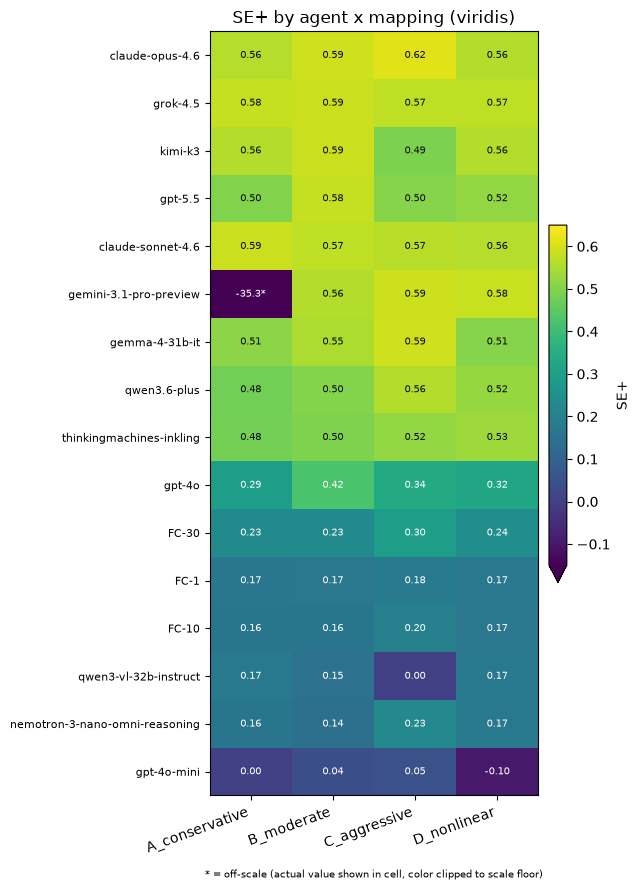

In [4]:
import numpy as np
import matplotlib.pyplot as plt

order = sorted(AGENTS, key=lambda a: data["scores_by_mapping"]["B_moderate"][a]["SE+"], reverse=True)
mat = np.array([[data["scores_by_mapping"][m][a]["SE+"] for m in MAPPINGS] for a in order])

VMIN, VMAX = -0.15, 0.65  # A_conservative의 gemini-3.1-pro-preview 이상치(-35.26) 제외한 범위로 색 스케일 고정
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(6.5, 9))
im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=VMIN, vmax=VMAX)

ax.set_xticks(range(len(MAPPINGS)))
ax.set_xticklabels(MAPPINGS, rotation=20, ha="right")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
ax.set_title("SE+ by agent x mapping (viridis)", fontsize=12)

norm_vals = np.clip((mat - VMIN) / (VMAX - VMIN), 0, 1)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        r, g, b, _ = cmap(norm_vals[i, j])
        luminance = 0.299 * r + 0.587 * g + 0.114 * b  # 셀 배경 실제 밝기로 글자색 대비 판단
        txt_color = "#0b0b0b" if luminance > 0.6 else "#ffffff"
        label = f"{mat[i, j]:.2f}" if mat[i, j] >= VMIN else f"{mat[i, j]:.1f}*"
        ax.text(j, i, label, ha="center", va="center", fontsize=7.5, color=txt_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.03, extend="min")
cbar.set_label("SE+")
ax.set_xlabel("* = off-scale (actual value shown in cell, color clipped to scale floor)", fontsize=7.5, labelpad=10)
plt.tight_layout()
plt.show()


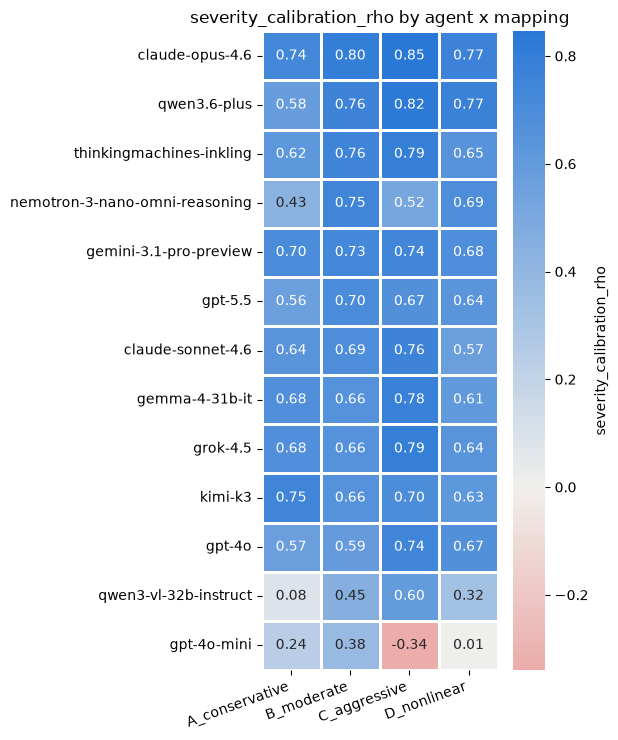

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]  # FC는 이 지표가 구조적으로 항상 None이라 제외

order = sorted(llm_agents, key=lambda a: data["scores_by_mapping"]["B_moderate"][a]["severity_calibration_rho"], reverse=True)
mat = pd.DataFrame(
    [[data["scores_by_mapping"][m][a]["severity_calibration_rho"] for m in MAPPINGS] for a in order],
    index=order, columns=MAPPINGS,
)

# 팔레트 발산형 blue<->red(dataviz 스킬 references/palette.md), 중립 회색 중점 -- 상관계수라
# 0(무상관)을 중심으로 +(잘 보정됨)/-(거꾸로 보정됨)가 갈리는 게 자연스러운 표현
div_cmap = LinearSegmentedColormap.from_list("div_blue_red", ["#e34948", "#f0efec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(6, 7.5))
sns.heatmap(
    mat, annot=True, fmt=".2f", cmap=div_cmap, center=0,
    linewidths=1, linecolor="white", cbar_kws={"label": "severity_calibration_rho"}, ax=ax,
)
ax.set_title("severity_calibration_rho by agent x mapping", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()


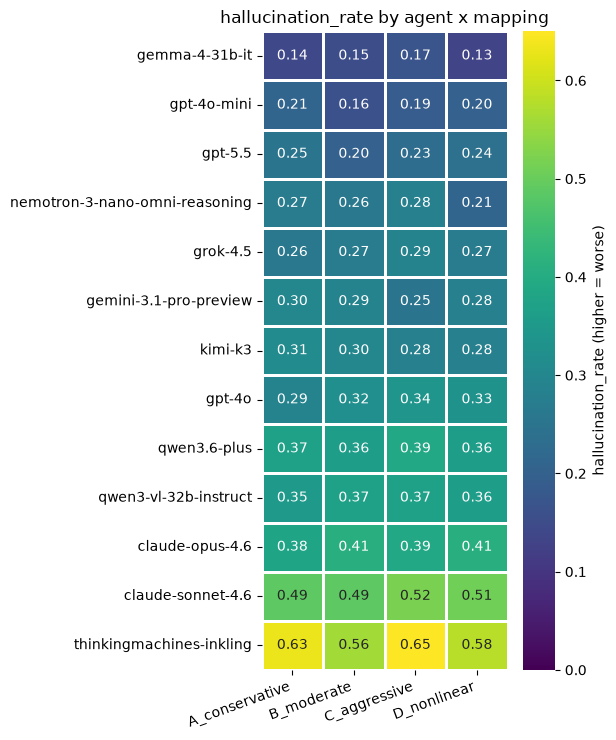

In [6]:
BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]  # FC는 인용을 아예 안 해서 hallucination_rate가 항상 0 -- 해당 없음 취급

order = sorted(llm_agents, key=lambda a: data["scores_by_mapping"]["B_moderate"][a]["hallucination_rate"])
mat = pd.DataFrame(
    [[data["scores_by_mapping"][m][a]["hallucination_rate"] for m in MAPPINGS] for a in order],
    index=order, columns=MAPPINGS,
)

fig, ax = plt.subplots(figsize=(6, 7.5))
sns.heatmap(
    mat, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=mat.values.max(),
    linewidths=1, linecolor="white", cbar_kws={"label": "hallucination_rate (higher = worse)"}, ax=ax,
)
ax.set_title("hallucination_rate by agent x mapping", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()


### figure 6


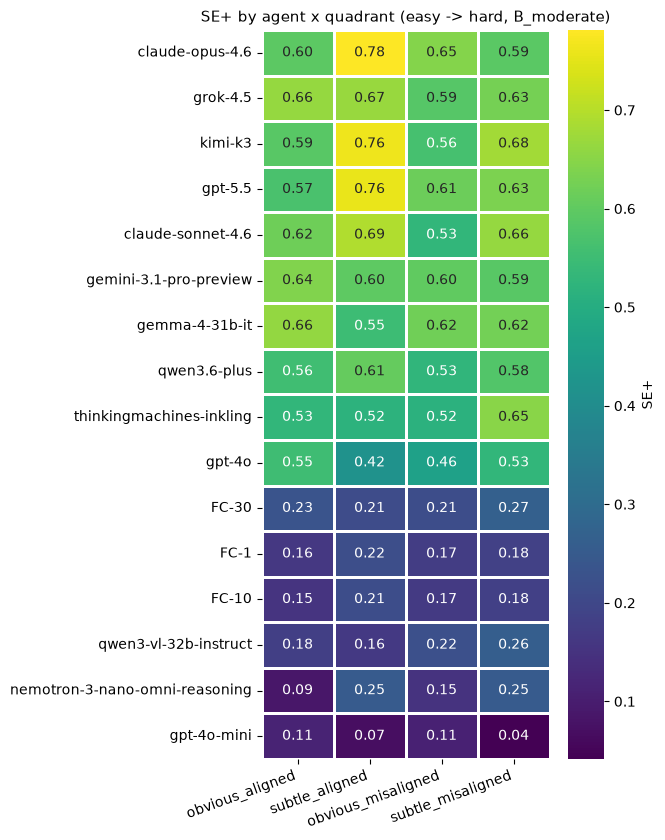

obvious_aligned vs subtle_aligned          0.752941
obvious_aligned vs obvious_misaligned      0.905882
obvious_aligned vs subtle_misaligned       0.761765
subtle_aligned vs obvious_misaligned       0.835294
subtle_aligned vs subtle_misaligned        0.820588
obvious_misaligned vs subtle_misaligned    0.758824
dtype: float64

In [7]:
import itertools

QUADRANTS = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]  # easy -> hard
MAIN_MAPPING = "B_moderate"

order = sorted(AGENTS, key=lambda a: data["scores_by_mapping"][MAIN_MAPPING][a]["SE+"], reverse=True)
mat = pd.DataFrame(
    [[data["quadrant_scores_by_mapping"][MAIN_MAPPING][q][a]["SE+"] for q in QUADRANTS] for a in order],
    index=order, columns=QUADRANTS,
)

fig, ax = plt.subplots(figsize=(6.5, 8.5))
sns.heatmap(
    mat, annot=True, fmt=".2f", cmap="viridis", vmin=mat.values.min(), vmax=mat.values.max(),
    linewidths=1, linecolor="white", cbar_kws={"label": "SE+"}, ax=ax,
)
ax.set_title("SE+ by agent x quadrant (easy -> hard, B_moderate)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

vecs = {q: [data["quadrant_scores_by_mapping"][MAIN_MAPPING][q][a]["SE+"] for a in AGENTS] for q in QUADRANTS}
quadrant_rho = pd.Series(
    {f"{q1} vs {q2}": spearman_rho(vecs[q1], vecs[q2]) for q1, q2 in itertools.combinations(QUADRANTS, 2)}
)
quadrant_rho


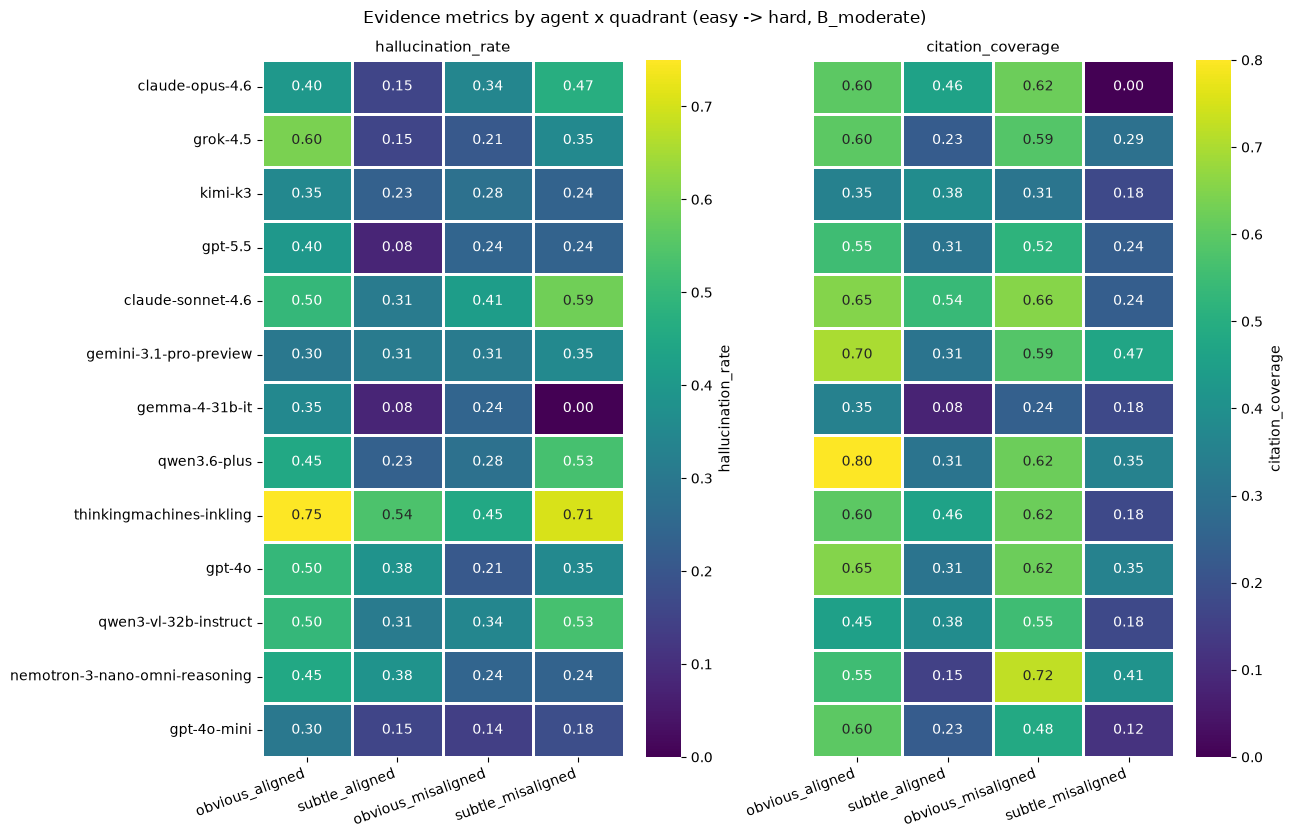

In [8]:
BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]
QUADRANTS = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]
MAIN_MAPPING = "B_moderate"

order = sorted(llm_agents, key=lambda a: data["scores_by_mapping"][MAIN_MAPPING][a]["SE+"], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 8.5))
for ax, metric in zip(axes, ["hallucination_rate", "citation_coverage"]):
    mat = pd.DataFrame(
        [[data["quadrant_scores_by_mapping"][MAIN_MAPPING][q][a][metric] for q in QUADRANTS] for a in order],
        index=order, columns=QUADRANTS,
    )
    sns.heatmap(
        mat, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=mat.values.max(),
        linewidths=1, linecolor="white", cbar_kws={"label": metric}, ax=ax,
        yticklabels=(ax is axes[0]),
    )
    ax.set_title(metric, fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")

fig.suptitle("Evidence metrics by agent x quadrant (easy -> hard, B_moderate)", fontsize=12)
plt.tight_layout()
plt.show()


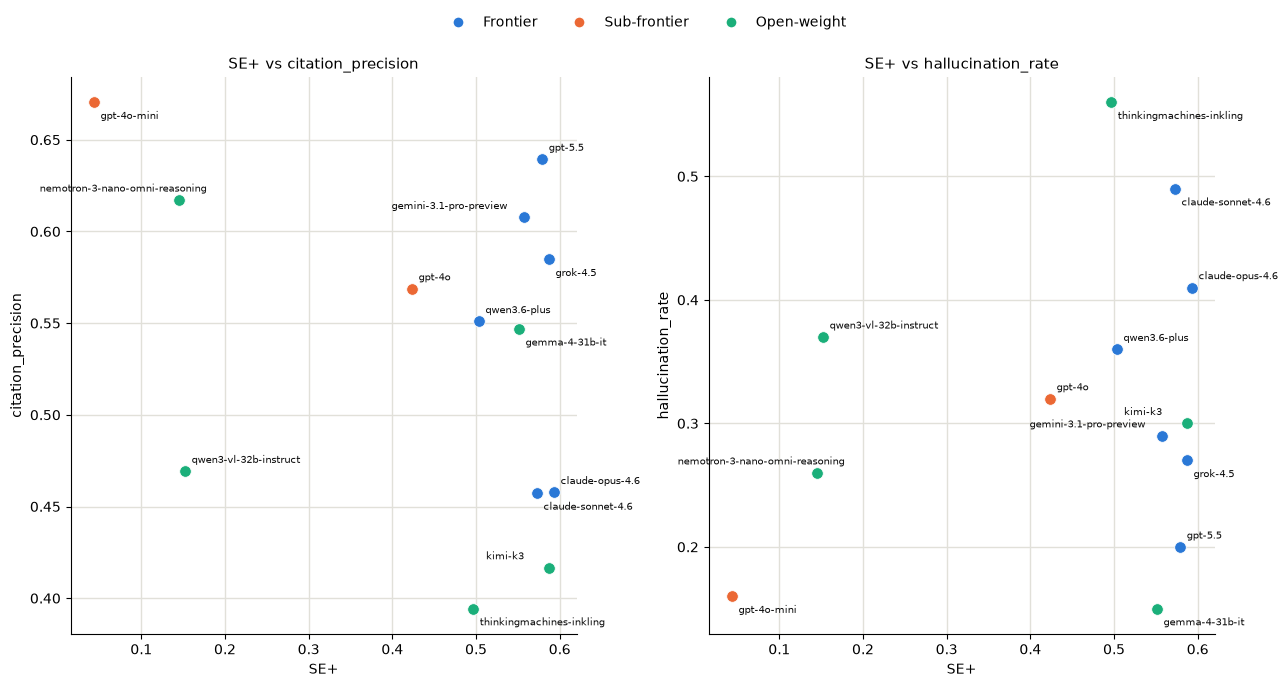

In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]
MAIN_MAPPING = "B_moderate"

TIER = {
    "gpt-4o-mini": "Sub-frontier", "gpt-4o": "Sub-frontier",
    "gemma-4-31b-it": "Open-weight", "qwen3-vl-32b-instruct": "Open-weight",
    "thinkingmachines-inkling": "Open-weight", "nemotron-3-nano-omni-reasoning": "Open-weight", "kimi-k3": "Open-weight",
    "claude-opus-4.6": "Frontier", "claude-sonnet-4.6": "Frontier", "gemini-3.1-pro-preview": "Frontier",
    "gpt-5.5": "Frontier", "grok-4.5": "Frontier", "qwen3.6-plus": "Frontier",
}
TIER_COLOR = {"Frontier": "#2a78d6", "Sub-frontier": "#eb6834", "Open-weight": "#1baf7a"}

rows = []
for a in llm_agents:
    d = data["scores_by_mapping"][MAIN_MAPPING][a]
    rows.append({"agent": a, "SE+": d["SE+"], "citation_precision": d["citation_precision"],
                 "hallucination_rate": d["hallucination_rate"], "tier": TIER[a]})
df = pd.DataFrame(rows)

LABEL_OFFSET = {
    "claude-opus-4.6": (5, 6), "grok-4.5": (5, -12), "kimi-k3": (-45, 6), "gpt-5.5": (5, 6),
    "claude-sonnet-4.6": (5, -12), "gemini-3.1-pro-preview": (-95, 6), "gemma-4-31b-it": (5, -12),
    "qwen3.6-plus": (5, 6), "thinkingmachines-inkling": (5, -12), "gpt-4o": (5, 6),
    "qwen3-vl-32b-instruct": (5, 6), "nemotron-3-nano-omni-reasoning": (-100, 6), "gpt-4o-mini": (5, -12),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, y in zip(axes, ["citation_precision", "hallucination_rate"]):
    for tier, color in TIER_COLOR.items():
        sub = df[df["tier"] == tier]
        ax.scatter(sub["SE+"], sub[y], color=color, s=70, edgecolor="white", linewidth=0.6, zorder=3)
    for _, r in df.iterrows():
        offset = LABEL_OFFSET.get(r["agent"], (6, 4))
        ax.annotate(r["agent"], (r["SE+"], r[y]), textcoords="offset points", xytext=offset, fontsize=7.5, color="#0b0b0b")
    ax.set_title(f"SE+ vs {y}", fontsize=11)
    ax.set_xlabel("SE+")
    ax.set_ylabel(y)
    ax.grid(color="#e1e0d9", linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=t) for t, c in TIER_COLOR.items()]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout()
plt.show()


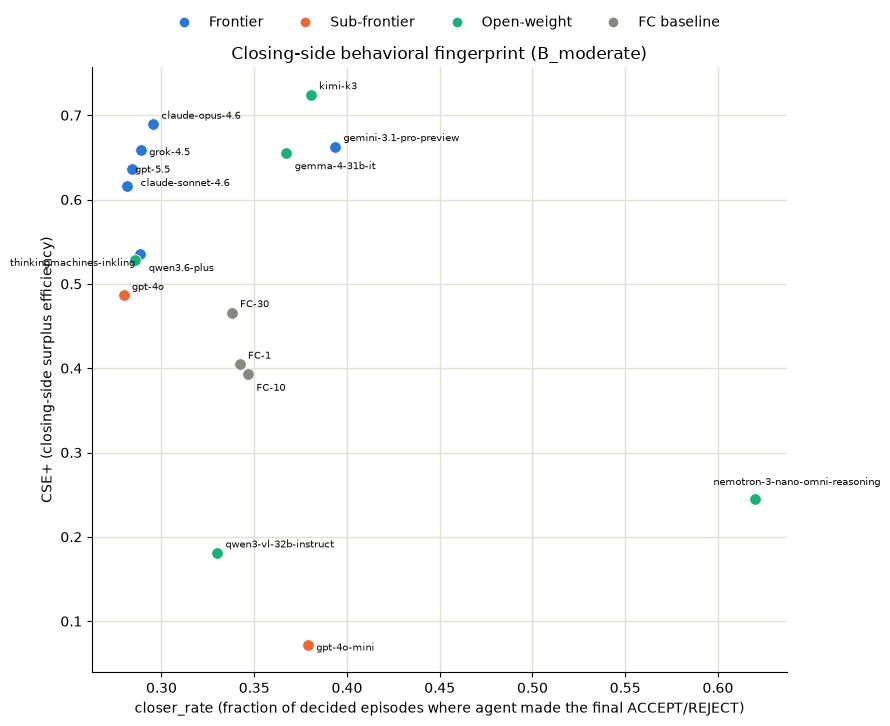

In [10]:
BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}

def closer_rate(sample):
    """종료된(round-limit timeout 제외) episode 중 agent의 ACCEPT/REJECT가 마지막 액션이었던 비율 --
    논문 Table 23/Figure 5의 closer rate(gamma)를 우리 데이터로 재구성."""
    decided = [r for r in sample if r["transcript"] and r["transcript"][-1]["decision"] in ("ACCEPT", "REJECT")]
    if not decided:
        return None
    return sum(1 for r in decided if r["transcript"][-1]["side"] == "agent") / len(decided)

by_agent = {}
for rec in episodes_by_mapping["B_moderate"]:
    by_agent.setdefault(rec["agent"], []).append(rec)

TIER = {
    "FC-1": "FC baseline", "FC-10": "FC baseline", "FC-30": "FC baseline",
    "gpt-4o-mini": "Sub-frontier", "gpt-4o": "Sub-frontier",
    "gemma-4-31b-it": "Open-weight", "qwen3-vl-32b-instruct": "Open-weight",
    "thinkingmachines-inkling": "Open-weight", "nemotron-3-nano-omni-reasoning": "Open-weight", "kimi-k3": "Open-weight",
    "claude-opus-4.6": "Frontier", "claude-sonnet-4.6": "Frontier", "gemini-3.1-pro-preview": "Frontier",
    "gpt-5.5": "Frontier", "grok-4.5": "Frontier", "qwen3.6-plus": "Frontier",
}
TIER_COLOR = {"Frontier": "#2a78d6", "Sub-frontier": "#eb6834", "Open-weight": "#1baf7a", "FC baseline": "#898781"}

rows = []
for a in AGENTS:
    rows.append({
        "agent": a, "closer_rate": closer_rate(by_agent.get(a, [])),
        "CSE+": data["scores_by_mapping"]["B_moderate"][a]["CSE+"], "tier": TIER[a],
    })
df = pd.DataFrame(rows)

LABEL_OFFSET = {
    "claude-opus-4.6": (6, 4), "grok-4.5": (6, -4), "gpt-5.5": (6, 10), "claude-sonnet-4.6": (6, -12),
    "gemini-3.1-pro-preview": (6, 4), "gemma-4-31b-it": (6, -12), "kimi-k3": (6, 4),
    "qwen3.6-plus": (6, -12), "thinkingmachines-inkling": (-90, -4), "gpt-4o": (6, 4),
    "qwen3-vl-32b-instruct": (6, 4), "nemotron-3-nano-omni-reasoning": (-30, 10), "gpt-4o-mini": (6, -4),
    "FC-1": (6, 4), "FC-10": (6, -12), "FC-30": (6, 4),
}

fig, ax = plt.subplots(figsize=(9, 7))
for tier, color in TIER_COLOR.items():
    sub = df[df["tier"] == tier]
    ax.scatter(sub["closer_rate"], sub["CSE+"], color=color, s=70, edgecolor="white", linewidth=0.6, zorder=3)
for _, r in df.iterrows():
    offset = LABEL_OFFSET.get(r["agent"], (6, 4))
    ax.annotate(r["agent"], (r["closer_rate"], r["CSE+"]), textcoords="offset points", xytext=offset, fontsize=7.5, color="#0b0b0b")

ax.set_xlabel("closer_rate (fraction of decided episodes where agent made the final ACCEPT/REJECT)")
ax.set_ylabel("CSE+ (closing-side surplus efficiency)")
ax.set_title("Closing-side behavioral fingerprint (B_moderate)", fontsize=12)
ax.grid(color="#e1e0d9", linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=t) for t, c in TIER_COLOR.items()]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()
plt.show()


In [11]:
# episode_idx=42, gemini-3.1-pro-preview, A_conservative -- SE+ 이상치(-35.26)의 원인이 된 단일 episode
outlier = next(
    r for r in episodes_by_mapping["A_conservative"]
    if r["agent"] == "gemini-3.1-pro-preview" and r["episode_idx"] == 42
)

item = outlier["item"]
cfg = outlier["episode_config"]
print(f"item: {item['category']} / {item['title']} (listing ${item['listing_price']:.2f})")
print(f"defects: {item['defects']}")
print(f"role_A: {cfg['role_A']}  r_A: ${cfg['r_A']:.2f}  t_B.r: ${cfg['t_B']['r']:.2f}")
print(f"outcome: {outlier['outcome']}")
print(f"violations: {outlier['violations']}")
print()
print("--- transcript ---")
for t in outlier["transcript"]:
    price_str = f"${t['price']:.2f}" if t["price"] is not None else "-"
    print(f"[turn {t['turn']}] {t['side']:11s} {t['decision']:6s} price={price_str:>14s} cited={t['cited_defect_ids']}")
    if t["message"]:
        print(f"    \"{t['message']}\"")


item: bike / Leader 725 (listing $550.00)
defects: [{'id': 'rust_0', 'description': 'A large patch of rust is added to the white frame of the bicycle, near the handlebars.', 'defect_type': 'rust', 'quadrant': 'obvious_aligned', 'severity': 'severe', 'price_impact': 82.5}]
role_A: BUYER  r_A: $509.76  t_B.r: $425.24
outcome: 300000.0
violations: [{'turn': 2, 'side': 'agent', 'type': 'price_out_of_bounds'}, {'turn': 2, 'side': 'agent', 'type': 'ir_violation'}]

--- transcript ---
[turn 1] counterpart OFFER  price=      $2046.26 cited=[]
    "I understand the stakes for both of us, and I’m willing to move forward with an offer of $2046.26 to find common ground. Let’s see if we can make this work for both sides."
[turn 2] agent       OFFER  price=    $300000.00 cited=['rust']
    "I'm not sure where $2046.26 came from since your listing price is only $550! Also, looking at the photo, there is a very significant amount of rust on the front half of the frame. Given the condition, I can offer

## Findings

### H1: Detection vs Grounding 실패 분리

2x2가 재는 능력은 사실 두 개뿐 --
**Detection**(결함을 알아챘는가, 가시성 축 Obvious/Subtle이 난이도 조절)과
**Grounding**(알아챘다면 크기를 진짜 가치에 맞게 반영했는가, 정합성 축
Aligned/Misaligned가 난이도 조절). <br> 두 축을 분리해서 agent별로 어느 쪽에서 무너지는지 본다.

- **Detection drop** = recall(Obvious) − recall(Subtle) / `quadrant_detection_rate` 풀링
- **Grounding bias** = signed(할인액) − price_impact
- 4개 mapping을 전부 풀링(quadrant별 표본 부족, 특히 단일 인용 turn만 모으는 grounding),
  episode 단위 bootstrap(B=2000)으로 95% CI 계산

In [12]:
import random
import pandas as pd

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]

OBVIOUS = {"obvious_aligned", "obvious_misaligned"}
SUBTLE = {"subtle_aligned", "subtle_misaligned"}
QUADRANTS4 = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]

pooled_by_agent = {
    a: [rec for m in MAPPINGS for rec in episodes_by_mapping[m] if rec["agent"] == a]
    for a in llm_agents
}

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

def recall_for_quadrants(records, quadrants):
    scored = []
    for r in records:
        D = {d["defect_type"] for d in r["item"]["defects"] if d["quadrant"] in quadrants}
        if not D:
            continue
        scored.append(len(agent_citations(r) & D) / len(D))
    return (sum(scored) / len(scored), len(scored)) if scored else (None, 0)

def detection_drop_stat(records):
    obv, _ = recall_for_quadrants(records, OBVIOUS)
    sub, _ = recall_for_quadrants(records, SUBTLE)
    return None if obv is None or sub is None else obv - sub

def bias_values_for_quadrant(rec, quadrant):
    """단일 인용 turn: signed 할인폭 - price_impact (둘 다 /R 정규화)."""
    defect_by_type = {d["defect_type"]: d for d in rec["item"]["defects"]}
    R = rec["episode_config"]["p_max"] - rec["episode_config"]["p_min"]
    sA = 1.0 if rec["episode_config"]["role_A"] == "BUYER" else -1.0
    prev_price = None
    vals = []
    for t in rec["transcript"]:
        if t["side"] != "agent" or t["decision"] != "OFFER":
            continue
        cited = t.get("cited_defect_ids") or []
        if len(cited) == 1 and prev_price is not None and cited[0] in defect_by_type:
            d = defect_by_type[cited[0]]
            if d["quadrant"] == quadrant:
                concession = sA * (t["price"] - prev_price) / R
                impact = d["price_impact"] / R
                vals.append(concession - impact)
        prev_price = t["price"]
    return vals

def bias_for_quadrant(records, quadrant):
    vals = [v for r in records for v in bias_values_for_quadrant(r, quadrant)]
    return (sum(vals) / len(vals), len(vals)) if vals else (None, 0)

def all_stats(records):
    s = {"detection_drop": detection_drop_stat(records)}
    for q in QUADRANTS4:
        s[f"bias_{q}"] = bias_for_quadrant(records, q)[0]
    s["obvious_diff"] = (None if s["bias_obvious_misaligned"] is None or s["bias_obvious_aligned"] is None
                          else s["bias_obvious_misaligned"] - s["bias_obvious_aligned"])
    s["subtle_diff"] = (None if s["bias_subtle_misaligned"] is None or s["bias_subtle_aligned"] is None
                         else s["bias_subtle_misaligned"] - s["bias_subtle_aligned"])
    return s

STAT_KEYS = ["detection_drop", "bias_obvious_aligned", "bias_subtle_aligned",
             "bias_obvious_misaligned", "bias_subtle_misaligned", "obvious_diff", "subtle_diff"]

random.seed(0)
B = 2000

results = {}
for a in llm_agents:
    sample = pooled_by_agent[a]
    n = len(sample)
    point = all_stats(sample)

    boot = {k: [] for k in STAT_KEYS}
    for _ in range(B):
        resampled = [sample[random.randrange(n)] for _ in range(n)]
        s = all_stats(resampled)
        for k in STAT_KEYS:
            if s[k] is not None:
                boot[k].append(s[k])

    ci = {}
    for k in STAT_KEYS:
        vals = sorted(boot[k])
        ci[k] = (vals[int(0.025 * len(vals))], vals[int(0.975 * len(vals))]) if vals else (None, None)

    n_by_quad = {q: bias_for_quadrant(sample, q)[1] for q in QUADRANTS4}

    results[a] = {
        "detection_drop": point["detection_drop"], "det_ci": ci["detection_drop"],
        "bias_obvious_aligned": point["bias_obvious_aligned"], "oa_ci": ci["bias_obvious_aligned"], "n_oa": n_by_quad["obvious_aligned"],
        "bias_subtle_aligned": point["bias_subtle_aligned"], "sa_ci": ci["bias_subtle_aligned"], "n_sa": n_by_quad["subtle_aligned"],
        "bias_obvious_misaligned": point["bias_obvious_misaligned"], "om_ci": ci["bias_obvious_misaligned"], "n_om": n_by_quad["obvious_misaligned"],
        "bias_subtle_misaligned": point["bias_subtle_misaligned"], "sm_ci": ci["bias_subtle_misaligned"], "n_sm": n_by_quad["subtle_misaligned"],
        "obvious_diff": point["obvious_diff"], "obvious_diff_ci": ci["obvious_diff"],  # misaligned - aligned, obvious 고정
        "subtle_diff": point["subtle_diff"], "subtle_diff_ci": ci["subtle_diff"],       # misaligned - aligned, subtle 고정
    }

rows = []
for a in llm_agents:
    r = results[a]
    rows.append({
        "agent": a,
        "bias_obvious_aligned": r["bias_obvious_aligned"], "n_oa": r["n_oa"],
        "bias_obvious_misaligned": r["bias_obvious_misaligned"], "n_om": r["n_om"],
        "obvious_diff": r["obvious_diff"], "obvious_diff_lo": r["obvious_diff_ci"][0], "obvious_diff_hi": r["obvious_diff_ci"][1],
        "bias_subtle_aligned": r["bias_subtle_aligned"], "n_sa": r["n_sa"],
        "bias_subtle_misaligned": r["bias_subtle_misaligned"], "n_sm": r["n_sm"],
        "subtle_diff": r["subtle_diff"], "subtle_diff_lo": r["subtle_diff_ci"][0], "subtle_diff_hi": r["subtle_diff_ci"][1],
    })
df_h1 = pd.DataFrame(rows).set_index("agent")
df_h1["obvious_diff_sig"] = (df_h1["obvious_diff_lo"] > 0) | (df_h1["obvious_diff_hi"] < 0)
df_h1["subtle_diff_sig"] = (df_h1["subtle_diff_lo"] > 0) | (df_h1["subtle_diff_hi"] < 0)
df_h1.round(3)


,bias_obvious_aligned,n_oa,bias_obvious_misaligned,n_om,obvious_diff,obvious_diff_lo,obvious_diff_hi,bias_subtle_aligned,n_sa,bias_subtle_misaligned,n_sm,subtle_diff,subtle_diff_lo,subtle_diff_hi,obvious_diff_sig,subtle_diff_sig
agent,,,,,,,,,,,,,,,,
claude-opus-4.6,-0.020,62,-0.015,112,0.006,-0.005,0.015,-0.000,50,NaN,0,NaN,NaN,NaN,False,False
claude-sonnet-4.6,-0.020,71,-0.016,115,0.005,-0.004,0.013,-0.000,36,-0.050,23,-0.049,-0.071,-0.020,False,True
gemini-3.1-pro-preview,-0.016,70,-0.017,107,-0.001,-0.009,0.007,-0.000,20,-0.032,41,-0.032,-0.048,-0.019,False,True
gemma-4-31b-it,-0.016,41,-0.016,38,-0.000,-0.015,0.011,-0.001,6,-0.019,14,-0.018,-0.034,-0.007,False,True
gpt-4o,-0.023,77,-0.017,138,0.006,-0.005,0.018,-0.000,15,-0.043,36,-0.042,-0.058,-0.023,False,True
gpt-4o-mini,-0.018,38,-0.024,51,-0.006,-0.022,0.009,0.001,3,-0.018,7,-0.018,-0.085,-0.004,False,True
gpt-5.5,-0.013,56,-0.008,110,0.005,-0.004,0.013,0.000,27,-0.034,15,-0.034,-0.061,-0.017,False,True
grok-4.5,-0.024,63,-0.015,132,0.009,-0.003,0.020,-0.002,23,-0.043,32,-0.041,-0.061,-0.021,False,True
kimi-k3,-0.023,60,-0.006,77,0.017,0.007,0.028,0.000,26,-0.043,13,-0.043,-0.080,-0.012,True,True


**해석**

- bias_X: quadrant별 signed(할인액) − price_impact 평균. 양수=과잉반응(더 깎음), 음수=과소반응(덜 깎음).
- n_oa/n_om/n_sa/n_sm: 각 quadrant 계산에 쓰인 단일 인용 offer turn 수 (작은 agent 많음 — 과신 금지).
- obvious_diff = bias_obvious_misaligned − bias_obvious_aligned: 가시성(obvious)을 고정하고
  정합성만 바꿨을 때 차이 — misalignment 자체의 순수 효과 (baseline 대조 통제).
- subtle_diff = bias_subtle_misaligned − bias_subtle_aligned: 마찬가지, subtle 고정.
- obvious_diff_sig/subtle_diff_sig: 그 diff의 CI가 0을 완전히 비껴가는지.

**이 표가 실제로 보여주는 패턴**

1. `bias_obvious_aligned`가 이미 13개 다 마이너스(-0.013~-0.025) — misaligned를 안 봐도
   baseline부터 전반적으로 덜 깎는 성향이 있다는 뜻.
2. `obvious_diff_sig`는 13개 중 2개만 True(kimi-k3, thinkingmachines-inkling), 그마저도
   **양수**(misaligned가 오히려 덜 나쁨) — obvious 축에서는 misalignment 고유 효과가 없음.
   앞서 본 obvious_misaligned의 마이너스는 그냥 일반적 보수성이었지 misalignment 때문이 아님.
3. `bias_subtle_aligned`는 대부분 0에 가까움(-0.004~0.001 수준) — subtle이어도 aligned면
   agent가 가치만큼 꽤 정확히 깎음.
4. `subtle_diff_sig`는 데이터 있는 11개 중 10개 True, 전부 음수 — subtle이면서 misaligned일
   때만 뚜렷하게 과소반응이 커짐. **이게 진짜 misalignment 효과.**
5. claude-opus-4.6, nemotron은 한쪽 n=0이라 subtle_diff 계산 자체가 안 됨.

<br>한 줄 요약: obvious_misaligned의 과소반응은 misalignment 효과가 아니라 baseline 보수성
(obvious_aligned에서도 동일하게 나타남). misalignment 고유 효과는 subtle_misaligned에서만
유의(10/11) — 이 quadrant에서만 aligned 대비 뚜렷하게 더 깎아주지 않는다. n이 작은 agent
(gpt-4o-mini n_sa=3 등)는 과신 금지.


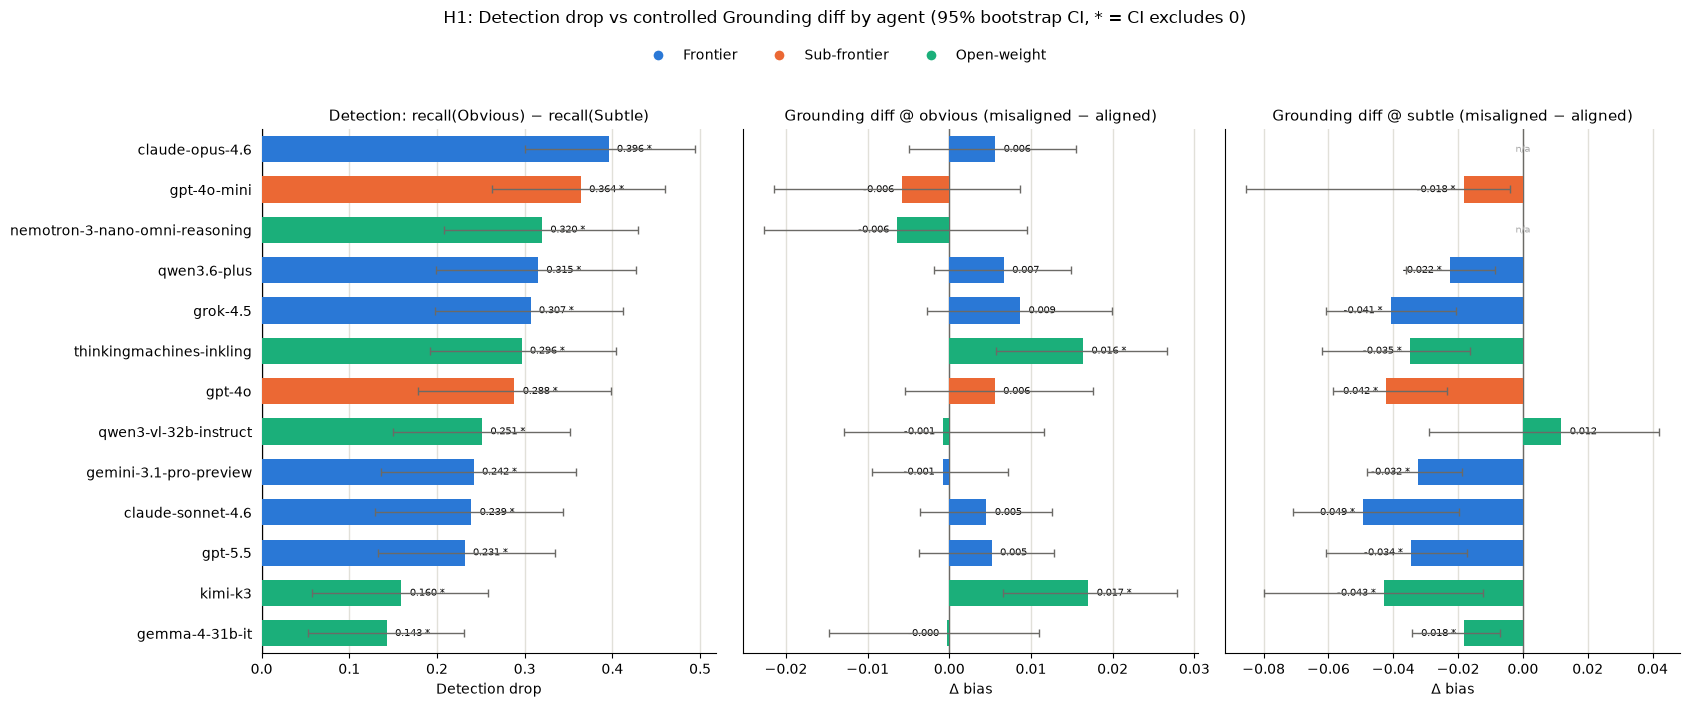

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

TIER = {
    "gpt-4o-mini": "Sub-frontier", "gpt-4o": "Sub-frontier",
    "gemma-4-31b-it": "Open-weight", "qwen3-vl-32b-instruct": "Open-weight",
    "thinkingmachines-inkling": "Open-weight", "nemotron-3-nano-omni-reasoning": "Open-weight", "kimi-k3": "Open-weight",
    "claude-opus-4.6": "Frontier", "claude-sonnet-4.6": "Frontier", "gemini-3.1-pro-preview": "Frontier",
    "gpt-5.5": "Frontier", "grok-4.5": "Frontier", "qwen3.6-plus": "Frontier",
}
TIER_COLOR = {"Frontier": "#2a78d6", "Sub-frontier": "#eb6834", "Open-weight": "#1baf7a"}
GRID_COLOR = "#e1e0d9"

def bar_panel(ax, metric_key, ci_key, title, xlabel, order, show_labels):
    ax.axvline(0, color="#6b6a66", linewidth=1, zorder=1)
    for i, a in enumerate(order):
        v = results[a][metric_key]
        color = TIER_COLOR[TIER[a]]
        if v is None:
            ax.text(0, i, "n/a", va="center", ha="center", fontsize=7.5, color="#aaa")
            continue
        lo, hi = results[a][ci_key]
        xerr = [[v - lo], [hi - v]]
        ax.barh(i, v, color=color, height=0.65, zorder=3,
                xerr=xerr, error_kw=dict(ecolor="#6b6a66", elinewidth=1, capsize=3, zorder=4))
        sig = (lo > 0) or (hi < 0)
        offset = 6 if v >= 0 else -6
        ha = "left" if v >= 0 else "right"
        ax.annotate(f"{v:.3f}{' *' if sig else ''}", (v, i),
                    textcoords="offset points", xytext=(offset, 0), ha=ha, va="center",
                    fontsize=7.5, color="#0b0b0b")

    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.tick_params(axis="y", labelleft=show_labels, left=False)
    ax.set_ylim(len(order) - 0.5, -0.5)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

order = sorted(llm_agents, key=lambda a: results[a]["detection_drop"], reverse=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 6.5))
bar_panel(ax1, "detection_drop", "det_ci", "Detection: recall(Obvious) − recall(Subtle)", "Detection drop", order, True)
bar_panel(ax2, "obvious_diff", "obvious_diff_ci", "Grounding diff @ obvious (misaligned − aligned)", "Δ bias", order, False)
bar_panel(ax3, "subtle_diff", "subtle_diff_ci", "Grounding diff @ subtle (misaligned − aligned)", "Δ bias", order, False)

fig.legend(handles=[Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=t)
                     for t, c in TIER_COLOR.items()],
           loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("H1: Detection drop vs controlled Grounding diff by agent (95% bootstrap CI, * = CI excludes 0)", y=1.08, fontsize=12)
plt.tight_layout()
plt.show()


**해석**

왼쪽 패널(Detection): 막대가 전부 0보다 오른쪽에 있고, 에러바도 전부 0선에 안 닿음 — 13개 다 *.
색(tier)이 순위와 안 섞여서 위아래 골고루 흩어져 있음 → "프론티어라서 잘한다" 패턴 없음.

가운데 패널(obvious diff = misaligned − aligned): 13개 중 2개만 *(kimi-k3, thinkingmachines-inkling),
그마저도 양수 — obvious 조건에서는 misalignment 고유 효과가 없음. 대부분 막대가 0 근처에 짧게
몰려있음.

오른쪽 패널(subtle diff): 데이터 있는 11개 중 10개가 음수+* — subtle이면서 misaligned일 때만
뚜렷하게 진짜 가치보다 덜 깎아줌. claude-opus-4.6/nemotron은 n/a(subtle 쪽 단일 인용 turn 자체가
없어서 diff 계산 불가).

**크기 감**: subtle_misaligned quadrant의 price_impact/R 평균이 0.0486인데 반해 diff는
−0.02~−0.05 수준 — 받아야 할 할인의 절반 가까이(많게는 전부)를 못 받는다는 뜻으로, 절대
숫자는 작아 보여도 상대적으로는 큰 효과.

세 패널을 나란히 보면: Detection과 subtle diff는 "확신에 찬" 모양(막대+에러바가 한 방향으로
0에서 떨어짐), obvious diff만 "0 근처에 몰린" 모양 — misalignment로 인한 grounding 실패는
subtle 조건에서만 특정적으로 나타난다는 게 형태로도 드러남.

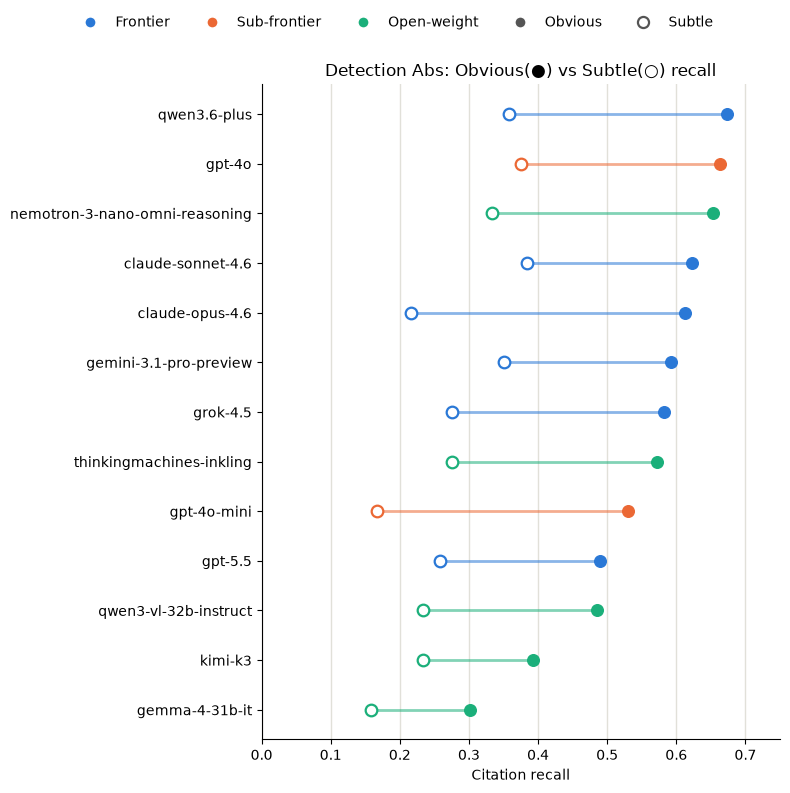

In [14]:
import matplotlib.pyplot as plt

def recall_for_quadrants(records, quadrants):
    scored = []
    for r in records:
        D = {d["defect_type"] for d in r["item"]["defects"] if d["quadrant"] in quadrants}
        if not D:
            continue
        scored.append(len(agent_citations(r) & D) / len(D))
    return (sum(scored) / len(scored), len(scored)) if scored else (None, 0)

recall_abs = {
    a: (recall_for_quadrants(pooled_by_agent[a], OBVIOUS)[0],
        recall_for_quadrants(pooled_by_agent[a], SUBTLE)[0])
    for a in llm_agents
}

order = sorted(llm_agents, key=lambda a: recall_abs[a][0])  # recall_obv 오름차순 -- barh는 아래부터 그려지므로 위가 1등

fig, ax = plt.subplots(figsize=(8, 7.5))
for a in order:
    obv, sub = recall_abs[a]
    color = TIER_COLOR[TIER[a]]
    ax.plot([sub, obv], [a, a], color=color, linewidth=2, zorder=2, alpha=0.55)
    ax.scatter([obv], [a], color=color, s=70, zorder=3, label="_nolegend_")             # Obvious = 채운 원
    ax.scatter([sub], [a], facecolor="white", edgecolor=color, linewidth=1.6, s=70, zorder=3)  # Subtle = 빈 원

ax.set_xlabel("Citation recall")
ax.set_title("Detection Abs: Obvious(●) vs Subtle(○) recall")
ax.set_xlim(0, 0.75)
ax.grid(axis="x", color=GRID_COLOR, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

from matplotlib.lines import Line2D
tier_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=t)
                for t, c in TIER_COLOR.items()]
shape_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor="#555", markersize=8, label="Obvious"),
                 Line2D([0], [0], marker="o", color="w", markerfacecolor="white", markeredgecolor="#555",
                        markeredgewidth=1.6, markersize=8, label="Subtle")]
fig.legend(handles=tier_handles + shape_handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout()
plt.show()


**해석**
1. Obvious들이 전부 0.7 아래에 몰려있음 즉, 제일 쉬운 조건의 천장 자체가 낮다"가 한눈에 보임.
2. 선 길이(=drop)가 agent마다 다른 이유가 둘로 갈림: 아래쪽(gemma, kimi)은 둘 다 못함이라 짧은 것. 반면 claude-opus-4.6은 Obvious는 되는데 Subtle만 특이하게 무너짐. 같은 짧은/긴 선이어도 원인이 다르다는 게 점 위치로 구분됨.
3. 색(tier)이 세로축에서 안 뭉쳐 있음 — Frontier(파랑)/Sub-frontier(주황)/Open-weight(초록)가 위아래 골고루 섞여 있어서, 프론티어라서 detection을 잘한다는 단순한 이야기가 이 축에서는 안 통한다는 걸 시각적으로 보여줌.

<br>한 줄로: Subtle이 어렵다는 사실 하나가 아니라, 같은 결론도 agent마다 서로 다른 기전(바닥효과 vs 진짜 실패)에서 나온다는 걸 절댓값 두 점으로 구분해서 보여주는 그래프

H1이 검증하려던 것: 이 벤치마크의 2x2 설계(Obvious/Subtle × Aligned/Misaligned)가 실제로 두 개의 독립된 능력 — Detection(봤는가)과 Grounding(본 걸 제대로 값으로 반영했는가) — 을 분리해서 잴 수 있는지, 그리고 agent들이 이 둘 중 어디서 실패하는지.

최종적으로 확립된 것:

Detection과 Grounding은 진짜 분리된 실패 축이다. 둘이 같은 원인으로 같이 움직이는 게 아니라 — Detection은 13/13 전원에서 보편적으로 실패(Subtle이면 다 놓침), Grounding은 딱 한 조건(subtle_misaligned)에서만 misalignment 고유 효과가 나타남. 이걸 aligned baseline과 대조해서 "진짜 misalignment 때문"이라고 통계적으로 뗐다는 게 핵심.

"킬러 사분면"(subtle_misaligned) 설계가 실제로 작동한다는 걸 확인했다. 단순히 두 난이도가 더해진 게 아니라, grounding 실패라는 새로운 실패 유형이 그 교집합에서만 나타난다는 걸 데이터로 보임 — additive가 아니라 interaction이라는 증거.


이걸로 뭘 할 수 있나:

논문 Finding 하나로 그대로 쓸 수 있음: "agent들은 misalignment에 속아 과잉반응하지 않지만, 가장 어려운 조건(안 보이는데 진짜 심각)에서는 놓치는 게 아니라 찾아놓고도 가치를 절반도 반영 못 한다" — 실무적으로도 중요한 얘기(진짜 위험한 결함을 알면서도 값을 안 깎아주면, 상대가 눈치 못 채는 채로 손해를 보는 거니까).
H2~H5로 넘어갈 근거: grounding 효과가 노이즈가 아니라 진짜라는 걸 확인했으니, 이제 "누가 이 효과에서 특히 심한가/예외인가"(H6)를 봐도 그 위에 있는 게 허상이 아니라는 확신이 생김.
재사용 가능한 방법: "baseline quadrant와 대조해서 순수 효과만 뽑아내는" 이 설계(obvious_diff/subtle_diff 패턴)를 H2~H5에서 비슷한 대조가 필요할 때 그대로 갖다 쓸 수 있음.
claude-opus-4.6/nemotron 케이스: detection이 너무 나빠서 grounding 자체를 잴 데이터가 없다는 게, "detection 실패가 grounding 평가 기회 자체를 없앤다"는 더 심한 실패 등급이 있다는 걸 보여줌 — H6에서 개별 파볼 소재.

### H2: Subtle-Misaligned 킬러조건 super-additivity 검증

가장 어려운 사분면(subtle_misaligned)의 성능 하락이 두 난이도 축(가시성+정합성)을 단순히
더한 것보다 더 큰지 확인한다. H1이 결함 인용 단위(detection recall, grounding bias)에서 본 걸,
여기서는 협상 결과(SE+/CSE+) 단위에서 본다.

- **가산적 예측(additive prediction)** = (obvious_aligned − subtle_aligned 하락) +
  (obvious_aligned − obvious_misaligned 하락) -- 두 축이 서로 독립이면 기대되는 하락폭
- **실제 하락** = obvious_aligned − subtle_misaligned
- **super-additivity gap** = 실제 하락 − 가산적 예측 -- 양수면 두 난이도가 단순 합이 아니라
  곱으로 상호작용한다는 뜻 (H1에서 grounding 실패가 subtle_misaligned에만 국한됐던 것과
  같은 방향의 예상)
- quadrant별 SE+/CSE+는 이미 계산돼 있음(`quadrant_scores_by_mapping`, 4 mapping 풀링),
  episode 단위 bootstrap(B=2000)으로 CI 계산

In [15]:
import random
import pandas as pd

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]
QUADRANTS4 = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]

pooled_by_agent = {
    a: [rec for m in MAPPINGS for rec in episodes_by_mapping[m] if rec["agent"] == a]
    for a in llm_agents
}

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

def episode_quadrant(rec):
    defects = rec["item"]["defects"]
    return defects[0]["quadrant"] if defects else None

def episode_cited(rec):
    """agent가 이 episode의 결함을 실제로 한 번이라도 인용했는지 -- 인용 안 하면
    QUADRANT_BONUS가 전혀 발동 안 해서 economic하게 결함 없는 episode와 동일하므로 제외."""
    defects = rec["item"]["defects"]
    if not defects:
        return False
    return defects[0]["defect_type"] in agent_citations(rec)

def episode_se(rec):
    cfg = rec["episode_config"]
    role_A, r_A, r_B = cfg["role_A"], cfg["r_A"], cfg["t_B"]["r"]
    r_buyer = r_A if role_A == "BUYER" else r_B
    r_seller = r_B if role_A == "BUYER" else r_A
    delta = r_buyer - r_seller
    outcome = rec["outcome"]
    u = 0.0 if outcome is None else ((r_A - outcome) if role_A == "BUYER" else (outcome - r_A))
    return u / delta if delta else None

def stat_se_plus(s):
    vals = [v for r in s if (v := episode_se(r)) is not None]
    return sum(vals) / len(vals) if vals else None

def buckets_by_quadrant(records):
    b = {q: [] for q in QUADRANTS4}
    for r in records:
        if r["violations"]:
            continue
        if not episode_cited(r):  # NEW -- 실제로 인용한 episode만
            continue
        q = episode_quadrant(r)
        if q in b:
            b[q].append(r)
    return b

def gap_stat(se):
    if any(se[q] is None for q in QUADRANTS4):
        return None
    additive = (se["obvious_aligned"] - se["subtle_aligned"]) + (se["obvious_aligned"] - se["obvious_misaligned"])
    actual = se["obvious_aligned"] - se["subtle_misaligned"]
    return actual - additive

random.seed(0)
B = 2000

results_h2 = {}
for a in llm_agents:
    buckets = buckets_by_quadrant(pooled_by_agent[a])
    n_by_q = {q: len(buckets[q]) for q in QUADRANTS4}
    se_point = {q: stat_se_plus(buckets[q]) for q in QUADRANTS4}
    gap_point = gap_stat(se_point)

    boot_gap = []
    for _ in range(B):
        se_boot = {}
        for q in QUADRANTS4:
            sample = buckets[q]
            n = len(sample)
            se_boot[q] = stat_se_plus([sample[random.randrange(n)] for _ in range(n)]) if n else None
        g = gap_stat(se_boot)
        if g is not None:
            boot_gap.append(g)
    boot_gap.sort()
    gap_ci = (boot_gap[int(0.025 * len(boot_gap))], boot_gap[int(0.975 * len(boot_gap))]) if boot_gap else (None, None)

    results_h2[a] = {
        "se_obvious_aligned": se_point["obvious_aligned"], "n_oa": n_by_q["obvious_aligned"],
        "se_subtle_aligned": se_point["subtle_aligned"], "n_sa": n_by_q["subtle_aligned"],
        "se_obvious_misaligned": se_point["obvious_misaligned"], "n_om": n_by_q["obvious_misaligned"],
        "se_subtle_misaligned": se_point["subtle_misaligned"], "n_sm": n_by_q["subtle_misaligned"],
        "super_additivity_gap": gap_point, "gap_lo": gap_ci[0], "gap_hi": gap_ci[1],
    }

df_h2 = pd.DataFrame(results_h2).T
df_h2["gap_sig"] = (df_h2["gap_lo"] > 0) | (df_h2["gap_hi"] < 0)
df_h2.round(3)


,se_obvious_aligned,n_oa,se_subtle_aligned,n_sa,se_obvious_misaligned,n_om,se_subtle_misaligned,n_sm,super_additivity_gap,gap_lo,gap_hi,gap_sig
claude-opus-4.6,0.580,48.0,0.681,21.0,0.558,72.0,0.699,5.0,-0.040,-0.321,0.249,False
claude-sonnet-4.6,0.609,51.0,0.684,27.0,0.503,67.0,0.697,19.0,-0.119,-0.319,0.094,False
gemini-3.1-pro-preview,0.648,54.0,0.701,13.0,0.553,61.0,0.647,28.0,-0.040,-0.228,0.149,False
gemma-4-31b-it,0.616,29.0,0.243,6.0,0.472,30.0,0.655,13.0,-0.556,-0.893,-0.193,True
gpt-4o,0.514,50.0,0.376,15.0,0.487,62.0,0.595,25.0,-0.247,-0.514,0.023,False
gpt-4o-mini,0.105,34.0,0.216,7.0,0.158,50.0,0.003,6.0,0.267,0.063,0.527,True
gpt-5.5,0.516,38.0,0.645,15.0,0.493,54.0,0.722,16.0,-0.099,-0.338,0.141,False
grok-4.5,0.570,47.0,0.716,12.0,0.587,67.0,0.678,21.0,0.055,-0.138,0.246,False
kimi-k3,0.528,38.0,0.595,16.0,0.397,37.0,0.773,12.0,-0.309,-0.570,-0.074,True
nemotron-3-nano-omni-reasoning,0.151,47.0,0.040,11.0,0.230,67.0,0.328,24.0,-0.210,-0.406,-0.021,True


**해석**

첫 시도(violation 제외만, quadrant 전체 episode 포함): `gap_sig`가 13개 중 gpt-5.5 하나뿐이고
CI 하한이 0.004로 거의 0에 붙어있음 — 13번 검정 중 우연히 하나 걸리는 수준이라 신뢰 안 됨.
부호도 양수 6개/음수 7개로 방향성 없음 → **population 수준에서 super-additivity 근거 없음.**

이 결과가 H1(citation 발생 시에만 나타나는 grounding 효과)과 모순되진 않음 — quadrant 안에
detection을 아예 못 한(그래서 QUADRANT_BONUS가 전혀 안 걸린) episode가 섞여서 H1이 잡은
좁은 효과가 평균에서 희석된 것으로 해석.

**citation 조건부로 좁힌 재시도**: `n_sm`이 5~28로 급감(claude-opus-4.6=5, gpt-4o-mini=6,
qwen3-vl-32b=7 등 한 자릿수 다수). `gap_sig=True`가 4개로 늘었지만(gemma, gpt-4o-mini,
kimi-k3, nemotron), 그중 3개(gemma/kimi-k3/nemotron)는 **음수**(예측보다 덜 나쁨,
sub-additive) — H2가 가정한 방향과 반대. 유일하게 원래 방향(super-additive, +0.267)인
gpt-4o-mini는 n_sm=6짜리 결과라 신뢰하기 어려움.

**결론**: H2는 표본 부족으로 **판단 불가(inconclusive)**로 마무리. "효과가 없다"가 아니라
"지금 데이터로는 citation-조건부 검정을 감당할 만큼 subtle_misaligned citation이 안 쌓인다"는
뜻 — episode 수를 늘릴 예산이 생기면 재시도할 항목.


In [16]:
import random
import pandas as pd

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]
QUADRANTS4 = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]

pooled_by_agent = {
    a: [rec for m in MAPPINGS for rec in episodes_by_mapping[m] if rec["agent"] == a]
    for a in llm_agents
}

def episode_quadrant(rec):
    defects = rec["item"]["defects"]
    return defects[0]["quadrant"] if defects else None

def episode_se(rec):
    cfg = rec["episode_config"]
    role_A, r_A, r_B = cfg["role_A"], cfg["r_A"], cfg["t_B"]["r"]
    r_buyer = r_A if role_A == "BUYER" else r_B
    r_seller = r_B if role_A == "BUYER" else r_A
    delta = r_buyer - r_seller
    outcome = rec["outcome"]
    u = 0.0 if outcome is None else ((r_A - outcome) if role_A == "BUYER" else (outcome - r_A))
    return u / delta if delta else None

def stat_se_plus(s):
    vals = [v for r in s if (v := episode_se(r)) is not None]
    return sum(vals) / len(vals) if vals else None

def buckets_by_quadrant_role(records, role):
    """H9에서 확인된 role/quadrant 불균형 때문에, H2를 role 고정한 채로 재검증.
    violation 있는 episode 제외(H2 원래 이유와 동일)."""
    b = {q: [] for q in QUADRANTS4}
    for r in records:
        if r["violations"]:
            continue
        if r["episode_config"]["role_A"] != role:
            continue
        q = episode_quadrant(r)
        if q in b:
            b[q].append(r)
    return b

def gap_stat(se):
    if any(se[q] is None for q in QUADRANTS4):
        return None
    additive = (se["obvious_aligned"] - se["subtle_aligned"]) + (se["obvious_aligned"] - se["obvious_misaligned"])
    actual = se["obvious_aligned"] - se["subtle_misaligned"]
    return actual - additive

random.seed(0)
B = 2000

results_h2_retrial = {}
for a in llm_agents:
    sample = pooled_by_agent[a]
    for role in ["BUYER", "SELLER"]:
        buckets = buckets_by_quadrant_role(sample, role)
        n_by_q = {q: len(buckets[q]) for q in QUADRANTS4}
        se_point = {q: stat_se_plus(buckets[q]) for q in QUADRANTS4}
        gap_point = gap_stat(se_point)

        boot_gap = []
        for _ in range(B):
            se_boot = {}
            for q in QUADRANTS4:
                bsample = buckets[q]
                n = len(bsample)
                se_boot[q] = stat_se_plus([bsample[random.randrange(n)] for _ in range(n)]) if n else None
            g = gap_stat(se_boot)
            if g is not None:
                boot_gap.append(g)
        boot_gap.sort()
        gap_ci = (boot_gap[int(0.025 * len(boot_gap))], boot_gap[int(0.975 * len(boot_gap))]) if boot_gap else (None, None)

        results_h2_retrial[(a, role)] = {
            "n_oa": n_by_q["obvious_aligned"], "n_sa": n_by_q["subtle_aligned"],
            "n_om": n_by_q["obvious_misaligned"], "n_sm": n_by_q["subtle_misaligned"],
            "super_additivity_gap": gap_point, "gap_lo": gap_ci[0], "gap_hi": gap_ci[1],
        }

df_h2_retrial = pd.DataFrame(results_h2_retrial).T
df_h2_retrial.index.names = ["agent", "role"]
df_h2_retrial["gap_sig"] = (df_h2_retrial["gap_lo"] > 0) | (df_h2_retrial["gap_hi"] < 0)
df_h2_retrial.round(3)


n_oa  n_sa  n_om  n_sm  \
agent                          role                             
claude-opus-4.6                BUYER   48.0  20.0  60.0  23.0   
                               SELLER  32.0  32.0  56.0  41.0   
claude-sonnet-4.6              BUYER   48.0  20.0  57.0  24.0   
                               SELLER  32.0  32.0  55.0  41.0   
gemini-3.1-pro-preview         BUYER   47.0  20.0  60.0  24.0   
                               SELLER  32.0  31.0  56.0  43.0   
gemma-4-31b-it                 BUYER   48.0  20.0  60.0  24.0   
                               SELLER  32.0  32.0  56.0  44.0   
gpt-4o                         BUYER   46.0  17.0  44.0  20.0   
                               SELLER  30.0  30.0  52.0  39.0   
gpt-4o-mini                    BUYER   44.0  17.0  50.0  17.0   
                               SELLER  24.0  19.0  40.0  20.0   
gpt-5.5                        BUYER   46.0  17.0  57.0  23.0   
                               SELLER  32.0  32.0  55.0  40.0   
grok-4.5                       BUYER   46.0  18.0  60.0  24.0   
                               SELLER  32.0  32.0  56.0  41.0   
kimi-k3                        BUYER   48.0  20.0  58.0  24.0   
                               SELLER  32.0  32.0  55.0  42.0   
nemotron-3-nano-omni-reasoning BUYER   43.0  19.0  49.0  13.0   
                               SELLER  29.0  27.0  45.0  33.0   
qwen3-vl-32b-instruct          BUYER   36.0  15.0  32.0   9.0   
                               SELLER  27.0  20.0  36.0  34.0   
qwen3.6-plus                   BUYER   48.0  20.0  59.0  24.0   
                               SELLER  31.0  32.0  56.0  41.0   
thinkingmachines-inkling       BUYER   47.0  20.0  57.0  23.0   
                               SELLER  32.0  32.0  54.0  39.0   

                                       super_additivity_gap  gap_lo  gap_hi  \
agent                          role                                           
claude-opus-4.6                BUYER                  0.180  -0.033   0.389   
                               SELLER                 0.018  -0.184   0.235   
claude-sonnet-4.6              BUYER                 -0.028  -0.184   0.123   
                               SELLER                 0.101  -0.128   0.318   
gemini-3.1-pro-preview         BUYER                 -0.222  -0.444   0.018   
                               SELLER                 0.079  -0.101   0.263   
gemma-4-31b-it                 BUYER                 -0.398  -0.596  -0.177   
                               SELLER                 0.007  -0.185   0.200   
gpt-4o                         BUYER                 -0.235  -0.439  -0.026   
                               SELLER                -0.039  -0.277   0.213   
gpt-4o-mini                    BUYER                  0.021  -0.139   0.184   
                               SELLER                -0.212  -0.488   0.066   
gpt-5.5                        BUYER                  0.022  -0.174   0.215   
                               SELLER                 0.174  -0.034   0.391   
grok-4.5                       BUYER                 -0.088  -0.282   0.107   
                               SELLER                 0.105  -0.100   0.303   
kimi-k3                        BUYER                 -0.135  -0.349   0.087   
                               SELLER                 0.068  -0.131   0.264   
nemotron-3-nano-omni-reasoning BUYER                  0.015  -0.068   0.101   
                               SELLER                 0.062  -0.184   0.314   
qwen3-vl-32b-instruct          BUYER                  0.095  -0.059   0.248   
                               SELLER                -0.124  -0.381   0.136   
qwen3.6-plus                   BUYER                 -0.177  -0.367   0.010   
                               SELLER                -0.028  -0.236   0.180   
thinkingmachines-inkling       BUYER                 -0.145  -0.323   0.032   
                               SELLER                -0.045  -0.266   0.166   

     

### H3: severity_calibration_rho의 mapping 안정성

4개 mapping(A_conservative/B_moderate/C_aggressive/D_nonlinear)은 defect_type별 price_impact
%만 다르고 상대적 순위(scratch/stain < dent/crack/rust/tear < missing_part)는 동일하게
유지된다(H1 조사 중 확인). agent가 "진짜 가치를 읽어서" 가격을 조정한다면 이 순위 기반
상관관계(calib_ρ)는 mapping이 바뀌어도 비슷하게 유지돼야 하고, 특정 mapping의 숫자
패턴을 외운 거라면 그 mapping에서만 유독 잘 맞고 나머지에서 무너질 것이다.

- **calib_ρ per mapping** = 단일 인용 OFFER turn에서 (price_impact, |Δprice|/R) 상관관계,
  4개 mapping 각각 따로 계산 (H1과 반대로 여기서는 풀링하지 않음 — mapping별 안정성 자체가
  질문이므로)
- agent별로 4개 rho를 나란히 놓고 episode 단위 bootstrap(B=2000)으로 CI 계산
- **주의할 confound**: mapping마다 price_impact 절대 크기가 다르다(A는 5~20%, C는 15~50%
  등) — 가격 노이즈(σ̄p)는 mapping과 무관하게 고정된 스케일이라, price_impact가 작은
  mapping(A)에서는 신호 대 잡음비가 원래 낮아서 "진짜 잘 읽는" agent도 rho가 약하게 나올
  수 있음. mapping간 차이를 곧바로 "overfitting"으로 해석하기 전에 이 효과부터 배제해야 함


In [17]:
import random
from metrics import spearman_rho
import pandas as pd

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]

def calibration_pairs(rec):
    """단일 인용 OFFER turn: (price_impact, |Δprice|/R) -- quadrant 무관, H1 cell 8과 동일 로직."""
    defect_by_type = {d["defect_type"]: d for d in rec["item"]["defects"]}
    R = rec["episode_config"]["p_max"] - rec["episode_config"]["p_min"]
    prev_price = None
    pairs = []
    for t in rec["transcript"]:
        if t["side"] != "agent" or t["decision"] != "OFFER":
            continue
        cited = t.get("cited_defect_ids") or []
        if len(cited) == 1 and prev_price is not None and cited[0] in defect_by_type:
            d = defect_by_type[cited[0]]
            pairs.append((d["price_impact"], abs(t["price"] - prev_price) / R))
        prev_price = t["price"]
    return pairs

def calibration_rho(records):
    xs, ys = [], []
    for r in records:
        for x, y in calibration_pairs(r):
            xs.append(x); ys.append(y)
    return (spearman_rho(xs, ys), len(xs)) if xs else (None, 0)

by_agent_mapping = {
    (a, m): [rec for rec in episodes_by_mapping[m] if rec["agent"] == a]
    for a in llm_agents for m in MAPPINGS
}

random.seed(0)
B = 2000

results_h3 = {}
for a in llm_agents:
    row = {}
    for m in MAPPINGS:
        sample = by_agent_mapping[(a, m)]
        n = len(sample)
        point, n_pairs = calibration_rho(sample)

        boot = sorted(
            v for _ in range(B)
            if (v := calibration_rho([sample[random.randrange(n)] for _ in range(n)])[0]) is not None
        ) if n else []
        lo, hi = (boot[int(0.025 * len(boot))], boot[int(0.975 * len(boot))]) if boot else (None, None)

        row[f"{m}_rho"] = point
        row[f"{m}_lo"] = lo
        row[f"{m}_hi"] = hi
        row[f"{m}_n"] = n_pairs
    results_h3[a] = row

df_h3 = pd.DataFrame(results_h3).T
df_h3.round(3)


,A_conservative_rho,A_conservative_lo,A_conservative_hi,A_conservative_n,B_moderate_rho,B_moderate_lo,B_moderate_hi,B_moderate_n,C_aggressive_rho,C_aggressive_lo,C_aggressive_hi,C_aggressive_n,D_nonlinear_rho,D_nonlinear_lo,D_nonlinear_hi,D_nonlinear_n
claude-opus-4.6,0.737,0.405,0.884,51.0,0.803,0.496,0.932,58.0,0.846,0.624,0.937,58.0,0.768,0.458,0.922,57.0
claude-sonnet-4.6,0.638,0.279,0.813,50.0,0.692,0.442,0.831,61.0,0.762,0.599,0.836,69.0,0.570,0.348,0.697,65.0
gemini-3.1-pro-preview,0.704,0.439,0.810,56.0,0.728,0.489,0.836,58.0,0.742,0.476,0.845,59.0,0.683,0.415,0.791,65.0
gemma-4-31b-it,0.677,0.136,0.882,25.0,0.659,0.133,0.822,26.0,0.782,0.335,0.934,26.0,0.605,-0.035,0.893,22.0
gpt-4o,0.570,0.184,0.766,60.0,0.591,0.369,0.727,61.0,0.744,0.546,0.829,77.0,0.672,0.453,0.811,68.0
gpt-4o-mini,0.236,-0.286,0.714,26.0,0.377,-0.175,0.767,25.0,-0.339,-0.852,0.507,20.0,0.012,-0.498,0.594,28.0
gpt-5.5,0.565,0.216,0.757,44.0,0.701,0.460,0.827,50.0,0.670,0.457,0.760,58.0,0.637,0.348,0.781,56.0
grok-4.5,0.677,0.278,0.801,50.0,0.659,0.356,0.783,57.0,0.787,0.603,0.860,75.0,0.644,0.405,0.759,68.0
kimi-k3,0.745,0.484,0.863,41.0,0.656,0.016,0.913,35.0,0.697,0.366,0.821,49.0,0.625,0.262,0.798,51.0
nemotron-3-nano-omni-reasoning,0.432,-0.778,1.000,7.0,0.749,0.198,1.000,13.0,0.517,-0.012,1.000,10.0,0.687,0.014,1.000,11.0


**해석**

**표 읽는 법**

- `{mapping}_rho`: 그 mapping에서 계산한 severity-calibration Spearman 상관계수(price_impact
  vs |가격변화|/R, quadrant 구분 없이 단일 인용 OFFER turn 전체). 1에 가까울수록 "결함 가치가
  클수록 가격도 더 크게 움직인다"는 관계가 강함.
- `{mapping}_lo` / `{mapping}_hi`: 그 rho의 95% 부트스트랩 신뢰구간 하한/상한.
- `{mapping}_n`: 그 mapping에서 계산에 쓰인 (price_impact, 가격변화) pair 수 — 단일 인용
  OFFER turn 개수와 같음. 작을수록(특히 한 자릿수) CI를 신뢰하기 어려움.

예: `C_aggressive_rho=0.846`, `C_aggressive_lo=0.624`, `C_aggressive_hi=0.937`,
`C_aggressive_n=58` → claude-opus-4.6이 C_aggressive mapping에서 58개 인용 턴으로 계산한
상관계수가 0.846이고, 그 값의 95% 신뢰구간이 [0.624, 0.937]이라는 뜻.



**표에서**: 9개 agent(claude-opus-4.6, claude-sonnet-4.6, gemini-3.1-pro-preview, gpt-4o,
gpt-5.5, grok-4.5, kimi-k3, qwen3.6-plus, thinkingmachines-inkling)는 4개 mapping 전부에서
유의미하고 rho가 0.55~0.93 사이로 안정적. gemma-4-31b-it은 3/4 유의(D_nonlinear만 CI 하한
-0.035로 살짝 걸침).

**두 예외**:
- gpt-4o-mini: 4개 mapping **전부** CI가 0을 가로지름(A=0.236, B=0.377, C=-0.339, D=0.012) —
  mapping별로 흔들리는 게 아니라 애초에 어느 mapping에서도 진짜 calibration이 없음.
- qwen3-vl-32b-instruct: C_aggressive 하나만 유의(0.596), 나머지 3개는 점추정치도 낮고(0.08~0.45)
  CI도 0을 가로지름 — 약한 calibration.

**nemotron**은 n=7~13로 표본이 너무 작아 CI 상한이 전부 1.000에 붙음(소표본 특유 현상) —
유의/비유의 판단 자체가 불가능.

**mapping간 크기 차이(A가 대체로 낮고 C가 대체로 높은 경향)**는 agent 능력 차이가 아니라
confound — A_conservative는 price_impact 절대 크기가 작아서(5~20%) 고정된 가격 노이즈
대비 신호가 약하고, C_aggressive는 커서(15~50%) 신호가 강함. mapping별 rho 차이를 곧바로
"특정 mapping을 패턴매칭했다"로 해석하면 안 됨.

**그래프에서**: 회색 배경 10개 agent는 4개 지점을 거의 평평하게(0.5~0.85대) 지나가는 반면,
강조된 두 agent(gpt-4o-mini 파랑, qwen3-vl-32b-instruct 주황)만 큰 폭으로 요동치고 에러바도
넓음 — "대부분 안정, 소수만 문제"라는 패턴이 형태로도 바로 보임.

**결론**: 9~10/13 agent는 mapping이 달라져도 진짜 가치를 일관되게 추적함 — mapping
overfitting 우려는 기각. gpt-4o-mini는 전 mapping에서 근본적으로 calibration이 없고,
qwen3-vl-32b는 부분적으로만 있음. nemotron은 데이터 부족으로 판단 보류.


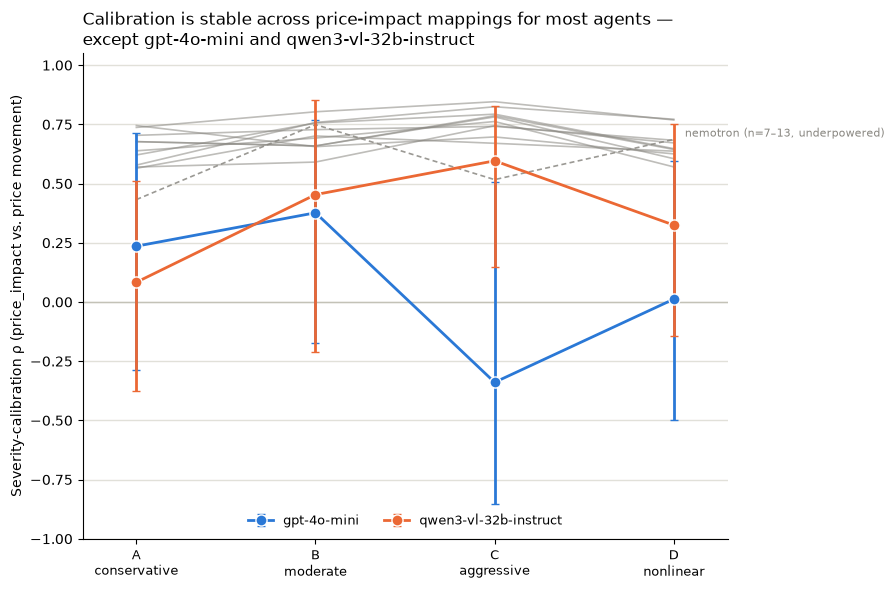

In [18]:
import matplotlib.pyplot as plt

MAPPING_LABELS = {"A_conservative": "A\nconservative", "B_moderate": "B\nmoderate",
                   "C_aggressive": "C\naggressive", "D_nonlinear": "D\nnonlinear"}
X = list(range(len(MAPPINGS)))

GRID = "#e1e0d9"
AXIS = "#c3c2b7"
GRAY_CONTEXT = "#898781"
ACCENT_1 = "#2a78d6"  # 팔레트 slot 1
ACCENT_2 = "#eb6834"  # 팔레트 slot 2

HIGHLIGHT = {"gpt-4o-mini": ACCENT_1, "qwen3-vl-32b-instruct": ACCENT_2}
UNDERPOWERED = {"nemotron-3-nano-omni-reasoning"}

fig, ax = plt.subplots(figsize=(9, 6))

# 배경 -- 안정적인 나머지 agent들 (마커 없이, 얇게, 회색)
for a in llm_agents:
    if a in HIGHLIGHT or a in UNDERPOWERED:
        continue
    ys = [results_h3[a][f"{m}_rho"] for m in MAPPINGS]
    ax.plot(X, ys, color=GRAY_CONTEXT, linewidth=1.2, alpha=0.55, zorder=2)

# 표본 부족(판단불가) -- 점선으로 구분, 별도 주석
a = "nemotron-3-nano-omni-reasoning"
ys = [results_h3[a][f"{m}_rho"] for m in MAPPINGS]
ax.plot(X, ys, color=GRAY_CONTEXT, linewidth=1.2, linestyle=(0, (3, 2)), alpha=0.85, zorder=2)
ax.annotate("nemotron (n=7–13, underpowered)", (X[-1], ys[-1]), textcoords="offset points",
            xytext=(8, 2), fontsize=8, color=GRAY_CONTEXT)

# 강조 -- 문제 있는 두 agent, CI 에러바 + 두꺼운 선 + 큰 마커
for a, color in HIGHLIGHT.items():
    ys = [results_h3[a][f"{m}_rho"] for m in MAPPINGS]
    los = [results_h3[a][f"{m}_lo"] for m in MAPPINGS]
    his = [results_h3[a][f"{m}_hi"] for m in MAPPINGS]
    yerr = [[y - l for y, l in zip(ys, los)], [h - y for y, h in zip(ys, his)]]
    ax.errorbar(X, ys, yerr=yerr, color=color, linewidth=2, marker="o", markersize=8,
                markerfacecolor=color, markeredgecolor="white", markeredgewidth=1,
                capsize=3, zorder=4, label=a)

ax.axhline(0, color=AXIS, linewidth=1, zorder=1)
ax.set_xticks(X)
ax.set_xticklabels([MAPPING_LABELS[m] for m in MAPPINGS], fontsize=9)
ax.set_xlim(-0.3, len(MAPPINGS) - 0.7)
ax.set_ylim(-1.0, 1.05)
ax.set_ylabel("Severity-calibration ρ (price_impact vs. price movement)")
ax.set_title("Calibration is stable across price-impact mappings for most agents —\n"
              "except gpt-4o-mini and qwen3-vl-32b-instruct", fontsize=12, loc="left")

ax.legend(loc="lower center", frameon=False, fontsize=9, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### H4: Hallucination과 surplus의 관계

`kernel.py`의 `evidence_term_for`는 지어낸(ground truth에 없는) 결함 인용을 명시적으로
무시하도록 설계돼 있다 — 실제 결함만 걸러서(`cited_real`) accept_prob 보너스를 계산하고,
할루시네이션은 economic하게 영향이 없어야 정상이다. H4는 이 설계가 실제로 지켜지는지,
즉 "지어낸 결함을 인용해도 더 유리한 협상 결과를 못 얻는다"를 확인한다.

- **Level 1 (agent간 대략적 확인)**: agent별 hallucination_rate(적어도 한 번 지어낸 결함을
  인용한 episode 비율) vs SE+/CSE+ — 13개 점으로 대략적인 상관관계 스캔
- **Level 2 (episode 단위, 같은 agent 내 비교)**: 같은 agent 안에서, 지어낸 결함만 인용하고
  실제 결함은 인용 안 한 episode와 아예 아무것도 인용 안 한 episode의 SE+ 차이 — agent별
  성향 차이를 통제한 더 정확한 비교
- 커널 설계대로라면 두 비교 모두 유의미한 차이가 없어야 함(할루시네이션 = 경제적 무보상).
  차이가 나온다면 커널 버그이거나, 할루시네이션이 다른 협상 행동(예: 전반적 공격성)과
  간접적으로 얽혀있다는 뜻.


In [19]:
import random
from metrics import spearman_rho
import pandas as pd

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]

pooled_by_agent = {
    a: [rec for m in MAPPINGS for rec in episodes_by_mapping[m]
        if rec["agent"] == a and not rec["violations"]]  # NEW -- critical violation 있는 episode 제외 (H2와 동일 이유)
    for a in llm_agents
}

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

def ground_truth_types(rec):
    return {d["defect_type"] for d in rec["item"]["defects"]}

def episode_se(rec):
    cfg = rec["episode_config"]
    role_A, r_A, r_B = cfg["role_A"], cfg["r_A"], cfg["t_B"]["r"]
    r_buyer = r_A if role_A == "BUYER" else r_B
    r_seller = r_B if role_A == "BUYER" else r_A
    delta = r_buyer - r_seller
    outcome = rec["outcome"]
    u = 0.0 if outcome is None else ((r_A - outcome) if role_A == "BUYER" else (outcome - r_A))
    return u / delta if delta else None

def stat_se_plus(s):
    vals = [v for r in s if (v := episode_se(r)) is not None]
    return sum(vals) / len(vals) if vals else None

def stat_cse_plus(s):
    vals = [episode_se(r) for r in s if r["outcome"] is not None]
    return sum(vals) / len(vals) if vals else None

def hallucination_rate(records):
    if not records:
        return None
    flagged = sum(1 for r in records if agent_citations(r) - ground_truth_types(r))
    return flagged / len(records)

# --- Level 1: agent간 대략적 확인 (13개 점) ---
level1_rows = []
for a in llm_agents:
    sample = pooled_by_agent[a]
    level1_rows.append({
        "agent": a,
        "hallucination_rate": hallucination_rate(sample),
        "SE+": stat_se_plus(sample),
        "CSE+": stat_cse_plus(sample),
    })
df_h4_l1 = pd.DataFrame(level1_rows).set_index("agent").sort_values("hallucination_rate", ascending=False)

hr_list = [r["hallucination_rate"] for r in level1_rows]
se_list = [r["SE+"] for r in level1_rows]
cse_list = [r["CSE+"] for r in level1_rows]
print("Level 1 -- agent간 Spearman rho (n=13):")
print("  hallucination_rate vs SE+ :", round(spearman_rho(hr_list, se_list), 3))
print("  hallucination_rate vs CSE+:", round(spearman_rho(hr_list, cse_list), 3))

# --- Level 2: 같은 agent 내, 지어낸 결함만 인용 vs 아예 인용 안 함 ---
def episode_category(rec):
    C = agent_citations(rec)
    D = ground_truth_types(rec)
    if not C:
        return "none"
    if C & D:
        return "real"
    return "fake_only"

def buckets_for_agent(records):
    b = {"fake_only": [], "none": []}
    for r in records:
        cat = episode_category(r)
        if cat in b:
            b[cat].append(r)
    return b

random.seed(0)
B = 2000

results_h4_l2 = {}
for a in llm_agents:
    buckets = buckets_for_agent(pooled_by_agent[a])
    n_fake, n_none = len(buckets["fake_only"]), len(buckets["none"])
    se_fake = stat_se_plus(buckets["fake_only"])
    se_none = stat_se_plus(buckets["none"])
    diff_point = (se_fake - se_none) if se_fake is not None and se_none is not None else None

    boot = []
    for _ in range(B):
        sf, sn = buckets["fake_only"], buckets["none"]
        rf = [sf[random.randrange(len(sf))] for _ in range(len(sf))] if sf else []
        rn = [sn[random.randrange(len(sn))] for _ in range(len(sn))] if sn else []
        vf, vn = stat_se_plus(rf), stat_se_plus(rn)
        if vf is not None and vn is not None:
            boot.append(vf - vn)
    boot.sort()
    ci = (boot[int(0.025 * len(boot))], boot[int(0.975 * len(boot))]) if boot else (None, None)

    results_h4_l2[a] = {
        "se_fake_only": se_fake, "n_fake": n_fake,
        "se_none": se_none, "n_none": n_none,
        "diff": diff_point, "diff_lo": ci[0], "diff_hi": ci[1],
    }

df_h4_l2 = pd.DataFrame(results_h4_l2).T
df_h4_l2["sig"] = (df_h4_l2["diff_lo"] > 0) | (df_h4_l2["diff_hi"] < 0)
df_h4_l2.round(3)


Level 1 -- agent간 Spearman rho (n=13):
  hallucination_rate vs SE+ : 0.17
  hallucination_rate vs CSE+: -0.022


,se_fake_only,n_fake,se_none,n_none,diff,diff_lo,diff_hi,sig
claude-opus-4.6,0.531,105.0,0.642,142.0,-0.111,-0.205,-0.022,True
claude-sonnet-4.6,0.624,157.0,0.525,65.0,0.100,-0.004,0.207,False
gemini-3.1-pro-preview,0.437,85.0,0.601,154.0,-0.164,-0.262,-0.067,True
gemma-4-31b-it,0.488,54.0,0.565,262.0,-0.077,-0.178,0.028,False
gpt-4o,0.491,70.0,0.533,100.0,-0.042,-0.149,0.062,False
gpt-4o-mini,0.183,45.0,0.185,140.0,-0.002,-0.080,0.083,False
gpt-5.5,0.529,65.0,0.565,192.0,-0.036,-0.134,0.064,False
grok-4.5,0.546,73.0,0.599,171.0,-0.053,-0.146,0.040,False
kimi-k3,0.508,80.0,0.615,208.0,-0.107,-0.196,-0.013,True
nemotron-3-nano-omni-reasoning,0.284,69.0,0.229,96.0,0.055,-0.048,0.172,False


**표 읽는 법**

`df_h4_l1` (Level 1):
- `hallucination_rate`: 그 agent가 지어낸 결함을 적어도 한 번 인용한 episode의 비율
- `SE+` / `CSE+`: 그 agent 전체 episode 기준 평균 surplus efficiency (H2와 동일 정의)

`df_h4_l2` (Level 2, 같은 agent 내 fake_only vs none):
- `se_fake_only`: 지어낸 결함만 인용하고(진짜 결함은 인용 안 함) 끝난 episode들의 평균 SE+
- `n_fake`: 그 episode 수
- `se_none`: 아무 결함도 인용 안 한 episode들의 평균 SE+
- `n_none`: 그 episode 수
- `diff`: se_fake_only − se_none (양수면 지어내는 쪽이 더 유리, 음수면 더 불리)
- `diff_lo` / `diff_hi`: diff의 95% 부트스트랩 신뢰구간
- `sig`: CI가 0을 완전히 비껴가는지(방향 무관) — 유의미한 차이가 있는지

**해석**

**Level 1 (agent간, n=13)**: `hallucination_rate` vs `SE+` rho=0.17, vs `CSE+` rho=-0.022 —
둘 다 0에 가까움. n=13에서 유의하려면 대략 0.55 이상 필요하니 노이즈 범위 — agent 단위
대략 비교로는 관계 없음.

**Level 2 (같은 agent 내, fake_only vs none)**: `sig=True`가 4개(claude-opus-4.6, gemini-3.1-pro-preview,
kimi-k3, qwen3-vl-32b-instruct)이고 **전부 음수**(-0.107~-0.174) — 지어낸 결함만 인용한
episode가 아무것도 인용 안 한 episode보다 SE+가 낮음. 나머지 9개는 유의하지 않지만
방향은 9개 중 5개가 음수 쪽(양수는 claude-sonnet-4.6/nemotron/qwen3.6-plus/thinkingmachines-inkling
4개뿐, 그마저 CI가 0에 가깝거나 걸침).

**한 줄 요약**: "속이면 이득 본다"는 방향은 어디서도 안 나옴. Level 1(대략적 비교)은 무관, Level 2(같은 agent 내 정밀 비교)는 오히려 지어낸 것 쪽이 더 나쁨 — 커널 설계
(`evidence_term_for`가 지어낸 결함을 무보상 처리)가 의도대로 작동하고 있다는 근거.


In [20]:
def buckets_for_agent(records):
    b = {"fake_only": [], "none": [], "real": []}
    for r in records:
        cat = episode_category(r)
        b[cat].append(r)
    return b

results_h4_l2 = {}
for a in llm_agents:
    buckets = buckets_for_agent(pooled_by_agent[a])
    n_fake, n_none, n_real = len(buckets["fake_only"]), len(buckets["none"]), len(buckets["real"])
    se_fake = stat_se_plus(buckets["fake_only"])
    se_none = stat_se_plus(buckets["none"])
    se_real = stat_se_plus(buckets["real"])

    def diff_and_ci(bucket_a, bucket_b, se_a, se_b):
        point = (se_a - se_b) if se_a is not None and se_b is not None else None
        boot = []
        for _ in range(B):
            ra = [bucket_a[random.randrange(len(bucket_a))] for _ in range(len(bucket_a))] if bucket_a else []
            rb = [bucket_b[random.randrange(len(bucket_b))] for _ in range(len(bucket_b))] if bucket_b else []
            va, vb = stat_se_plus(ra), stat_se_plus(rb)
            if va is not None and vb is not None:
                boot.append(va - vb)
        boot.sort()
        ci = (boot[int(0.025 * len(boot))], boot[int(0.975 * len(boot))]) if boot else (None, None)
        return point, ci

    diff_none, ci_none = diff_and_ci(buckets["fake_only"], buckets["none"], se_fake, se_none)
    diff_real, ci_real = diff_and_ci(buckets["fake_only"], buckets["real"], se_fake, se_real)

    results_h4_l2[a] = {
        "se_fake_only": se_fake, "n_fake": n_fake,
        "se_none": se_none, "n_none": n_none,
        "se_real": se_real, "n_real": n_real,
        "diff_vs_none": diff_none, "vs_none_lo": ci_none[0], "vs_none_hi": ci_none[1],
        "diff_vs_real": diff_real, "vs_real_lo": ci_real[0], "vs_real_hi": ci_real[1],
    }

df_h4_l2 = pd.DataFrame(results_h4_l2).T
df_h4_l2["sig_vs_none"] = (df_h4_l2["vs_none_lo"] > 0) | (df_h4_l2["vs_none_hi"] < 0)
df_h4_l2["sig_vs_real"] = (df_h4_l2["vs_real_lo"] > 0) | (df_h4_l2["vs_real_hi"] < 0)
df_h4_l2.round(3)


,se_fake_only,n_fake,se_none,n_none,se_real,n_real,diff_vs_none,vs_none_lo,vs_none_hi,diff_vs_real,vs_real_lo,vs_real_hi,sig_vs_none,sig_vs_real
claude-opus-4.6,0.531,105.0,0.642,142.0,0.588,146.0,-0.111,-0.209,-0.021,-0.057,-0.142,0.028,True,False
claude-sonnet-4.6,0.624,157.0,0.525,65.0,0.588,164.0,0.100,-0.012,0.207,0.036,-0.032,0.103,False,False
gemini-3.1-pro-preview,0.437,85.0,0.601,154.0,0.615,156.0,-0.164,-0.266,-0.066,-0.178,-0.279,-0.076,True,True
gemma-4-31b-it,0.488,54.0,0.565,262.0,0.538,78.0,-0.077,-0.188,0.029,-0.050,-0.167,0.064,False,False
gpt-4o,0.491,70.0,0.533,100.0,0.503,152.0,-0.042,-0.156,0.064,-0.012,-0.110,0.088,False,False
gpt-4o-mini,0.183,45.0,0.185,140.0,0.134,97.0,-0.002,-0.083,0.083,0.049,-0.036,0.138,False,False
gpt-5.5,0.529,65.0,0.565,192.0,0.548,123.0,-0.036,-0.130,0.054,-0.019,-0.123,0.083,False,False
grok-4.5,0.546,73.0,0.599,171.0,0.605,147.0,-0.053,-0.145,0.038,-0.059,-0.150,0.029,False,False
kimi-k3,0.508,80.0,0.615,208.0,0.520,103.0,-0.107,-0.203,-0.016,-0.011,-0.112,0.085,True,False
nemotron-3-nano-omni-reasoning,0.284,69.0,0.229,96.0,0.207,149.0,0.055,-0.057,0.172,0.077,-0.022,0.174,False,False


**표 읽는 법**

- `se_fake_only` / `n_fake`: 지어낸 결함만 인용한 episode의 평균 SE+와 개수
- `se_none` / `n_none`: 아무 결함도 인용 안 한 episode의 평균 SE+와 개수
- `se_real` / `n_real`: 실제 결함을 (적어도 하나) 인용한 episode의 평균 SE+와 개수
- `diff_vs_none` = se_fake_only − se_none : 지어낸 것과 침묵을 비교 ("거짓말이 침묵보다 나은가")
- `diff_vs_real` = se_fake_only − se_real : 지어낸 것과 진짜 인용을 비교 ("거짓말이 진짜 근거만큼 통하는가")
- `vs_none_lo/hi`, `vs_real_lo/hi`: 각 diff의 95% 부트스트랩 신뢰구간
- `sig_vs_none`, `sig_vs_real`: 해당 CI가 0을 완전히 비껴가는지(방향 무관)

**해석**

**vs_none**: 13개 중 4개 유의(claude-opus-4.6, gemini-3.1-pro-preview, kimi-k3,
qwen3-vl-32b-instruct), 전부 음수(-0.107~-0.174) — 지어낸 결함만 인용한 episode가
아무것도 인용 안 한 episode보다 SE+가 낮음.

**vs_real**: 13개 중 gemini-3.1-pro-preview **하나만** 유의(-0.178). 나머지 12개는
지어낸 것과 진짜 인용한 것 사이에 SE+ 차이가 뚜렷하지 않음 — `real`이 `none`과 더
비슷하고 `fake_only`만 유독 낮은 쪽에 가까움.

**한 줄 요약**: 거짓말이 이득을 준다는 근거는 어디에도 없음(vs_real에서 real이 확실히
앞서지 않는 건, `QUADRANT_BONUS`가 accept_prob만 살짝 보조하고 가격 자체는 안 바꾸도록
일부러 작게 설계됐기 때문일 수 있음 — kernel.py 2026-07-29 재조정 코멘트 참고). 반면
vs_none에서는 지어낸 쪽이 오히려 더 나쁨 — 거짓말이 그 episode 전반의 협상 부진과
같이 나타난다는 신호.


In [21]:
def stat_agr_plus(s):
    return sum(1 for r in s if r["outcome"] is not None) / len(s) if s else None

random.seed(0)
B = 2000

results_h4_agr = {}
for a in llm_agents:
    buckets = buckets_for_agent(pooled_by_agent[a])
    n_fake, n_none, n_real = len(buckets["fake_only"]), len(buckets["none"]), len(buckets["real"])
    agr_fake = stat_agr_plus(buckets["fake_only"])
    agr_none = stat_agr_plus(buckets["none"])
    agr_real = stat_agr_plus(buckets["real"])

    def diff_and_ci(bucket_a, bucket_b, val_a, val_b, stat_fn):
        point = (val_a - val_b) if val_a is not None and val_b is not None else None
        boot = []
        for _ in range(B):
            ra = [bucket_a[random.randrange(len(bucket_a))] for _ in range(len(bucket_a))] if bucket_a else []
            rb = [bucket_b[random.randrange(len(bucket_b))] for _ in range(len(bucket_b))] if bucket_b else []
            va, vb = stat_fn(ra), stat_fn(rb)
            if va is not None and vb is not None:
                boot.append(va - vb)
        boot.sort()
        ci = (boot[int(0.025 * len(boot))], boot[int(0.975 * len(boot))]) if boot else (None, None)
        return point, ci

    diff_none, ci_none = diff_and_ci(buckets["fake_only"], buckets["none"], agr_fake, agr_none, stat_agr_plus)
    diff_real, ci_real = diff_and_ci(buckets["fake_only"], buckets["real"], agr_fake, agr_real, stat_agr_plus)

    results_h4_agr[a] = {
        "agr_fake_only": agr_fake, "n_fake": n_fake,
        "agr_none": agr_none, "n_none": n_none,
        "agr_real": agr_real, "n_real": n_real,
        "diff_vs_none": diff_none, "vs_none_lo": ci_none[0], "vs_none_hi": ci_none[1],
        "diff_vs_real": diff_real, "vs_real_lo": ci_real[0], "vs_real_hi": ci_real[1],
    }

df_h4_agr = pd.DataFrame(results_h4_agr).T
df_h4_agr["sig_vs_none"] = (df_h4_agr["vs_none_lo"] > 0) | (df_h4_agr["vs_none_hi"] < 0)
df_h4_agr["sig_vs_real"] = (df_h4_agr["vs_real_lo"] > 0) | (df_h4_agr["vs_real_hi"] < 0)
df_h4_agr.round(3)


,agr_fake_only,n_fake,agr_none,n_none,agr_real,n_real,diff_vs_none,vs_none_lo,vs_none_hi,diff_vs_real,vs_real_lo,vs_real_hi,sig_vs_none,sig_vs_real
claude-opus-4.6,0.743,105.0,0.937,142.0,0.863,146.0,-0.194,-0.286,-0.108,-0.120,-0.224,-0.021,True,True
claude-sonnet-4.6,0.924,157.0,0.892,65.0,0.909,164.0,0.031,-0.053,0.125,0.015,-0.046,0.077,False,False
gemini-3.1-pro-preview,0.612,85.0,0.942,154.0,0.878,156.0,-0.330,-0.437,-0.219,-0.266,-0.380,-0.160,True,True
gemma-4-31b-it,0.722,54.0,0.851,262.0,0.833,78.0,-0.129,-0.252,-0.011,-0.111,-0.254,0.038,True,False
gpt-4o,0.814,70.0,0.940,100.0,0.842,152.0,-0.126,-0.221,-0.026,-0.028,-0.134,0.077,True,False
gpt-4o-mini,0.689,45.0,0.443,140.0,0.515,97.0,0.246,0.078,0.398,0.173,0.000,0.334,True,True
gpt-5.5,0.923,65.0,0.979,192.0,0.870,123.0,-0.056,-0.128,0.005,0.053,-0.034,0.140,False,False
grok-4.5,0.836,73.0,0.930,171.0,0.898,147.0,-0.094,-0.194,-0.004,-0.062,-0.158,0.033,True,False
kimi-k3,0.762,80.0,0.870,208.0,0.816,103.0,-0.108,-0.213,-0.004,-0.053,-0.170,0.061,True,False
nemotron-3-nano-omni-reasoning,0.667,69.0,0.562,96.0,0.604,149.0,0.104,-0.051,0.254,0.063,-0.081,0.194,False,False


**표 읽는 법**

- `agr_fake_only` / `n_fake`: 지어낸 결함만 인용한 episode의 평균 AGR+(성사율)와 개수
- `agr_none` / `n_none`: 아무 결함도 인용 안 한 episode의 평균 AGR+와 개수
- `agr_real` / `n_real`: 실제 결함을 인용한 episode의 평균 AGR+와 개수
- `diff_vs_none` = agr_fake_only − agr_none, `diff_vs_real` = agr_fake_only − agr_real
- `vs_none_lo/hi`, `vs_real_lo/hi`: 각 diff의 95% 부트스트랩 신뢰구간
- `sig_vs_none`, `sig_vs_real`: 해당 CI가 0을 완전히 비껴가는지

**해석**

**vs_none**: 13개 중 7개 유의 — claude-opus-4.6, gemini-3.1-pro-preview, gemma-4-31b-it,
gpt-4o, grok-4.5, kimi-k3는 전부 음수(지어내면 성사율이 낮아짐). **gpt-4o-mini만 정반대로
+0.246**로 강하게 유의.

**vs_real**: 3개 유의 — claude-opus-4.6(-0.120), gemini-3.1-pro-preview(-0.266)는 여전히
음수(진짜 인용보다도 성사율 낮음), gpt-4o-mini는 여기서도 +0.173로 반대 방향.

**SE+보다 훨씬 강한 신호**: `QUADRANT_BONUS`는 accept_prob(수락 확률)에 직접 붙는 항이라
"성사됐나"(AGR+)에 "가격을 얼마나 뜯어냈나"(SE+)보다 더 직접적으로 반영됨. fake_only가
none보다도 낮게 나온 건 보너스 부재(0=0) 이상의 뭔가 — 그 episode에서 agent가 애초에
무리한 가격을 부르고 있었을 가능성.

**gpt-4o-mini는 확실한 예외**(vs_none, vs_real 둘 다 유의하게 양수) — H1/H3에서도 계속
특이 케이스였던 모델. H6(agent별 편차)에서 따로 파볼 후보.

In [22]:
random.seed(0)
B = 2000

results_h4_cse = {}
for a in llm_agents:
    buckets = buckets_for_agent(pooled_by_agent[a])
    n_fake, n_none, n_real = len(buckets["fake_only"]), len(buckets["none"]), len(buckets["real"])
    cse_fake = stat_cse_plus(buckets["fake_only"])
    cse_none = stat_cse_plus(buckets["none"])
    cse_real = stat_cse_plus(buckets["real"])

    diff_none, ci_none = diff_and_ci(buckets["fake_only"], buckets["none"], cse_fake, cse_none, stat_cse_plus)
    diff_real, ci_real = diff_and_ci(buckets["fake_only"], buckets["real"], cse_fake, cse_real, stat_cse_plus)

    results_h4_cse[a] = {
        "cse_fake_only": cse_fake, "n_fake": n_fake,
        "cse_none": cse_none, "n_none": n_none,
        "cse_real": cse_real, "n_real": n_real,
        "diff_vs_none": diff_none, "vs_none_lo": ci_none[0], "vs_none_hi": ci_none[1],
        "diff_vs_real": diff_real, "vs_real_lo": ci_real[0], "vs_real_hi": ci_real[1],
    }

df_h4_cse = pd.DataFrame(results_h4_cse).T
df_h4_cse["sig_vs_none"] = (df_h4_cse["vs_none_lo"] > 0) | (df_h4_cse["vs_none_hi"] < 0)
df_h4_cse["sig_vs_real"] = (df_h4_cse["vs_real_lo"] > 0) | (df_h4_cse["vs_real_hi"] < 0)
df_h4_cse.round(3)


,cse_fake_only,n_fake,cse_none,n_none,cse_real,n_real,diff_vs_none,vs_none_lo,vs_none_hi,diff_vs_real,vs_real_lo,vs_real_hi,sig_vs_none,sig_vs_real
claude-opus-4.6,0.715,105.0,0.686,142.0,0.681,146.0,0.029,-0.050,0.104,0.034,-0.027,0.095,False,False
claude-sonnet-4.6,0.676,157.0,0.588,65.0,0.647,164.0,0.088,-0.009,0.195,0.029,-0.031,0.091,False,False
gemini-3.1-pro-preview,0.715,85.0,0.639,154.0,0.700,156.0,0.076,-0.014,0.162,0.014,-0.070,0.096,False,False
gemma-4-31b-it,0.676,54.0,0.663,262.0,0.646,78.0,0.012,-0.062,0.087,0.030,-0.061,0.113,False,False
gpt-4o,0.603,70.0,0.567,100.0,0.597,152.0,0.036,-0.070,0.139,0.006,-0.089,0.102,False,False
gpt-4o-mini,0.266,45.0,0.418,140.0,0.260,97.0,-0.151,-0.264,-0.037,0.006,-0.106,0.122,True,False
gpt-5.5,0.573,65.0,0.577,192.0,0.630,123.0,-0.004,-0.099,0.089,-0.057,-0.154,0.045,False,False
grok-4.5,0.653,73.0,0.644,171.0,0.674,147.0,0.009,-0.065,0.083,-0.021,-0.090,0.055,False,False
kimi-k3,0.666,80.0,0.707,208.0,0.637,103.0,-0.040,-0.113,0.034,0.029,-0.048,0.106,False,False
nemotron-3-nano-omni-reasoning,0.426,69.0,0.406,96.0,0.342,149.0,0.019,-0.142,0.171,0.083,-0.040,0.212,False,False


**표 읽는 법**

- `cse_fake_only` / `n_fake`: 지어낸 결함만 인용하고 **성사된** episode만의 평균 SE+ (조건부)
- `cse_none` / `n_none`, `cse_real` / `n_real`: 마찬가지로 각각 성사된 episode만
- `diff_vs_none`/`diff_vs_real`, CI, `sig_*`: AGR+ 표와 동일한 구조

**해석**

**vs_none**: 3개만 유의 — gpt-4o-mini(-0.151), qwen3-vl-32b-instruct(-0.157)는 음수(성사돼도
가격이 나쁨), thinkingmachines-inkling(+0.086)만 양수(CI 하한이 0.003으로 간신히 유의).

**vs_real**: 13개 전부 유의하지 않음 — CSE+ 축에서는 지어낸 것과 진짜 인용한 것 사이에
차이가 거의 없음.

**AGR+/CSE+를 합쳐서 보면 agent마다 penalty가 나오는 경로가 다릅니다**:
- **claude-opus-4.6, gemini-3.1-pro-preview**: AGR+에서는 강하게 유의(둘 다 vs_none/vs_real
  모두 음수)한데 CSE+는 완전히 무관(0 근처, 안 유의). 즉 이 둘의 penalty는 **100% "성사가
  덜 된다"**에서 오고, 성사만 되면 가격 자체는 똑같이 잘 받음.
- **gpt-4o-mini**: AGR+는 오히려 **양수**(더 잘 성사됨)인데 CSE+는 **음수**(성사돼도 가격이
  나쁨) — 지어낸 결함을 대면서 **빨리, 대신 나쁜 조건에 합의해버리는** 패턴에 가까움. 다른
  agent들과 정반대 기전.
- **qwen3-vl-32b-instruct**: AGR+는 안 유의, CSE+만 유의(음수) — 성사율엔 영향 없지만
  성사됐을 때 가격이 나쁨.

**한 줄 요약**: 거짓말이 이득을 준다는 증거는 끝까지 안 나왔고, 오히려 대부분 agent에서
손해(주로 성사율 하락)로 이어짐. 단 그 손해가 나타나는 경로는 agent마다 다름 — 대부분은
"덜 성사됨"이지만 gpt-4o-mini는 "더 쉽게, 더 나쁘게 성사됨"이라는 독특한 패턴을 보임 —
H6에서 개별적으로 다시 볼 후보.


### H5: Agent별 quadrant 약점의 mapping 안정성

agent마다 "이 quadrant에서 유독 약하다"는 패턴("지문")이 4개 mapping에 걸쳐 고정적으로
나타나는지 확인한다. 고정적이면 agent의 진짜 능력 특성, mapping마다 흔들리면 특정
price curve에 대한 우연/overfitting일 가능성.

- **측정**: agent × mapping × quadrant(4×4×4)로 SE+ 계산 (violation 있는 episode 제외,
  H2와 동일 이유). 이번엔 mapping별로 따로 봐야 하므로 풀링하지 않음.
- **Test 1 (범주형)**: agent별로 mapping마다 "가장 SE+가 낮은 quadrant(worst quadrant)"가
  4개 mapping 전부 같은지 확인 — 같으면 fingerprint가 고정적.
- **Test 2 (순위 상관, 보조지표)**: mapping 쌍(6개 조합)마다 4-quadrant SE+ 프로파일의
  Spearman ρ. **주의**: n=4(quadrant 4개)짜리 상관계수라 통계적 검정력이 매우 낮음 —
  참고용 보조지표로만 쓰고 유의성 검정은 안 함.
- **알려진 한계**: H2에서 확인했듯 SE+를 quadrant 전체(인용 여부 무관)로 재면 detection을
  못 한 episode가 섞여 agent-specific 신호가 희석될 수 있음. citation 조건부로 좁히면
  (mapping별로 쪼개면 표본이 한 자릿수까지 떨어져) 이번엔 표본이 너무 적어짐 — 그래서
  여기서는 quadrant 전체 SE+를 쓰되, 나온 패턴이 약하게 나올 수 있다는 걸 감안해서 해석.


In [23]:
QUADRANTS4 = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]
METRICS = ["SE+", "AGR+", "CSE+"]
STAT_FNS = {"SE+": stat_se_plus, "AGR+": stat_agr_plus, "CSE+": stat_cse_plus}

# agent x mapping x quadrant(4x4x4)로 SE+/AGR+/CSE+ 계산 (violation 있는 episode 제외, H2와 동일 이유)
rows = []
for a in llm_agents:
    for m in MAPPINGS:
        for q in QUADRANTS4:
            recs = [r for r in episodes_by_mapping[m]
                    if r["agent"] == a and not r["violations"] and episode_quadrant(r) == q]
            row = {"agent": a, "mapping": m, "quadrant": q, "n": len(recs)}
            for name, fn in STAT_FNS.items():
                row[name] = fn(recs)
            rows.append(row)
df_h5_raw = pd.DataFrame(rows)

# (agent, mapping)별 worst quadrant -- 지표별로 그 mapping 안에서 4개 quadrant 중 최저값을 찾음
worst_rows = []
for a in llm_agents:
    for m in MAPPINGS:
        sub = df_h5_raw[(df_h5_raw["agent"] == a) & (df_h5_raw["mapping"] == m)]
        row = {"agent": a, "mapping": m}
        for name in METRICS:
            valid = sub.dropna(subset=[name])
            row[f"worst_{name}"] = valid.loc[valid[name].idxmin(), "quadrant"] if not valid.empty else None
        worst_rows.append(row)
df_h5_worst = pd.DataFrame(worst_rows)
df_h5_worst


,agent,mapping,worst_SE+,worst_AGR+,worst_CSE+
0,claude-opus-4.6,A_conservative,obvious_aligned,obvious_aligned,subtle_misaligned
1,claude-opus-4.6,B_moderate,obvious_aligned,subtle_misaligned,obvious_aligned
2,claude-opus-4.6,C_aggressive,obvious_aligned,subtle_misaligned,obvious_aligned
3,claude-opus-4.6,D_nonlinear,obvious_misaligned,subtle_misaligned,obvious_misaligned
4,claude-sonnet-4.6,A_conservative,obvious_misaligned,subtle_misaligned,obvious_aligned
5,claude-sonnet-4.6,B_moderate,obvious_misaligned,obvious_aligned,obvious_misaligned
6,claude-sonnet-4.6,C_aggressive,obvious_aligned,obvious_aligned,obvious_misaligned
7,claude-sonnet-4.6,D_nonlinear,obvious_misaligned,subtle_misaligned,obvious_misaligned
8,gemini-3.1-pro-preview,A_conservative,subtle_misaligned,subtle_misaligned,subtle_misaligned
9,gemini-3.1-pro-preview,B_moderate,subtle_misaligned,subtle_misaligned,obvious_misaligned


In [24]:
from collections import Counter

consistency_rows = []
for a in llm_agents:
    sub = df_h5_worst[df_h5_worst["agent"] == a]
    row = {"agent": a}
    for name in METRICS:
        worsts = [w for w in sub[f"worst_{name}"].tolist() if w is not None]
        if not worsts:
            row[f"mode_{name}"] = None
            row[f"agree_{name}"] = 0
            continue
        mode_q, count = Counter(worsts).most_common(1)[0]
        row[f"mode_{name}"] = mode_q
        row[f"agree_{name}"] = count  # 4개 mapping 중 몇 개가 mode와 일치하는지
        row[f"worst_{name}_by_mapping"] = worsts
    consistency_rows.append(row)
df_h5_consistency = pd.DataFrame(consistency_rows).set_index("agent")
df_h5_consistency


,mode_SE+,agree_SE+,worst_SE+_by_mapping,mode_AGR+,agree_AGR+,worst_AGR+_by_mapping,mode_CSE+,agree_CSE+,worst_CSE+_by_mapping
agent,,,,,,,,,
claude-opus-4.6,obvious_aligned,3,"[obvious_aligned, obvious_aligned, obvious_ali...",subtle_misaligned,3,"[obvious_aligned, subtle_misaligned, subtle_mi...",obvious_aligned,2,"[subtle_misaligned, obvious_aligned, obvious_a..."
claude-sonnet-4.6,obvious_misaligned,3,"[obvious_misaligned, obvious_misaligned, obvio...",subtle_misaligned,2,"[subtle_misaligned, obvious_aligned, obvious_a...",obvious_misaligned,3,"[obvious_aligned, obvious_misaligned, obvious_..."
gemini-3.1-pro-preview,subtle_misaligned,2,"[subtle_misaligned, subtle_misaligned, obvious...",subtle_misaligned,4,"[subtle_misaligned, subtle_misaligned, subtle_...",obvious_misaligned,3,"[subtle_misaligned, obvious_misaligned, obviou..."
gemma-4-31b-it,subtle_aligned,2,"[obvious_aligned, subtle_aligned, subtle_align...",subtle_aligned,4,"[subtle_aligned, subtle_aligned, subtle_aligne...",obvious_misaligned,3,"[obvious_aligned, obvious_misaligned, obvious_..."
gpt-4o,obvious_aligned,3,"[obvious_aligned, subtle_aligned, obvious_alig...",obvious_aligned,2,"[obvious_aligned, subtle_misaligned, obvious_a...",subtle_aligned,2,"[obvious_aligned, subtle_aligned, subtle_align..."
gpt-4o-mini,subtle_aligned,2,"[obvious_misaligned, subtle_aligned, subtle_al...",obvious_misaligned,2,"[obvious_misaligned, subtle_aligned, subtle_al...",obvious_misaligned,2,"[obvious_misaligned, obvious_aligned, obvious_..."
gpt-5.5,obvious_aligned,4,"[obvious_aligned, obvious_aligned, obvious_ali...",subtle_misaligned,3,"[obvious_aligned, subtle_misaligned, subtle_mi...",obvious_aligned,4,"[obvious_aligned, obvious_aligned, obvious_ali..."
grok-4.5,obvious_misaligned,2,"[subtle_misaligned, obvious_misaligned, obviou...",obvious_misaligned,2,"[obvious_misaligned, obvious_misaligned, subtl...",obvious_misaligned,2,"[subtle_misaligned, obvious_misaligned, obviou..."
kimi-k3,obvious_aligned,2,"[obvious_aligned, obvious_misaligned, obvious_...",obvious_misaligned,2,"[obvious_misaligned, obvious_misaligned, obvio...",obvious_aligned,2,"[obvious_aligned, obvious_misaligned, obvious_..."


**표 읽는 법**

- `mode_{metric}`: agent가 4개 mapping 중 "가장 성적이 나쁜 quadrant"로 가장 자주 나온 quadrant
- `agree_{metric}`: 그 mode가 4개 mapping 중 몇 번 나왔는지 (4=완전일치, 1=전부 다름)
- `worst_{metric}_by_mapping`: 4개 mapping(A_conservative→D_nonlinear 순) 각각에서 나온
  worst quadrant 원본 리스트

**해석**

- `agree_SE+`=4(완전일치)는 gpt-5.5, nemotron 둘뿐 — 둘 다 만성 약점이 `obvious_aligned`
  (가장 쉬운 조건인데도 가장 나쁨). `agree_CSE+`도 이 둘만 4/4.
- `agree_SE+`=1(4개 mapping 전부 다른 quadrant)은 thinkingmachines-inkling 하나뿐 —
  39칸(13 agent × 3 metric) 중 유일하게 fingerprint가 안 보이는 경우.
- **주의**: agree=2~3이 흔하다고 "불안정하다"로 읽으면 안 됨 — 아래 무작위 기준선 대비
  확인 필요.

**무작위 기준선과 비교(시뮬레이션, N=200,000)**:

| agree | 관측(39칸) | 무작위 기준선 |
|---|---|---|
| 4 | ~15% | ~1.6% |
| 3 | ~31% | ~18.9% |
| 2 | ~51% | ~70.2% |
| 1 | ~3% | ~9.3% |

완전일치(4)가 무작위 기대치의 거의 10배, 전부-다름(1)은 1/3 수준 — quadrant 약점이
mapping 4개에 걸쳐 순수 우연보다 훨씬 안정적으로 나타난다는 근거. 완벽하진 않지만
"진짜 fingerprint가 있다"는 결론을 지지함.


In [25]:
import random
from collections import Counter

# 관측된 agree 분포 (agent x metric, 13 x 3 = 39칸) -- df_h5_consistency에서 직접 뽑음
observed_agree = []
for a in llm_agents:
    row = df_h5_consistency.loc[a]
    for name in METRICS:
        observed_agree.append(row[f"agree_{name}"])

observed_dist = Counter(observed_agree)
n_cells = len(observed_agree)

# 무작위 기준선: quadrant 4개 중 완전 무작위로 4번(mapping 개수) 뽑았을 때 agree 분포
random.seed(0)
N_SIM = 200_000
chance_dist = Counter()
for _ in range(N_SIM):
    draws = [random.choice(QUADRANTS4) for _ in range(4)]
    mode_count = Counter(draws).most_common(1)[0][1]
    chance_dist[mode_count] += 1

print(f"{'agree':>6s} {'observed':>10s} {'chance':>10s}")
for k in [4, 3, 2, 1]:
    obs_pct = observed_dist.get(k, 0) / n_cells * 100
    chance_pct = chance_dist.get(k, 0) / N_SIM * 100
    print(f"{k:>6d} {obs_pct:>9.1f}% {chance_pct:>9.1f}%")


 agree   observed     chance
     4      15.4%       1.6%
     3      30.8%      18.9%
     2      51.3%      70.2%
     1       2.6%       9.3%


In [26]:
summary_rows = []
for a in llm_agents:
    row = df_h5_consistency.loc[a]
    summary_rows.append({
        "agent": a,
        "weak_quadrant_SE+": f'{row["mode_SE+"]} ({row["agree_SE+"]}/4)',
        "weak_quadrant_AGR+": f'{row["mode_AGR+"]} ({row["agree_AGR+"]}/4)',
        "weak_quadrant_CSE+": f'{row["mode_CSE+"]} ({row["agree_CSE+"]}/4)',
    })
df_h5_summary = pd.DataFrame(summary_rows).set_index("agent")
df_h5_summary


,weak_quadrant_SE+,weak_quadrant_AGR+,weak_quadrant_CSE+
agent,,,
claude-opus-4.6,obvious_aligned (3/4),subtle_misaligned (3/4),obvious_aligned (2/4)
claude-sonnet-4.6,obvious_misaligned (3/4),subtle_misaligned (2/4),obvious_misaligned (3/4)
gemini-3.1-pro-preview,subtle_misaligned (2/4),subtle_misaligned (4/4),obvious_misaligned (3/4)
gemma-4-31b-it,subtle_aligned (2/4),subtle_aligned (4/4),obvious_misaligned (3/4)
gpt-4o,obvious_aligned (3/4),obvious_aligned (2/4),subtle_aligned (2/4)
gpt-4o-mini,subtle_aligned (2/4),obvious_misaligned (2/4),obvious_misaligned (2/4)
gpt-5.5,obvious_aligned (4/4),subtle_misaligned (3/4),obvious_aligned (4/4)
grok-4.5,obvious_misaligned (2/4),obvious_misaligned (2/4),obvious_misaligned (2/4)
kimi-k3,obvious_aligned (2/4),obvious_misaligned (2/4),obvious_aligned (2/4)


**표 읽는 법**

- `weak_quadrant_{metric}`: 그 agent가 4개 mapping에 걸쳐 가장 자주 "제일 나쁜 quadrant"로
  꼽힌 quadrant와, 괄호 안은 4개 mapping 중 몇 번 그 quadrant가 나왔는지(agree count)

**해석**

**metric마다 "주범" quadrant가 다릅니다** — 13개 agent를 각 metric 기준 mode로 집계하면:

| metric | 가장 흔한 약점 quadrant | 해당 agent 수 |
|---|---|---|
| SE+ | `obvious_aligned` | 6/13 |
| AGR+ | `subtle_misaligned` | 5/13 |
| CSE+ | `obvious_misaligned` | 7/13 |

- **AGR+의 `subtle_misaligned`**는 H1에서 이미 본 것과 일치 — detection도 어렵고
  grounding도 어려운 조건이니 성사율이 낮은 게 예상대로.
- **SE+의 `obvious_aligned`**는 반직관적 — "가장 쉬운 조건"이 오히려 만성 최약점인
  agent가 절반에 가까움(claude-opus-4.6, gpt-4o, gpt-5.5, kimi-k3, nemotron, qwen3-vl-32b).
  gpt-5.5/nemotron은 4/4 완전일치라 우연이 아님.
- **CSE+의 `obvious_misaligned`**는 지금까지 다룬 적 없는 새 패턴 — 성사된 거래의 가격
  품질이 이 quadrant에서 제일 자주 나쁨. H1의 bias 분석(obvious_misaligned 과잉반응
  없음)과 모순은 아니지만, 왜 하필 여기서 CSE+가 나쁜지는 아직 설명 안 됨 — 추가로
  파볼 만한 지점.

**요약**: SE+ 하나만 보면 "obvious_aligned가 문제"로 보이지만, AGR+/CSE+로 쪼개면 각각
다른 quadrant가 범인으로 나옴 — 이것도 H1의 교훈("합계 지표는 실패 위치를 숨긴다")과
같은 패턴.


**⚠️ 이 H5 결과는 폐기됨 — 아래 "H5_retrial" 참고**

role(BUYER/SELLER)을 안 나누고 quadrant를 비교한 게 근본적 결함으로 드러남 —
quadrant 배정 자체가 role과 균등하지 않았고(obvious_aligned=BUYER 60% vs
subtle_misaligned=BUYER 35%), counterpart의 첫 제안 극단성도 role에 따라 7배 차이남
(counterpart가 SELLER일 때 평균 36% 이탈 vs BUYER일 때 5.4%). 위 표의 "obvious_aligned
만성 약점" 같은 결론은 상당 부분 이 confound가 만든 착시. 상세 경위는 `analysis.md`
H5 항목 참고.


### H5_retrial: role(BUYER/SELLER)을 통제한 quadrant 약점 재분석

H5가 quadrant만 비교하고 role을 안 나눈 게 문제였다는 게 드러나서(위 폐기 배너 참고),
agent x role x mapping x quadrant로 쪼개서 다시 본다. 계산 코드의 상세 배경 설명은
코드 셀 상단 주석 참고.


In [27]:
from collections import Counter
import pandas as pd

# ============================================================
# H5_retrial: role(BUYER/SELLER)을 통제한 quadrant 약점 재분석
# ------------------------------------------------------------
# 배경: 원래 H5(worst quadrant fingerprint)를 돌린 뒤, H6로 넘어가면서
# gpt-5.5/nemotron의 transcript를 직접 읽다가 "BUYER 역할일 때 counterpart가
# 훨씬 더 극단적인 첫 제안을 부른다"는 패턴을 발견함. 확인해보니:
#   - 13개 agent 전원이 SE+ 기준 BUYER < SELLER (예외 없음)
#   - 원인: p_min=0(고정 하한)인데 p_max는 훨씬 크게 잡혀있어서, counterpart가
#     SELLER일 때(=agent가 BUYER) 자기 reservation에서 벗어날 수 있는 폭(slack)이
#     counterpart가 BUYER일 때보다 구조적으로 훨씬 큼 (평균 이탈폭 36% vs 5.4%,
#     R로 정규화). 코드 어디에도 이 비대칭이 의도됐다는 근거(날짜 붙은 코멘트)가 없어서
#     설계 시 의도치 않은 confound로 판단.
#   - 결정적으로: quadrant 배정이 role과 무관하게 균등하지 않았음.
#     obvious_aligned=BUYER 60.0%, subtle_aligned=38.8%, subtle_misaligned=35.3%
#     (obvious_misaligned만 51.1%로 거의 균형) — 25%p까지 벌어짐.
# 결론: 원래 H5가 "obvious_aligned이 만성 약점"이라고 본 것 중 상당 부분이
# quadrant 자체 문제가 아니라, 그 quadrant에 어려운 역할(BUYER)이 우연히 더 많이
# 몰려서 생긴 착시일 수 있음. 그래서 role을 나눠서 quadrant 효과가 role과
# 무관하게 진짜로 남아있는지 재검증한다.
# ============================================================

rows = []
for a in llm_agents:
    for role in ["BUYER", "SELLER"]:
        for m in MAPPINGS:
            for q in QUADRANTS4:
                recs = [r for r in episodes_by_mapping[m]
                        if r["agent"] == a and not r["violations"]
                        and episode_quadrant(r) == q
                        and r["episode_config"]["role_A"] == role]
                se = stat_se_plus(recs)
                rows.append({"agent": a, "role": role, "mapping": m, "quadrant": q, "n": len(recs), "SE+": se})

df_h5_retrial_raw = pd.DataFrame(rows)

# (agent, role, mapping)별 worst quadrant -- role을 고정한 채로 4개 quadrant 중 최저 SE+
worst_rows = []
for a in llm_agents:
    for role in ["BUYER", "SELLER"]:
        for m in MAPPINGS:
            sub = df_h5_retrial_raw[(df_h5_retrial_raw["agent"] == a) & (df_h5_retrial_raw["role"] == role) & (df_h5_retrial_raw["mapping"] == m)]
            valid = sub.dropna(subset=["SE+"])
            worst_q = valid.loc[valid["SE+"].idxmin(), "quadrant"] if not valid.empty else None
            worst_rows.append({"agent": a, "role": role, "mapping": m, "worst_quadrant": worst_q})
df_h5_retrial_worst = pd.DataFrame(worst_rows)

# agent x role별로 4개 mapping 중 최빈 worst quadrant(mode) + 몇 번 나왔는지(agree)
# -- 원래 H5의 mode_SE+/agree_SE+와 같은 방식이지만 role별로 따로 계산한 버전
summary_rows = []
for a in llm_agents:
    row = {"agent": a}
    for role in ["BUYER", "SELLER"]:
        sub = df_h5_retrial_worst[(df_h5_retrial_worst["agent"] == a) & (df_h5_retrial_worst["role"] == role)]
        worsts = [w for w in sub["worst_quadrant"].tolist() if w is not None]
        if worsts:
            mode_q, count = Counter(worsts).most_common(1)[0]
            row[f"worst_{role}"] = f"{mode_q} ({count}/4)"
        else:
            row[f"worst_{role}"] = None
    summary_rows.append(row)

df_h5_retrial_summary = pd.DataFrame(summary_rows).set_index("agent")
df_h5_retrial_summary


,worst_BUYER,worst_SELLER
agent,,
claude-opus-4.6,obvious_aligned (2/4),subtle_misaligned (2/4)
claude-sonnet-4.6,obvious_misaligned (4/4),subtle_misaligned (2/4)
gemini-3.1-pro-preview,subtle_aligned (2/4),subtle_misaligned (3/4)
gemma-4-31b-it,subtle_aligned (4/4),subtle_misaligned (4/4)
gpt-4o,subtle_aligned (2/4),subtle_aligned (2/4)
gpt-4o-mini,subtle_aligned (2/4),obvious_misaligned (2/4)
gpt-5.5,obvious_aligned (3/4),subtle_misaligned (2/4)
grok-4.5,obvious_misaligned (2/4),subtle_misaligned (1/4)
kimi-k3,obvious_misaligned (3/4),obvious_aligned (2/4)


**해석**

- BUYER와 SELLER의 worst quadrant가 **같은 agent는 gpt-4o 하나뿐** — 나머지 12개는
  역할마다 다른 quadrant가 약점으로 나옴. 대부분 agent는 "quadrant 지문 하나"가 아니라
  "역할별로 다른 지문 두 개"를 가짐.
- 원래 H5 결과가 role 하나와는 맞아떨어지는 경우가 11/13. 일부는 role로 나누니 신호가
  더 강해짐 — claude-sonnet-4.6(3/4→BUYER 4/4), gemma-4-31b-it(2/4→BUYER 4/4 &
  SELLER 4/4 둘 다 완벽). 원래는 두 개의 강한 신호가 섞여서 뭉개져 있었던 것.
- nemotron: 원래 "obvious_aligned 4/4 완벽"이었는데, BUYER는 quadrant 안 가리고 전부
  바닥(사실상 무작위)이고 **SELLER에서만 obvious_aligned(3/4)이 진짜 신호** — 원래
  결과는 BUYER의 전반적 무능이 만든 착시가 상당 부분 섞여있었음.
- **gpt-4o, qwen3-vl-32b-instruct는 원래 H5 결과가 role 어느 쪽과도 안 맞음** — 순수
  confound가 만든 유령 신호였던 것으로 확인.

**한 줄 요약**: 원래 H5의 "quadrant 지문" 결론은 신뢰할 수 없음. agent마다 BUYER/SELLER
각각의 약점 quadrant를 따로 봐야 정확한 그림이 나온다.


### H6: Agent별 편차/이상치 진단

H1~H5는 전부 "13개 agent 중 몇 개가 유의미한가" 같은 집단 수준 질문이었다. 근데 이
벤치마크가 원래 하려는 건 순위표가 아니라 "이 모델이 정확히 어디서, 왜 무너지는가"를
찾는 것. H6은 그동안 나온 숫자들 중에서 유독
튀는 agent를 하나씩 짚어서, 그게 왜 그런지 파고든다.

**H5에서 넘어온 후보들**:
- gpt-5.5, nemotron: SE+/CSE+ 둘 다 4개 mapping 전부에서 "obvious_aligned"가 제일
  나쁨(완전일치, 우연 아님). 왜 하필 가장 쉬운 조건에서 만성적으로 나쁠까?
- thinkingmachines-inkling: SE+ 기준으로는 4개 mapping마다 약점 quadrant가 매번
  달라짐(agree=1) — 다른 12개와 다르게 진짜 fingerprint가 없는 유일한 케이스. 진짜
  무작위인지, 다른 이유가 있는지.
- CSE+에서는 obvious_misaligned가 7/13으로 제일 흔한 약점인데, 이건 H1의 bias 분석
  (obvious_misaligned에서 과잉반응 없었음)이랑 안 겹침 — 다른 원인이 있다는 뜻.

**H1/H4에서 넘어온 후보들**:
- claude-opus-4.6, nemotron: subtle_misaligned를 단일 인용한 turn 자체가 없어서(n=0)
  H1의 grounding 측정이 아예 안 됐던 케이스. 왜 이 quadrant를 이렇게까지 안 건드리는지.
- gpt-4o-mini: 할루시네이션 episode에서 다른 agent와 반대로 성사율은 오히려 오르고
  가격은 나빠짐(H4) — "빨리, 나쁘게 합의해버리는" 패턴이 다른 데서도 보이는지.

**하는 방식**: 지금까지는 숫자로 "이런 패턴이 있다"까지 찾았고, H6에서는 위 후보
agent들을 한 명씩 붙잡고 실제 transcript(협상 대화 기록)를 몇 개 직접 읽어서 "숫자
뒤에서 진짜 무슨 일이 일어나고 있는지"를 확인한다. gemini의 $300,000 offer를 찾아냈던
것처럼, 원문을 봐야만 알 수 있는 이유가 있을 가능성이 높다.


#### H6 (사전 조사): gpt-5.5/nemotron role×quadrant 분해 — H9의 발단

H5에서 gpt-5.5/nemotron의 obvious_aligned 만성 약점을 transcript로 직접 읽다가 BUYER
episode에서 상대가 극단적으로 높은 첫 제안을 부르는 걸 발견 → 이게 quadrant 자체
문제인지 역할이 섞여서 생긴 착시인지 구분하려고 role×quadrant로 쪼갠 첫 시도.
이 결과에서 발견한 "BUYER가 SELLER보다 전반적으로 못한다"는 패턴을 13개 agent
전체로 확장한 게 **H9**(벤치마크 환경의 BUYER/SELLER 구조적 비대칭), 그리고 H5를
role 통제해서 다시 돌린 게 **H5_retrial**로 이어짐.


In [28]:
QUADRANTS4 = ["obvious_aligned", "subtle_aligned", "obvious_misaligned", "subtle_misaligned"]

def episode_quadrant(rec):
    d = rec["item"]["defects"]
    return d[0]["quadrant"] if d else None

def episode_se(rec):
    cfg = rec["episode_config"]
    role_A, r_A, r_B = cfg["role_A"], cfg["r_A"], cfg["t_B"]["r"]
    r_buyer = r_A if role_A == "BUYER" else r_B
    r_seller = r_B if role_A == "BUYER" else r_A
    delta = r_buyer - r_seller
    outcome = rec["outcome"]
    u = 0.0 if outcome is None else ((r_A - outcome) if role_A == "BUYER" else (outcome - r_A))
    return u / delta if delta else None


rows = []
for agent in ["gpt-5.5", "nemotron-3-nano-omni-reasoning"]:
    for role in ["BUYER", "SELLER"]:
        for q in QUADRANTS4:
            recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                    if r["agent"] == agent and not r["violations"] and episode_quadrant(r) == q
                    and r["episode_config"]["role_A"] == role]
            vals = [v for r in recs if (v := episode_se(r)) is not None]
            mean_se = sum(vals) / len(vals) if vals else None
            agr = sum(1 for r in recs if r["outcome"] is not None) / len(recs) if recs else None
            rows.append({"agent": agent, "role": role, "quadrant": q, "n": len(recs), "SE+": mean_se, "AGR+": agr})

import pandas as pd
pd.DataFrame(rows)


# H6: gpt-5.5/nemotron의 obvious_aligned 만성 약점(H5)이 quadrant 자체 문제인지,
# 아니면 역할(BUYER/SELLER)이 섞여서 생긴 착시인지 구분하기 위해 role x quadrant로 쪼갬.
#
# 표 읽는 법:
#   - agent/role/quadrant: 그 조합의 episode들
#   - n: episode 수, SE+: 평균 surplus efficiency, AGR+: 성사율
#
# 해석:
#   - gpt-5.5: BUYER 평균(~0.51) << SELLER 평균(~0.70) -- 역할 효과가 큼. 그런데 그 안에서도
#     obvious_aligned이 BUYER/SELLER 양쪽 다 최저(또는 공동 최저) -- quadrant 효과가
#     역할과 "별개로" 진짜 있음.
#   - nemotron: BUYER는 quadrant 안 가리고 전부 바닥(SE+ 0.02~0.08, AGR+ 11~42%) --
#     obvious_aligned만의 문제가 아니라 BUYER 자체를 거의 못 함. SELLER에서만
#     obvious_aligned이 뚜렷하게 최저 -- 이 agent는 quadrant 효과가 SELLER 쪽에서만 보임.


,agent,role,quadrant,n,SE+,AGR+
0,gpt-5.5,BUYER,obvious_aligned,46,0.394844,0.891304
1,gpt-5.5,BUYER,subtle_aligned,17,0.561702,1.000000
2,gpt-5.5,BUYER,obvious_misaligned,57,0.462809,0.842105
3,gpt-5.5,BUYER,subtle_misaligned,23,0.608096,0.956522
4,gpt-5.5,SELLER,obvious_aligned,32,0.657415,0.937500
5,gpt-5.5,SELLER,subtle_aligned,32,0.800605,0.968750
6,gpt-5.5,SELLER,obvious_misaligned,55,0.686475,0.981818
7,gpt-5.5,SELLER,subtle_misaligned,40,0.655544,0.850000
8,nemotron-3-nano-omni-reasoning,BUYER,obvious_aligned,43,0.058824,0.418605
9,nemotron-3-nano-omni-reasoning,BUYER,subtle_aligned,19,0.017322,0.105263


### H6-1: claude-opus-4.6/nemotron의 subtle_misaligned n=0 원인 규명

H1에서 claude-opus-4.6은 subtle_misaligned를 단일 인용한 OFFER turn이 없어서(n=0)
grounding bias를 못 쟀었다. 원인 두 가지 가설:
(a) 애초에 subtle_misaligned 결함 자체를 거의 인용 안 함(detection 실패)
(b) 인용은 하는데 매번 다른 결함과 같이 인용하거나 ACCEPT/REJECT 턴이라, H1의
"단일 인용 + OFFER turn만" 필터에 매번 안 걸림(측정 방식의 사각지대)

(참고: 원래 이 항목에 nemotron도 같이 n=0이라고 적었었는데, H1 원본을 다시 보니
nemotron은 n_sm=13으로 데이터가 있었고 그냥 CI가 안 유의했던 것뿐이었음 — 전제
정정, nemotron은 이 조사에서 대조군으로만 같이 확인)


In [29]:
def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

def episode_quadrant(rec):
    d = rec["item"]["defects"]
    return d[0]["quadrant"] if d else None

rows = []
for agent in ["claude-opus-4.6", "nemotron-3-nano-omni-reasoning"]:
    recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
            if r["agent"] == agent and not r["violations"] and episode_quadrant(r) == "subtle_misaligned"]
    n_total = len(recs)
    n_any_citation = sum(1 for r in recs if agent_citations(r))
    n_correct_citation = sum(1 for r in recs
                              if r["item"]["defects"][0]["defect_type"] in agent_citations(r))
    n_single_offer_hit = 0
    for r in recs:
        defect_by_type = {d["defect_type"]: d for d in r["item"]["defects"]}
        prev_price = None
        for t in r["transcript"]:
            if t["side"] != "agent" or t["decision"] != "OFFER":
                continue
            cited = t.get("cited_defect_ids") or []
            if len(cited) == 1 and prev_price is not None and cited[0] in defect_by_type:
                n_single_offer_hit += 1
                break
            prev_price = t["price"]
    rows.append({"agent": agent, "n_episodes": n_total, "n_any_citation": n_any_citation,
                 "n_correct_citation": n_correct_citation, "n_single_offer_hit": n_single_offer_hit})

import pandas as pd
pd.DataFrame(rows)


,agent,n_episodes,n_any_citation,n_correct_citation,n_single_offer_hit
0,claude-opus-4.6,64,25,5,0
1,nemotron-3-nano-omni-reasoning,46,30,24,9


**해석**

- claude-opus-4.6: `n_correct_citation=5/64`(7.8%)로 진짜 결함을 거의 안 맞춤 — 뭔가
  인용한 25건 중 20건은 엉뚱한 걸 인용(할루시네이션). 그 5건조차
  `n_single_offer_hit=0`으로 H1 기준에 하나도 안 걸림. **detection 실패가 압도적
  주원인**, 측정 방식 사각지대는 부수적.

**한 줄 요약**: subtle_misaligned grounding 측정 실패는 claude-opus-4.6 고유의 문제고,
순수 detection 실패(진짜 결함을 거의 못 알아챔)가 원인이다.



In [37]:
# 오퍼스의 detection 실패 원인을 알아보자
# 그룹 나누기 + 정량 프록시
import random

TARGET_AGENT = "claude-opus-4.6"
TARGET_QUADRANT = "subtle_misaligned"

def episode_quadrant(rec):
    d = rec["item"]["defects"]
    return d[0]["quadrant"] if d else None

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

def citation_turns(rec):
    """agent가 뭔가 인용한 턴만 골라 turn/decision/price/cited/message를 뽑는다."""
    return [
        {
            "turn": t["turn"], "decision": t["decision"], "price": t["price"],
            "cited": t.get("cited_defect_ids"), "message": t["message"],
        }
        for t in rec["transcript"] if t["side"] == "agent" and t.get("cited_defect_ids")
    ]

def agent_price_moved(rec):
    """결함을 언급 안 했어도 가격을 실제로 움직였는지(silent concession) --
    agent 쪽 OFFER 턴 가격이 처음과 끝에서 다른가. OFFER가 1개 이하면 판단 불가(None)."""
    prices = [t["price"] for t in rec["transcript"]
              if t["side"] == "agent" and t["decision"] == "OFFER" and t["price"] is not None]
    if len(prices) < 2:
        return None
    return prices[0] != prices[-1]

recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
        if r["agent"] == TARGET_AGENT and not r["violations"]
        and episode_quadrant(r) == TARGET_QUADRANT]

group_none, group_wrong, group_correct = [], [], []
for r in recs:
    true_type = r["item"]["defects"][0]["defect_type"]
    cited = agent_citations(r)
    if not cited:
        group_none.append(r)
    elif true_type in cited:
        group_correct.append(r)
    else:
        group_wrong.append(r)

print(f"그룹 A (무인용): {len(group_none)}개")
moved = [agent_price_moved(r) for r in group_none]
print(f"  중 가격 움직임 있음: {sum(1 for v in moved if v is True)}, "
      f"없음: {sum(1 for v in moved if v is False)}, 판단불가(OFFER<2): {sum(1 for v in moved if v is None)}")

print(f"\n그룹 B (오인용): {len(group_wrong)}개")
wrong_type_counts = {}
for r in group_wrong:
    true_type = r["item"]["defects"][0]["defect_type"]
    for ct in agent_citations(r):
        wrong_type_counts.setdefault((true_type, ct), 0)
        wrong_type_counts[(true_type, ct)] += 1
print("  (진짜 type -> 잘못 인용한 type) 빈도:")
for (true_t, wrong_t), n in sorted(wrong_type_counts.items(), key=lambda x: -x[1]):
    print(f"    {true_t} -> {wrong_t}: {n}건")

print(f"\n그룹 C (정확 인용, H1 필터엔 미포함): {len(group_correct)}개")
for r in group_correct:
    print(f"  ep(mapping={r['mapping']}, idx={r['episode_idx']}): {citation_turns(r)}")


그룹 A (무인용): 39개
  중 가격 움직임 있음: 36, 없음: 0, 판단불가(OFFER<2): 3

그룹 B (오인용): 20개
  (진짜 type -> 잘못 인용한 type) 빈도:
    dent -> scratch: 9건
    crack -> scratch: 7건
    rust -> stain: 3건
    rust -> scratch: 3건
    dent -> rust: 1건

그룹 C (정확 인용, H1 필터엔 미포함): 5개
  ep(mapping=A_conservative, idx=13): [{'turn': 1, 'decision': 'OFFER', 'price': 2200.0, 'cited': ['dent', 'rust'], 'message': "Hi Steve, thanks for listing this Jaguar XJR. It's a nice-looking car, but I do notice what appears to be a dent on the front passenger-side fender area, and there seems to be some rust or discoloration visible on the hood near the front. Given that this is a 1998 model — now nearly 20 years old — maintenance costs on these supercharged Jaguars can be quite high. The emissions test is also from 2017, so that's dated. I'd like to offer $2,200. Let me know what you think!"}, {'turn': 3, 'decision': 'OFFER', 'price': 2600.0, 'cited': ['dent', 'rust'], 'message': "Steve, I appreciate your response, but $16,839 is ne

In [38]:
# 그룹별 episode를 랜덤 샘플링해서 transcript를 출력해보자
def print_episode(rec, label=""):
    item = rec["item"]
    cfg = rec["episode_config"]
    print(f"=== {label} | mapping={rec['mapping']} agent={rec['agent']} episode_idx={rec['episode_idx']} ===")
    print(f"item: {item['category']} / {item['title']} (listing ${item['listing_price']:.2f})")
    print(f"defects: {item['defects']}")
    print(f"role_A: {cfg['role_A']}  r_A: ${cfg['r_A']:.2f}  t_B.r: ${cfg['t_B']['r']:.2f}")
    print(f"outcome: {rec['outcome']}")
    print()
    print("--- transcript ---")
    for t in rec["transcript"]:
        price_str = f"${t['price']:.2f}" if t["price"] is not None else "-"
        print(f"[turn {t['turn']}] {t['side']:11s} {t['decision']:6s} price={price_str:>14s} cited={t['cited_defect_ids']}")
        if t["message"]:
            print(f"    \"{t['message']}\"")
    print()


random.seed(0)

# 그룹 A: 가격 움직임 있음 1개 + 없음 1개 (대비)
moved_true = [r for r, v in zip(group_none, moved) if v is True]
moved_false = [r for r, v in zip(group_none, moved) if v is False]
if moved_true:
    print_episode(random.choice(moved_true), "그룹A-가격움직임있음")
if moved_false:
    print_episode(random.choice(moved_false), "그룹A-가격움직임없음")

# 그룹 B: 오인용 2개
for r in random.sample(group_wrong, min(2, len(group_wrong))):
    print_episode(r, "그룹B-오인용")

# 그룹 C: 5개 다 있으니 전부
for r in group_correct:
    print_episode(r, "그룹C-정확인용(필터미포함)")


=== 그룹A-가격움직임있음 | mapping=C_aggressive agent=claude-opus-4.6 episode_idx=88 ===
item: car / Buick Century (listing $3200.00)
defects: [{'id': 'rust_0', 'description': 'A subtle patch of rust is present on the lower part of the front bumper, near the license plate.', 'defect_type': 'rust', 'quadrant': 'subtle_misaligned', 'severity': 'severe', 'price_impact': 1280.0}]
role_A: SELLER  r_A: $1660.73  t_B.r: $2179.27
outcome: 2179.265203009815

--- transcript ---
[turn 1] counterpart OFFER  price=      $2179.27 cited=[]
    "I’d like to formally offer $2179.27 for the item, as I believe this reflects its current market value. Let’s move forward from here."
[turn 2] agent       OFFER  price=      $2900.00 cited=[]
    "Thanks for your offer, but $2179 is a bit low for what this car has to offer. I just replaced the water pump and got a fresh oil change two weeks ago, so you're getting a well-maintained vehicle that's ready to drive. The interior is clean and the car runs great. I'd be willi

In [40]:
# 역할에 따라서 나눠서 보자

from collections import Counter

def role_counts(group):
    return Counter(r["episode_config"]["role_A"] for r in group)

print("group_none (무인용):", role_counts(group_none))
print("group_wrong (오인용):", role_counts(group_wrong))
print("group_correct (정확인용):", role_counts(group_correct))


group_none (무인용): Counter({'SELLER': 35, 'BUYER': 4})
group_wrong (오인용): Counter({'BUYER': 14, 'SELLER': 6})
group_correct (정확인용): Counter({'BUYER': 5})


claude-opus-4.6의 subtle_misaligned n=0은 두 개의 다른 현상이 섞인 것. (a) SELLER일 때 무인용은 벤치마크 커널이 의도적으로 유도한 합리적 전략  (b) BUYER일 때는 인용 시도율은 높지만(83%) 정확도가 낮고(26%), 특히 실제 타입과 무관하게 "scratch"로 수렴하는 편향이 뚜렷함

In [43]:
# 다른 에이전트도 그런가 보자
from collections import Counter
import pandas as pd

BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]

def episode_quadrant(rec):
    d = rec["item"]["defects"]
    return d[0]["quadrant"] if d else None

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

rows = []
for agent in llm_agents:
    recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
            if r["agent"] == agent and not r["violations"]
            and episode_quadrant(r) == "subtle_misaligned"
            and r["episode_config"]["role_A"] == "BUYER"]
    n_total = len(recs)
    n_none = n_wrong = n_correct = 0
    wrong_type_counts = Counter()
    for r in recs:
        true_type = r["item"]["defects"][0]["defect_type"]
        cited = agent_citations(r)
        if not cited:
            n_none += 1
        elif true_type in cited:
            n_correct += 1
        else:
            n_wrong += 1
            for ct in cited:
                wrong_type_counts[ct] += 1
    rows.append({
        "agent": agent, "n": n_total, "none": n_none, "wrong": n_wrong, "correct": n_correct,
        "wrong_rate": n_wrong / n_total if n_total else None,
        "top_wrong_types": wrong_type_counts.most_common(3),
    })

df_wrong_by_agent = pd.DataFrame(rows).sort_values("wrong_rate", ascending=False)
df_wrong_by_agent


,agent,n,none,wrong,correct,wrong_rate,top_wrong_types
0,claude-opus-4.6,23,4,14,5,0.608696,"[(scratch, 13), (stain, 3), (rust, 1)]"
10,qwen3-vl-32b-instruct,9,1,5,3,0.555556,"[(stain, 5), (scratch, 4)]"
1,claude-sonnet-4.6,24,1,12,11,0.500000,"[(scratch, 12), (stain, 1)]"
12,thinkingmachines-inkling,23,6,10,7,0.434783,"[(scratch, 10), (stain, 4), (rust, 1)]"
4,gpt-4o,20,1,8,11,0.400000,"[(tear, 3), (stain, 3), (scratch, 2)]"
6,gpt-5.5,23,7,8,8,0.347826,"[(scratch, 8)]"
7,grok-4.5,24,7,8,9,0.333333,"[(scratch, 8), (stain, 3)]"
8,kimi-k3,24,4,8,12,0.333333,"[(scratch, 8), (stain, 1)]"
2,gemini-3.1-pro-preview,24,0,7,17,0.291667,"[(scratch, 4), (missing_part, 3)]"
11,qwen3.6-plus,24,4,7,13,0.291667,"[(scratch, 6), (stain, 2)]"


In [45]:
# 대조군: subtle_misaligned x BUYER 아이템들의 "진짜" 결함 타입 분포
# (agent와 무관하게 같은 item이 여러 agent/mapping에 걸쳐 반복되므로 (mapping, episode_idx)로 중복 제거)
true_type_dist = Counter()
seen = set()
for m in MAPPINGS:
    for r in episodes_by_mapping[m]:
        if episode_quadrant(r) == "subtle_misaligned" and r["episode_config"]["role_A"] == "BUYER":
            key = (m, r["episode_idx"])
            if key not in seen:
                seen.add(key)
                true_type_dist[r["item"]["defects"][0]["defect_type"]] += 1
true_type_dist


Counter({'dent': 16, 'crack': 4, 'rust': 4})

In [46]:
from collections import Counter

overall_type_dist = Counter()
seen = set()
for m in MAPPINGS:
    for r in episodes_by_mapping[m]:
        d = r["item"]["defects"]
        if not d:
            continue
        key = (m, r["episode_idx"])
        if key not in seen:
            seen.add(key)
            overall_type_dist[d[0]["defect_type"]] += 1
overall_type_dist


Counter({'scratch': 112,
         'dent': 104,
         'rust': 48,
         'crack': 28,
         'stain': 16,
         'tear': 8})

claude-opus-4.6의 subtle_misaligned n=0은 SELLER 역할의 합리적 침묵(커널 설계 의도, 실패 아님)과 BUYER 역할의 진짜 오분류가 섞인 결과.
BUYER 오분류는 13개 agent 중 대부분(11/13)이 공유하는 "scratch 기본값" 편향이며, 데이터셋 base rate로는 설명 안 됨 — 사전학습에서 온 language prior로 보는 게 가장 설득력 있음.
claude-opus-4.6이 특이한 건 "scratch로 쏠린다"는 방향 자체가 아니라(공통 현상), 쏠렸을 때 정답률이 13개 중 가장 낮다(60.9% 오답 — gemini-3.1-pro-preview는 비슷하게 적극적으로 추측하면서도 정답률 71%).

**H6-1 결론**

claude-opus-4.6의 subtle_misaligned n=0은 두 개의 다른 현상이 섞인 것이었다.

- **SELLER (41개 중 35개 무인용, 85%)**: kernel.py의 `evidence_term_for`가 SELLER의
  자기 결함 인용에 `sign=-1`을 곱해 오히려 accept_prob을 깎도록 설계돼 있음(의도된
  설계, 중고거래 맥락상 판매자가 자기 결함을 먼저 얘기할 유인이 없는 걸 반영).
  SELLER의 무인용은 이 설계와 결과적으로 정합적 — "detection 실패"로 보기 어려움.
  (다만 이게 claude-opus-4.6만의 전략적 판단인지, 거의 모든 LLM이 "판매자 화법"을
  학습해서 공통적으로 보이는 행동인지는 미확인 — 이번 라운드에서 확인은 안 함)
- **BUYER (23개 중 19개가 뭔가 인용, 83%)**: 인용 시도율은 높지만 정확도가
  낮음(5/19=26%). 13개 LLM agent 전체로 확장 확인한 결과, 진짜 결함 타입과 무관하게
  "scratch"로 쏠리는 오인용 경향이 11/13 agent에 공통으로 나타남 — 이 셀의 실제
  ground truth 분포(dent 16/crack 4/rust 4, scratch 0건)로는 설명 안 되고, 전체
  데이터셋에서도 scratch/dent가 거의 티어(112 vs 104)라 dataset base rate로도 설명
  안 됨 → 사전학습에서 형성된 "중고물품 결함=scratch" language prior로 보는 게
  가장 설득력 있음. claude-opus-4.6은 이 공통 편향 자체보다, **오인용률이 13개 중
  가장 높다는 점**(60.9%, 2위와도 격차)에서 두드러짐 — gemini-3.1-pro-preview는
  비슷하게 적극적으로 추측하면서도(none=0%) 정확도는 71%로 정반대.

**한 줄 요약**: subtle_misaligned grounding 실패는 claude-opus-4.6 고유의 단일
원인이 아니라, (역할에 따라 달라지는 벤치마크 측정 방식의 맹점) + (거의 모든 LLM이
공유하는 "scratch 기본값" 편향을 claude-opus-4.6이 유독 못 벗어남)의 조합이다.


### H6-2: gpt-5.5/nemotron obvious_aligned 만성 약점의 메커니즘

H6 사전조사(role×quadrant 분해)에서 gpt-5.5(BUYER)/nemotron(SELLER) 둘 다 role을
통제하고도 obvious_aligned이 최저(또는 공동 최저) quadrant라는 게 확인됐다. 근데 그건
"quadrant 효과가 진짜 있다"까지만 보여줬고, *왜* obvious_aligned에서 유독 무너지는지는
아직 모른다 — 결함이 눈에 보여서 오히려 문제인 건 직관에 반한다(원래는 제일 쉬운
조건이어야 함).

**후보 메커니즘 4개를 먼저 정량으로 좁힌다** (obvious_aligned vs 각 agent/role의 최고
성적 quadrant를 대비):
- (a) 합의 자체가 안 되는가(AGR+/CSE+로 분리) vs 합의는 하는데 가격이 나쁜가
- (b) 결함 언급은 하는데 가격을 실제로 그만큼 못 깎는가(calibration)
- (c) 협상이 더 오래 끌리는가(턴수/K-timeout 도달률)
- (d) 애초에 상대방 파라미터(r_B/harshness)가 이 quadrant에서 다르게 배정된 confound인가

여기서 좁혀진 후보를 갖고 실제 episode transcript를 읽어서 확인한다(2단계).


In [47]:
# 정량적 확인
import pandas as pd

TARGETS = [
    ("gpt-5.5", "BUYER", "obvious_aligned", "subtle_misaligned"),
    ("nemotron-3-nano-omni-reasoning", "SELLER", "obvious_aligned", "subtle_aligned"),
]

def calibration_pairs(rec):
    defect_by_type = {d["defect_type"]: d for d in rec["item"]["defects"]}
    R = rec["episode_config"]["p_max"] - rec["episode_config"]["p_min"]
    prev_price = None
    pairs = []
    for t in rec["transcript"]:
        if t["side"] != "agent" or t["decision"] != "OFFER":
            continue
        cited = t.get("cited_defect_ids") or []
        if len(cited) == 1 and prev_price is not None and cited[0] in defect_by_type:
            d = defect_by_type[cited[0]]
            pairs.append((d["price_impact"], abs(t["price"] - prev_price) / R))
        prev_price = t["price"]
    return pairs

def episode_se(rec):
    cfg = rec["episode_config"]
    role_A, r_A, r_B = cfg["role_A"], cfg["r_A"], cfg["t_B"]["r"]
    r_buyer = r_A if role_A == "BUYER" else r_B
    r_seller = r_B if role_A == "BUYER" else r_A
    delta = r_buyer - r_seller
    outcome = rec["outcome"]
    u = 0.0 if outcome is None else ((r_A - outcome) if role_A == "BUYER" else (outcome - r_A))
    return u / delta if delta else None

def is_agreed(rec):
    return rec["outcome"] is not None

def n_turns(rec):
    return rec["transcript"][-1]["turn"] if rec["transcript"] else 0

def hit_k_limit(rec):
    K = rec["episode_config"]["K"]
    return n_turns(rec) >= K and rec["outcome"] is None  # 타임아웃으로 결렬

rows = []
for agent, role, q_weak, q_best in TARGETS:
    for label, q in [("weak(obvious_aligned)", q_weak), ("best", q_best)]:
        recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                if r["agent"] == agent and not r["violations"]
                and r["episode_config"]["role_A"] == role
                and episode_quadrant(r) == q]
        n = len(recs)
        agr = sum(is_agreed(r) for r in recs) / n if n else None
        cse_vals = [episode_se(r) for r in recs if is_agreed(r)]
        cse = sum(cse_vals) / len(cse_vals) if cse_vals else None
        avg_turns = sum(n_turns(r) for r in recs) / n if n else None
        k_hit_rate = sum(hit_k_limit(r) for r in recs) / n if n else None
        cal_xs, cal_ys = [], []
        for r in recs:
            for x, y in calibration_pairs(r):
                cal_xs.append(x); cal_ys.append(y)
        avg_move_per_impact = (sum(cal_ys) / len(cal_ys)) if cal_ys else None
        r_B_mean = sum(r["episode_config"]["t_B"]["r"] for r in recs) / n if n else None
        harshness_mean = sum(r["episode_config"]["harshness"] for r in recs) / n if n else None
        rows.append({
            "agent": agent, "role": role, "quadrant_label": label, "quadrant": q, "n": n,
            "AGR+": agr, "CSE+": cse, "avg_turns": avg_turns, "K_timeout_rate": k_hit_rate,
            "n_calibration_pairs": len(cal_xs), "avg_price_move_per_$impact": avg_move_per_impact,
            "counterpart_r_mean": r_B_mean, "harshness_mean": harshness_mean,
        })

pd.DataFrame(rows)


,agent,role,quadrant_label,quadrant,n,AGR+,CSE+,avg_turns,K_timeout_rate,n_calibration_pairs,avg_price_move_per_$impact,counterpart_r_mean,harshness_mean
0,gpt-5.5,BUYER,weak(obvious_aligned),obvious_aligned,46,0.891304,0.442995,6.934783,0.065217,37,0.010354,1052.634311,0.485184
1,gpt-5.5,BUYER,best,subtle_misaligned,23,0.956522,0.635737,4.956522,0.043478,9,0.012330,505.372010,0.413663
2,nemotron-3-nano-omni-reasoning,SELLER,weak(obvious_aligned),obvious_aligned,29,0.896552,0.341368,3.517241,0.000000,7,0.035363,3030.579327,0.576938
3,nemotron-3-nano-omni-reasoning,SELLER,best,subtle_aligned,27,0.925926,0.600481,2.703704,0.000000,0,NaN,2962.397056,0.496291


**표 읽는 법**

- `weak(obvious_aligned)` vs `best`: 각 agent/role의 최저quadrant 대비 최고quadrant
- `AGR+`/`CSE+`: 합의율 / 합의한 episode만의 surplus efficiency — 격차가 AGR+보다
  CSE+에서 훨씬 크면 "합의는 하는데 가격이 나쁘다"는 뜻
- `avg_turns`/`K_timeout_rate`: 협상이 길어지는지, 시간초과(K턴 도달)로 결렬되는지
- `n_calibration_pairs`/`avg_price_move_per_$impact`: 단일 인용 OFFER 턴에서 결함의
  price_impact 대비 실제 가격 이동 비율(H1 calibration 로직 재사용). pairs 수가
  0/적으면 애초에 그 quadrant에서 인용 자체가 드물다는 뜻
- `counterpart_r_mean`/`harshness_mean`: 상대방 유보가격·오프닝 강도 평균 —
  quadrant 배정이 이것들과 우연히 얽힌 confound인지 확인용

**해석**

- **gpt-5.5(BUYER)**: calibration은 obvious_aligned/subtle_misaligned 거의
  동일(0.010 vs 0.012) — 가격 반영 정확도 문제는 아님. `counterpart_r_mean`(1053 vs
  505)·`harshness_mean`(0.485 vs 0.414) 격차가 커서 처음엔 confound로 의심했지만,
  같은 두 quadrant를 gemini-3.1-pro-preview/gpt-4o에도 적용해보니 이 수치들이 **agent와
  무관하게 거의 동일**함을 확인(episode가 agent 간에 공유되는 matched 설계). 즉 전
  agent가 겪는 공통 배경조건인데, 그 조건에서의 CSE+ 반응은 갈림 — gemini는
  obvious_aligned에서 오히려 더 좋고(+0.07), gpt-4o는 거의 무차이, **gpt-5.5만 크게
  나쁨(-0.19)**. confound 기각, gpt-5.5 고유의 약점 확정 — "상대가 세게 나오는
  협상"에 유독 못 대응하는 이유가 다음 조사 대상.
- **nemotron(SELLER)**: best quadrant(subtle_aligned)는 `n_calibration_pairs=0`(인용
  자체가 없음) vs weak(obvious_aligned)는 7건. H6-1에서 확인한 커널 메커니즘(SELLER의
  자기 결함 인용은 evidence_term 마이너스)과 정합적 — 결함이 안 보이면 침묵해서
  페널티를 피하고, 눈에 띄면 시인/대응하게 되며 페널티를 맞는 구조로 보임.

**다음**: gpt-5.5는 confound가 기각됐으니 transcript를 직접 읽어서 "상대가 세게 나올
때 왜 못 버티는지" 확인한다. nemotron은 이미 메커니즘이 비교적 명확해서 가벼운
확인(1~2개)만 한다.


In [48]:
CONTROL_AGENTS = ["gemini-3.1-pro-preview", "gpt-4o"]  # SE+ 상위권 대조군 1개 + 중위권 1개

control_rows = []
for agent in CONTROL_AGENTS:
    for label, q in [("weak(obvious_aligned)", "obvious_aligned"), ("gpt5.5_best(subtle_misaligned)", "subtle_misaligned")]:
        recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                if r["agent"] == agent and not r["violations"]
                and r["episode_config"]["role_A"] == "BUYER"
                and episode_quadrant(r) == q]
        n = len(recs)
        cse_vals = [episode_se(r) for r in recs if is_agreed(r)]
        cse = sum(cse_vals) / len(cse_vals) if cse_vals else None
        avg_turns = sum(n_turns(r) for r in recs) / n if n else None
        r_B_mean = sum(r["episode_config"]["t_B"]["r"] for r in recs) / n if n else None
        harshness_mean = sum(r["episode_config"]["harshness"] for r in recs) / n if n else None
        control_rows.append({
            "agent": agent, "quadrant_label": label, "quadrant": q, "n": n,
            "CSE+": cse, "avg_turns": avg_turns,
            "counterpart_r_mean": r_B_mean, "harshness_mean": harshness_mean,
        })

pd.DataFrame(control_rows)


,agent,quadrant_label,quadrant,n,CSE+,avg_turns,counterpart_r_mean,harshness_mean
0,gemini-3.1-pro-preview,weak(obvious_aligned),obvious_aligned,47,0.724876,7.297872,1027.927806,0.492389
1,gemini-3.1-pro-preview,gpt5.5_best(subtle_misaligned),subtle_misaligned,24,0.659017,7.208333,486.838297,0.407232
2,gpt-4o,weak(obvious_aligned),obvious_aligned,46,0.476295,6.500000,1057.997190,0.484637
3,gpt-4o,gpt5.5_best(subtle_misaligned),subtle_misaligned,20,0.495397,4.150000,354.610318,0.412358


In [49]:
def print_episode(rec, label=""):
    item = rec["item"]
    cfg = rec["episode_config"]
    print(f"=== {label} | mapping={rec['mapping']} agent={rec['agent']} role={cfg['role_A']} episode_idx={rec['episode_idx']} ===")
    print(f"item: {item['category']} / {item['title']} (listing ${item['listing_price']:.2f})")
    print(f"defects: {item['defects']}")
    print(f"role_A: {cfg['role_A']}  r_A: ${cfg['r_A']:.2f}  t_B.r: ${cfg['t_B']['r']:.2f}  harshness: {cfg['harshness']:.3f}")
    print(f"outcome: {rec['outcome']}  SE+: {episode_se(rec)}")
    print()
    print("--- transcript ---")
    for t in rec["transcript"]:
        price_str = f"${t['price']:.2f}" if t["price"] is not None else "-"
        print(f"[turn {t['turn']}] {t['side']:11s} {t['decision']:6s} price={price_str:>14s} cited={t['cited_defect_ids']}")
        if t["message"]:
            print(f"    \"{t['message']}\"")
    print()


random.seed(0)

# --- gpt-5.5: obvious_aligned(상대가 세게 나옴) 중 CSE+ 낮은 사례 2개 ---
gpt55_obvious = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                 if r["agent"] == "gpt-5.5" and not r["violations"]
                 and r["episode_config"]["role_A"] == "BUYER"
                 and episode_quadrant(r) == "obvious_aligned" and is_agreed(r)]
gpt55_obvious_worst = sorted(gpt55_obvious, key=lambda r: episode_se(r))[:2]
for r in gpt55_obvious_worst:
    print_episode(r, "gpt-5.5 obvious_aligned(나쁨)")

# --- gpt-5.5: subtle_misaligned(상대가 순함) 중 CSE+ 높은 사례 1개 (대비) ---
gpt55_subtle = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                if r["agent"] == "gpt-5.5" and not r["violations"]
                and r["episode_config"]["role_A"] == "BUYER"
                and episode_quadrant(r) == "subtle_misaligned" and is_agreed(r)]
gpt55_subtle_best = sorted(gpt55_subtle, key=lambda r: -episode_se(r))[:1]
for r in gpt55_subtle_best:
    print_episode(r, "gpt-5.5 subtle_misaligned(좋음, 대비용)")

# --- nemotron: obvious_aligned(인용함) 1개 + subtle_aligned(침묵) 1개 (대비) ---
nemo_obvious_cited = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                       if r["agent"] == "nemotron-3-nano-omni-reasoning" and not r["violations"]
                       and r["episode_config"]["role_A"] == "SELLER"
                       and episode_quadrant(r) == "obvious_aligned"
                       and any(t["side"] == "agent" and t.get("cited_defect_ids") for t in r["transcript"])]
if nemo_obvious_cited:
    print_episode(random.choice(nemo_obvious_cited), "nemotron obvious_aligned(인용함)")

nemo_subtle = [r for m in MAPPINGS for r in episodes_by_mapping[m]
               if r["agent"] == "nemotron-3-nano-omni-reasoning" and not r["violations"]
               and r["episode_config"]["role_A"] == "SELLER"
               and episode_quadrant(r) == "subtle_aligned"]
if nemo_subtle:
    print_episode(random.choice(nemo_subtle), "nemotron subtle_aligned(침묵, 대비용)")


=== gpt-5.5 obvious_aligned(나쁨) | mapping=A_conservative agent=gpt-5.5 role=BUYER episode_idx=6 ===
item: electronics / JVC Digital Theater System TH-C5 (listing $299.00)
defects: [{'id': 'dent_0', 'description': "A large dent has been added to the top left corner of the center speaker's silver faceplate.", 'defect_type': 'dent', 'quadrant': 'obvious_aligned', 'severity': 'severe', 'price_impact': 44.85}]
role_A: BUYER  r_A: $278.26  t_B.r: $230.04  harshness: 0.573
outcome: 278.26  SE+: 3.5037199971115543e-05

--- transcript ---
[turn 1] counterpart OFFER  price=      $1445.34 cited=[]
    "I need a quick response here; this offer is valid for a limited time only, and I can't hold it much longer. Let's move swiftly on this."
[turn 2] agent       OFFER  price=       $180.00 cited=['missing_part']
    "Thanks, but $1,445 is far above the listing price and my budget for this older system. Since the remote is missing, I’d be comfortable at $180 if everything works properly."
[turn 3] coun

In [50]:
gemini_obvious = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                  if r["agent"] == "gemini-3.1-pro-preview" and not r["violations"]
                  and r["episode_config"]["role_A"] == "BUYER"
                  and episode_quadrant(r) == "obvious_aligned" and is_agreed(r)]

# gpt-5.5의 나쁜 사례들과 비슷하게 협상이 길게 끈(>=6턴) 경우만 골라서,
# "똑같이 오래 끄는 상대를 만났을 때 gemini는 다르게 반응하는가"를 본다
gemini_long_good = sorted(
    [r for r in gemini_obvious if n_turns(r) >= 6],
    key=lambda r: -episode_se(r),
)[:2]

for r in gemini_long_good:
    print_episode(r, "gemini obvious_aligned(긴 협상, 결과 좋음)")


=== gemini obvious_aligned(긴 협상, 결과 좋음) | mapping=B_moderate agent=gemini-3.1-pro-preview role=BUYER episode_idx=50 ===
item: electronics / Original iPad 1 64GB (listing $60.00)
defects: [{'id': 'crack_0', 'description': "A prominent crack has been added to the lower right corner of the iPad's screen.", 'defect_type': 'crack', 'quadrant': 'obvious_aligned', 'severity': 'severe', 'price_impact': 15.0}]
role_A: BUYER  r_A: $50.35  t_B.r: $39.65  harshness: 0.500
outcome: 40.0  SE+: 0.9674262328947328

--- transcript ---
[turn 1] counterpart OFFER  price=       $960.74 cited=[]
    "Thank you for your interest; I can offer you the item at $960.74. Let's move forward with this agreement."
[turn 2] agent       OFFER  price=        $30.00 cited=['crack']
    "Hi, I'm interested, but that price is way above the listing price. Also, I noticed in the photo that the screen has a severe crack on the bottom right. Given the damage, would you consider $30?"
[turn 3] counterpart OFFER  price=       

In [51]:
import kernel
from env import Role

def agent_offer_prices(rec):
    return [t["price"] for t in rec["transcript"]
            if t["side"] == "agent" and t["decision"] == "OFFER" and t["price"] is not None]

def rigidity_trace(rec):
    """rigidity()가 시뮬레이션 중 매 턴 호출되는 것과 동일하게, 누적 가격으로 순차 재현."""
    role_A = Role.BUYER if rec["episode_config"]["role_A"] == "BUYER" else Role.SELLER
    R = rec["episode_config"]["p_max"] - rec["episode_config"]["p_min"]
    prices = agent_offer_prices(rec)
    return [kernel.rigidity(prices[:i], role_A, R) for i in range(1, len(prices) + 1)]

def avg_rigidity_rate(recs):
    """agent offer 3개 이상(=rigidity가 정의되는 시점)인 turn들 중 rigidity=1 비율."""
    hits, total = 0, 0
    for r in recs:
        for v in rigidity_trace(r):
            total += 1
            hits += v
    return hits / total if total else None

def episodes_for(agent, quadrant, role="BUYER"):
    return [r for m in MAPPINGS for r in episodes_by_mapping[m]
            if r["agent"] == agent and not r["violations"]
            and r["episode_config"]["role_A"] == role
            and episode_quadrant(r) == quadrant]

rows = []
for agent in ["gpt-5.5", "gemini-3.1-pro-preview", "gpt-4o"]:
    for q in ["obvious_aligned", "subtle_misaligned"]:
        recs = episodes_for(agent, q)
        rows.append({"agent": agent, "quadrant": q, "n": len(recs),
                     "avg_rigidity_rate": avg_rigidity_rate(recs)})

pd.DataFrame(rows)


,agent,quadrant,n,avg_rigidity_rate
0,gpt-5.5,obvious_aligned,46,0.404110
1,gpt-5.5,subtle_misaligned,23,0.117647
2,gemini-3.1-pro-preview,obvious_aligned,47,0.419355
3,gemini-3.1-pro-preview,subtle_misaligned,24,0.392405
4,gpt-4o,obvious_aligned,46,0.395683
5,gpt-4o,subtle_misaligned,20,0.108108


#### H9 측정: role(BUYER/SELLER) 효과를 13개 agent 전체로 확장

gpt-5.5/nemotron 둘만 보고 끝내지 않고, 이 BUYER<SELLER 패턴이 roster 전체에 걸친
보편적 현상인지 확인. quadrant는 접어두고 role 하나만 놓고 SE+/AGR+를 agent별로 비교.


In [30]:
# 위에서 발견한 "BUYER가 SELLER보다 못한다"는 패턴이 gpt-5.5/nemotron만의 특이 케이스인지,
# 아니면 전체 roster에 걸친 일반적 현상인지 확인. quadrant는 일단 접고 role만 본다.
role_rows = []
for a in llm_agents:
    for role in ["BUYER", "SELLER"]:
        recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                if r["agent"] == a and not r["violations"]
                and r["episode_config"]["role_A"] == role]
        vals = [v for r in recs if (v := episode_se(r)) is not None]
        mean_se = sum(vals) / len(vals) if vals else None
        agr = sum(1 for r in recs if r["outcome"] is not None) / len(recs) if recs else None
        role_rows.append({"agent": a, "role": role, "n": len(recs), "SE+": mean_se, "AGR+": agr})

df_h6_role = pd.DataFrame(role_rows).pivot(index="agent", columns="role", values=["SE+", "AGR+"])
df_h6_role["SE+_gap"] = df_h6_role[("SE+", "BUYER")] - df_h6_role[("SE+", "SELLER")]
df_h6_role.sort_values("SE+_gap")


SE+                AGR+            \
role                               BUYER    SELLER     BUYER    SELLER   
agent                                                                    
qwen3-vl-32b-instruct           0.171634  0.576791  0.836066  0.976190   
nemotron-3-nano-omni-reasoning  0.054614  0.410609  0.320755  0.896774   
gpt-4o                          0.394730  0.616542  0.877419  0.856287   
thinkingmachines-inkling        0.429745  0.634893  0.933333  0.973404   
gemma-4-31b-it                  0.464269  0.636243  0.745000  0.917526   
qwen3.6-plus                    0.455404  0.625040  0.918782  0.978723   
kimi-k3                         0.483633  0.652793  0.755102  0.912821   
gpt-5.5                         0.485188  0.619962  0.919786  0.948187   
grok-4.5                        0.533366  0.648583  0.855670  0.944162   
gemini-3.1-pro-preview          0.522133  0.620968  0.747475  0.944162   
claude-sonnet-4.6               0.546747  0.639521  0.908629  0.915344   
claude-opus-4.6                 0.557220  0.628796  0.778894  0.938144   
gpt-4o-mini                     0.140708  0.202975  0.561728  0.433333   

                                 SE+_gap  
role                                      
agent                                     
qwen3-vl-32b-instruct          -0.405157  
nemotron-3-nano-omni-reasoning -0.355995  
gpt-4o                         -0.221812  
thinkingmachines-inkling       -0.205148  
gemma-4-31b-it                 -0.171974  
qwen3.6-plus                   -0.169636  
kimi-k3                        -0.169160  
gpt-5.5                        -0.134774  
grok-4.5                       -0.115217  
gemini-3.1-pro-preview         -0.098835  
claude-sonnet-4.6              -0.092774  
claude-opus-4.6                -0.071576  
gpt-4o-mini                    -0.062267

**H6-2 결론**

gpt-5.5(BUYER)/nemotron(SELLER)의 obvious_aligned 만성 약점을 확인했다.

- **Confound 기각**: obvious_aligned은 subtle_misaligned/subtle_aligned보다 상대방
  reservation price(~2배)·harshness가 구조적으로 높은 조건이다. 이 배경조건은 matched
  episode 설계상 13개 agent 전부가 동일하게 겪는다(gemini-3.1-pro-preview/gpt-4o로
  교차검증). 그런데 같은 조건에서 gemini는 오히려 더 잘하고(+0.07) gpt-4o는 무차이인
  반면 gpt-5.5만 크게 나쁨(-0.19) → **구조적 confound가 아니라 agent-specific 약점
  확정**.
- **행동 패턴(정성)**: transcript를 읽어보면, 상대가 터무니없이 높게 열고 천천히
  양보하는 obvious_aligned 상황에서 gpt-5.5/nemotron은 결함을 정확히 인용했음에도
  불구하고 매 턴 자기 offer를 계속 올려(BUYER) / 내려(SELLER) 결국 **자기 유보가격
  바로 그 지점에서** 합의하는 패턴이 반복적으로 관찰됨(SE+≈0). 반대로 결과가 좋은
  사례(gemini, 혹은 같은 agent의 다른 quadrant)는 작고 일정한 증분 + "final offer" 류의
  명시적 단호함을 보이고 상대가 먼저 접었음.
- **메커니즘 가설 하나는 기각됨**: kernel.py의 `rigidity()`(작은 양보=accept_prob
  보너스)와 `QUADRANT_BONUS`(obvious_aligned=0.3으로 다른 quadrant보다 낮게 설계돼
  있어 인용만으로는 설득력이 약함)를 근거로 "gpt-5.5가 덜 rigid해서 진다"는 가설을
  세웠으나, 실제 `kernel.rigidity()`를 population 전체에 돌려보니 gpt-5.5(0.40)와
  gemini(0.42)의 obvious_aligned rigidity율은 **거의 같았음** — 기각. (참고: 이 지표는
  agent offer가 3개 이상이어야 정의되어 짧은 협상에 불리하게 작동하는 결함도 있어,
  quadrant 간 비교엔 애초에 안 맞는 지표였음.)
- **nemotron(SELLER)**: 별도로, obvious_aligned에서 결함을 인용(방어적으로 시인)하는
  경우가 subtle_aligned보다 훨씬 많고(calibration pair 7 vs 0), 이는 H6-1에서 확인한
  커널 메커니즘(SELLER의 자기 결함 인용 = evidence_term 마이너스)과 정합적 — 결함이
  안 보이면 침묵해서 페널티를 피하고, 눈에 띄면 시인하며 페널티를 맞는 구조.

**한 줄 요약**: gpt-5.5/nemotron의 obvious_aligned 약점은 confound가 아닌 진짜
agent-specific 현상이고, "완강한 상대에게 결국 유보가격까지 끌려간다"는 구체적 행동
패턴까지는 transcript로 확인했으나, 정확한 정량적 메커니즘(rigidity 가설은 기각됨)은
미해결 — 후속 연구 과제로 남긴다.


#### H9 정성 조사: gpt-5.5 obvious_aligned 저성적 episode의 실제 transcript

앞 셀에서 확인한 role 효과가 실제로 어떤 협상 행동에서 나오는지, gpt-5.5의
obvious_aligned quadrant에서 SE+가 가장 낮은 episode를 BUYER/SELLER 각각 2건씩
직접 읽어서 비교.


In [31]:
# BUYER 저성적 사례 2개 + SELLER 저성적 사례 2개를 나란히 뽑아서 행동 패턴 비교
def episode_se_or_none(r):
    return episode_se(r)

for role in ["BUYER", "SELLER"]:
    recs = [r for m in MAPPINGS for r in episodes_by_mapping[m]
            if r["agent"] == "gpt-5.5" and not r["violations"]
            and episode_quadrant(r) == "obvious_aligned" and r["episode_config"]["role_A"] == role]
    scored = sorted(((episode_se_or_none(r), r) for r in recs if episode_se_or_none(r) is not None), key=lambda x: x[0])
    print(f"### role={role}, 가장 낮은 SE+ 2건 ###")
    for se, rec in scored[:2]:
        cfg = rec["episode_config"]
        print(f'--- SE+={se:.3f} mapping={rec["mapping"]} idx={rec["episode_idx"]} r_A={cfg["r_A"]:.1f} r_B={cfg["t_B"]["r"]:.1f} p_range=[{cfg["p_min"]:.0f},{cfg["p_max"]:.0f}] outcome={rec["outcome"]}')
        for t in rec["transcript"]:
            print(f'  turn{t["turn"]} {t["side"]:11s} {t["decision"]:8s} price={t.get("price")} cite={t.get("cited_defect_ids")} msg={(t.get("message") or "")[:90]}')
        print()


### role=BUYER, 가장 낮은 SE+ 2건 ###
--- SE+=0.000 mapping=A_conservative idx=38 r_A=206.7 r_B=173.3 p_range=[0,2100] outcome=None
  turn1 counterpart OFFER    price=1176.033695610086 cite=[] msg=Thank you for your interest; I am pleased to present an offer of $1176.03, and I believe t
  turn2 agent       OFFER    price=80.0 cite=['crack', 'scratch'] msg=Thanks, but $1176.03 is far above the listed price and way beyond what I could consider. T
  turn3 counterpart OFFER    price=910.4541236999786 cite=[] msg=I appreciate your feedback regarding the condition of the item, and in the spirit of findi
  turn4 agent       OFFER    price=100.0 cite=['crack'] msg=I’m afraid $910.45 is still far above both the $200 listing price and what the desk is wor
  turn5 counterpart OFFER    price=707.8222806705471 cite=[] msg=I understand your concerns regarding the desk's condition, but I am firm on my offer of $7
  turn6 agent       OFFER    price=120.0 cite=['crack'] msg=I appreciate you trying to work w

**출력 읽는 법**

- 각 블록 첫 줄: SE+, mapping, episode_idx, agent 자신의 reservation(r_A), 상대
  reservation(r_B), 가격범위(p_range), 최종 outcome
- 이후 줄: turn별로 누가(agent/counterpart) 어떤 결정(OFFER/ACCEPT/REJECT)을
  내렸는지, 가격, 인용한 결함, 메시지 앞부분

**해석**

- **BUYER 저성적 사례 2건(idx=38, 42)**: counterpart(SELLER)가 listing price의
  4~6배로 첫 제안을 부르고, gpt-5.5는 자기 reservation 근처도 못 간 채 라운드
  끝까지 완전히 동떨어진 채로 끝남 — 애초에 안 좁혀짐(outcome=None).
- **SELLER 저성적 사례 2건(idx=83, 91)**: 양상이 다름. idx=83은 gpt-5.5가 $107까지
  내려왔는데 상대 reservation이 $104.9 — 딱 $2.13 차이로 결렬(그 $107 자체가 상대
  입장에서 IR 위반이라 거절당함). idx=91은 $9500까지 내려왔는데 상대 한도가
  $8861 — 약 7% 차이로 라운드 소진.
- **한 줄 요약**: BUYER일 때는 아예 다른 세계에서 협상하다 끝나고, SELLER일 때는
  거의 다 왔는데 마지막 한 걸음을 못 넘는, 서로 다른 실패 양상. 이게 H9의
  "counterpart 첫 제안 극단성이 role마다 7배 다르다"는 구조적 가설로 이어짐.


#### H9 구조 검증: counterpart 첫 제안이 자기 reservation에서 얼마나 벗어나는지, role별 비교

앞의 transcript 2쌍에서 본 "counterpart가 SELLER일 때 훨씬 극단적으로 부른다"는
인상을, 13개 agent 전체 episode를 풀링해서 정량적으로 검증. agent가 누구든 상관없이
counterpart(환경)의 속성이므로 agent 구분 없이 전부 합쳐서 본다.


In [32]:
def counterpart_role(rec):
    """counterpart는 agent(role_A)의 반대 역할."""
    return "SELLER" if rec["episode_config"]["role_A"] == "BUYER" else "BUYER"

def counterpart_first_offer_deviation(rec):
    """counterpart의 첫 OFFER가 자기 reservation(r_B)에서 얼마나 떨어져 있는지, R(가격범위)로 정규화.
    구조적 가설: counterpart가 SELLER일 때(=agent가 BUYER)는 p_max 쪽 slack이 커서 이 값이 크게,
    counterpart가 BUYER일 때(=agent가 SELLER)는 p_min=0에 묶여서 이 값이 작게 나올 것으로 예상."""
    cfg = rec["episode_config"]
    r_B = cfg["t_B"]["r"]
    R = cfg["p_max"] - cfg["p_min"]
    for t in rec["transcript"]:
        if t["side"] == "counterpart" and t["decision"] == "OFFER":
            return abs(t["price"] - r_B) / R if R else None
    return None

rows = []
for m in MAPPINGS:
    for rec in episodes_by_mapping[m]:
        if rec["agent"] not in llm_agents or rec["violations"]:
            continue
        dev = counterpart_first_offer_deviation(rec)
        if dev is None:
            continue
        rows.append({"counterpart_role": counterpart_role(rec), "deviation": dev})

import pandas as pd
df_dev = pd.DataFrame(rows)
df_dev.groupby("counterpart_role")["deviation"].describe()


,count,mean,std,min,25%,50%,75%,max
counterpart_role,,,,,,,,
BUYER,2216.0,0.053933,0.073445,0.000000,0.007606,0.021564,0.072645,0.333771
SELLER,2269.0,0.362628,0.149970,0.101494,0.248688,0.357834,0.462648,0.817725


**표 읽는 법**

- `deviation` = |counterpart 첫 OFFER 가격 − 자기 reservation(r_B)| / R(가격범위) —
  0에 가까울수록 겸손하게(자기 손익분기점 근처에서) 시작, 클수록 극단적으로 부름
- `describe()`가 counterpart_role(BUYER/SELLER)별로 count/mean/std/min/25%/50%/75%/max를 보여줌

**해석**

- counterpart가 **SELLER**일 때(=agent가 BUYER): 평균 0.363, 중앙값 0.358, **min이
  0.101부터 시작**(한 번도 안 겸손함)
- counterpart가 **BUYER**일 때(=agent가 SELLER): 평균 0.054, 중앙값 0.022
- **7배 차이, outlier가 아니라 분포 전체가 이렇게 갈라져 있음**(평균과 중앙값이
  거의 같음 = 극단값 몇 개가 끌어올린 게 아님).
- 원인: `p_min=0`(고정 하한)인데 `p_max`는 아이템 가격 대비 훨씬 크게 잡혀있어서
  (예: listing $550인데 p_max=$4200), SELLER 역할 counterpart의 유리한 쪽 slack
  (`p_max - r_B`)이 BUYER 역할 counterpart의 slack(`r_B - p_min = r_B`)보다 구조적으로
  훨씬 큼. 코드 어디에도 이게 의도됐다는 코멘트가 없어 의도치 않은 설계 부작용으로 판단.
- **결론**: 앞서 본 "13개 agent 전원 BUYER<SELLER" 결과가 agent 문제가 아니라
  환경(counterpart 첫 제안 생성 로직) 문제라는 게 정량적으로 확인됨 → H9 본문의
  핵심 근거.


#### H9 구조 검증: quadrant 배정이 role과 균등한지 확인

counterpart의 role별 비대칭(위 셀)이 실제로 quadrant 분석(H5)을 오염시켰는지 확인하려면,
quadrant 배정 자체가 role과 독립적으로 균등한지부터 봐야 한다. 13개 agent 전체
episode를 quadrant × role로 교차 집계.


In [33]:
role_quadrant_counts = {}
for m in MAPPINGS:
    for rec in episodes_by_mapping[m]:
        if rec["agent"] not in llm_agents or rec["violations"]:
            continue
        q = episode_quadrant(rec)
        if q not in QUADRANTS4:
            continue
        role = rec["episode_config"]["role_A"]
        key = (q, role)
        role_quadrant_counts[key] = role_quadrant_counts.get(key, 0) + 1

import pandas as pd
rows = []
for q in QUADRANTS4:
    buyer_n = role_quadrant_counts.get((q, "BUYER"), 0)
    seller_n = role_quadrant_counts.get((q, "SELLER"), 0)
    total = buyer_n + seller_n
    rows.append({"quadrant": q, "n_BUYER": buyer_n, "n_SELLER": seller_n, "pct_BUYER": buyer_n / total if total else None})

pd.DataFrame(rows)


,quadrant,n_BUYER,n_SELLER,pct_BUYER
0,obvious_aligned,595,397,0.599798
1,subtle_aligned,243,383,0.388179
2,obvious_misaligned,703,672,0.511273
3,subtle_misaligned,272,498,0.353247


**표 읽는 법**

- `n_BUYER`/`n_SELLER`: 그 quadrant에서 agent가 BUYER/SELLER였던 episode 수(전체
  agent 풀링, violation 제외)
- `pct_BUYER` = n_BUYER / (n_BUYER + n_SELLER) — 50%에 가까울수록 role과 quadrant가
  독립적으로 균등 배정된 것

**해석**

- `obvious_aligned`: BUYER 60.0% ← 어려운 역할(BUYER)이 제일 많이 몰림
- `subtle_aligned`: BUYER 38.8%
- `obvious_misaligned`: BUYER 51.1% ← 거의 균형
- `subtle_misaligned`: BUYER 35.3% ← 쉬운 역할(SELLER)이 제일 많이 몰림
- **25%p까지 벌어짐, 노이즈로 보기 어려운 수준.** `obvious_aligned`이 하필 BUYER를
  가장 많이 안고 있고 `subtle_misaligned`은 반대로 SELLER 쪽에 쏠려있음 — 정확히
  H5에서 "obvious_aligned이 만성 약점"으로 보였던 방향과 일치.
- **결론**: quadrant 배정이 role과 무관하게 균등하지 않았다는 게 확인됨 → H5(원래
  quadrant 비교, role 안 나눔)가 폐기되고 H5_retrial로 대체된 직접적 근거.


## H10: 각 지표별 순위

In [34]:
import pandas as pd

MAIN_MAPPING = "B_moderate"
all_agents = AGENTS  # LLM + FC 베이스라인 전부

RANK_METRICS = ["SE+", "AGR+", "CSE+", "citation_precision", "citation_coverage",
                 "hallucination_rate", "severity_calibration_rho"]
LOWER_IS_BETTER = {"hallucination_rate"}

rows = []
for a in all_agents:
    row = {"agent": a}
    for m in RANK_METRICS:
        row[m] = data["scores_by_mapping"][MAIN_MAPPING][a][m]
    rows.append(row)
df_h10_values = pd.DataFrame(rows).set_index("agent")

df_h10_rank = pd.DataFrame(index=df_h10_values.index)
for m in RANK_METRICS:
    ascending = m in LOWER_IS_BETTER
    df_h10_rank[m] = df_h10_values[m].rank(ascending=ascending, method="min")
    # FC는 citation을 아예 안 해서 citation_precision/coverage/hallucination_rate/
    # severity_calibration_rho가 전부 None -- 이 컬럼들은 FC 행이 NaN(순위 없음)으로 남음, 정상

df_h10_rank["avg_rank"] = df_h10_rank.mean(axis=1, skipna=True)  # FC는 SE+/AGR+/CSE+ 3개만으로 평균 -- LLM(7개 지표 평균)과 직접 비교 시 주의
df_h10_rank = df_h10_rank.sort_values("avg_rank")

print("=== 값 ===")
display(df_h10_values.round(3))
print("=== 순위 (1=최고) ===")
display(df_h10_rank.round(1))


=== 값 ===


,SE+,AGR+,CSE+,citation_precision,citation_coverage,hallucination_rate,severity_calibration_rho
agent,,,,,,,
FC-1,0.166,0.41,0.405,NaN,0.000,0.00,NaN
FC-10,0.161,0.41,0.393,NaN,0.000,0.00,NaN
FC-30,0.228,0.49,0.466,NaN,0.000,0.00,NaN
claude-opus-4.6,0.593,0.86,0.689,0.458,0.456,0.41,0.803
claude-sonnet-4.6,0.572,0.90,0.636,0.457,0.544,0.49,0.692
gemini-3.1-pro-preview,0.557,0.84,0.663,0.608,0.544,0.29,0.728
gemma-4-31b-it,0.551,0.84,0.656,0.547,0.228,0.15,0.659
gpt-4o,0.423,0.87,0.486,0.569,0.519,0.32,0.591
gpt-4o-mini,0.043,0.60,0.072,0.670,0.392,0.16,0.377


=== 순위 (1=최고) ===


,SE+,AGR+,CSE+,citation_precision,citation_coverage,hallucination_rate,severity_calibration_rho,avg_rank
agent,,,,,,,,
gpt-5.5,4.0,1.0,7.0,2.0,9.0,6.0,6.0,5.0
gemini-3.1-pro-preview,6.0,8.0,3.0,4.0,2.0,9.0,5.0,5.3
qwen3.6-plus,8.0,1.0,8.0,7.0,1.0,12.0,2.0,5.6
grok-4.5,2.0,5.0,4.0,5.0,7.0,8.0,9.0,5.7
claude-opus-4.6,1.0,7.0,2.0,10.0,8.0,14.0,1.0,6.1
claude-sonnet-4.6,5.0,4.0,6.0,11.0,2.0,15.0,7.0,7.1
gemma-4-31b-it,7.0,8.0,5.0,8.0,13.0,4.0,8.0,7.6
thinkingmachines-inkling,9.0,1.0,9.0,13.0,6.0,16.0,3.0,8.1
gpt-4o,10.0,6.0,10.0,6.0,4.0,11.0,11.0,8.3


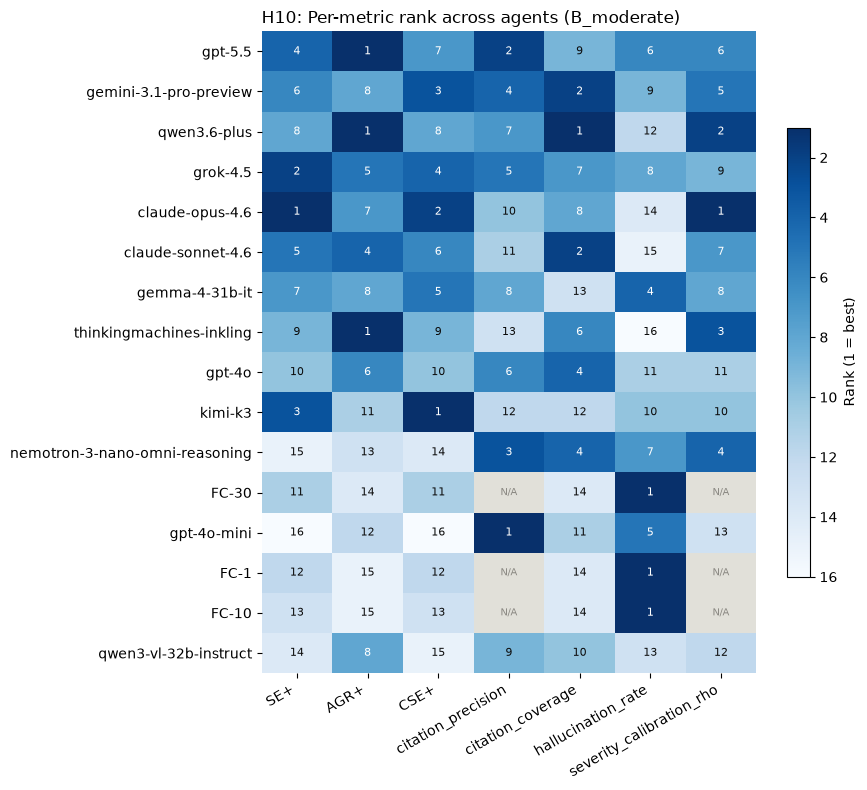

In [35]:
import numpy as np
import matplotlib.pyplot as plt

order = df_h10_rank.sort_values("avg_rank").index.tolist()
rank_matrix = df_h10_rank.loc[order, RANK_METRICS].values.astype(float)
n_agents = len(all_agents)

fig, ax = plt.subplots(figsize=(9, 8))
masked = np.ma.masked_invalid(rank_matrix)
cmap = plt.cm.Blues_r  # 낮은 순위(1등)일수록 진한 색
cmap.set_bad(color="#e1e0d9")  # NaN(FC의 citation 계열 지표)은 회색

im = ax.imshow(masked, cmap=cmap, vmin=1, vmax=n_agents, aspect="auto")

ax.set_xticks(range(len(RANK_METRICS)))
ax.set_xticklabels(RANK_METRICS, rotation=30, ha="right")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)

for i in range(len(order)):
    for j in range(len(RANK_METRICS)):
        val = rank_matrix[i, j]
        if np.isnan(val):
            ax.text(j, i, "N/A", ha="center", va="center", fontsize=7, color="#898781")
        else:
            norm_val = (val - 1) / (n_agents - 1)
            text_color = "white" if norm_val < 0.5 else "#0b0b0b"
            ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Rank (1 = best)")
cbar.ax.invert_yaxis()  # colorbar 위쪽이 1등(가장 좋음)

ax.set_title("H10: Per-metric rank across agents (B_moderate)", fontsize=12, loc="left")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


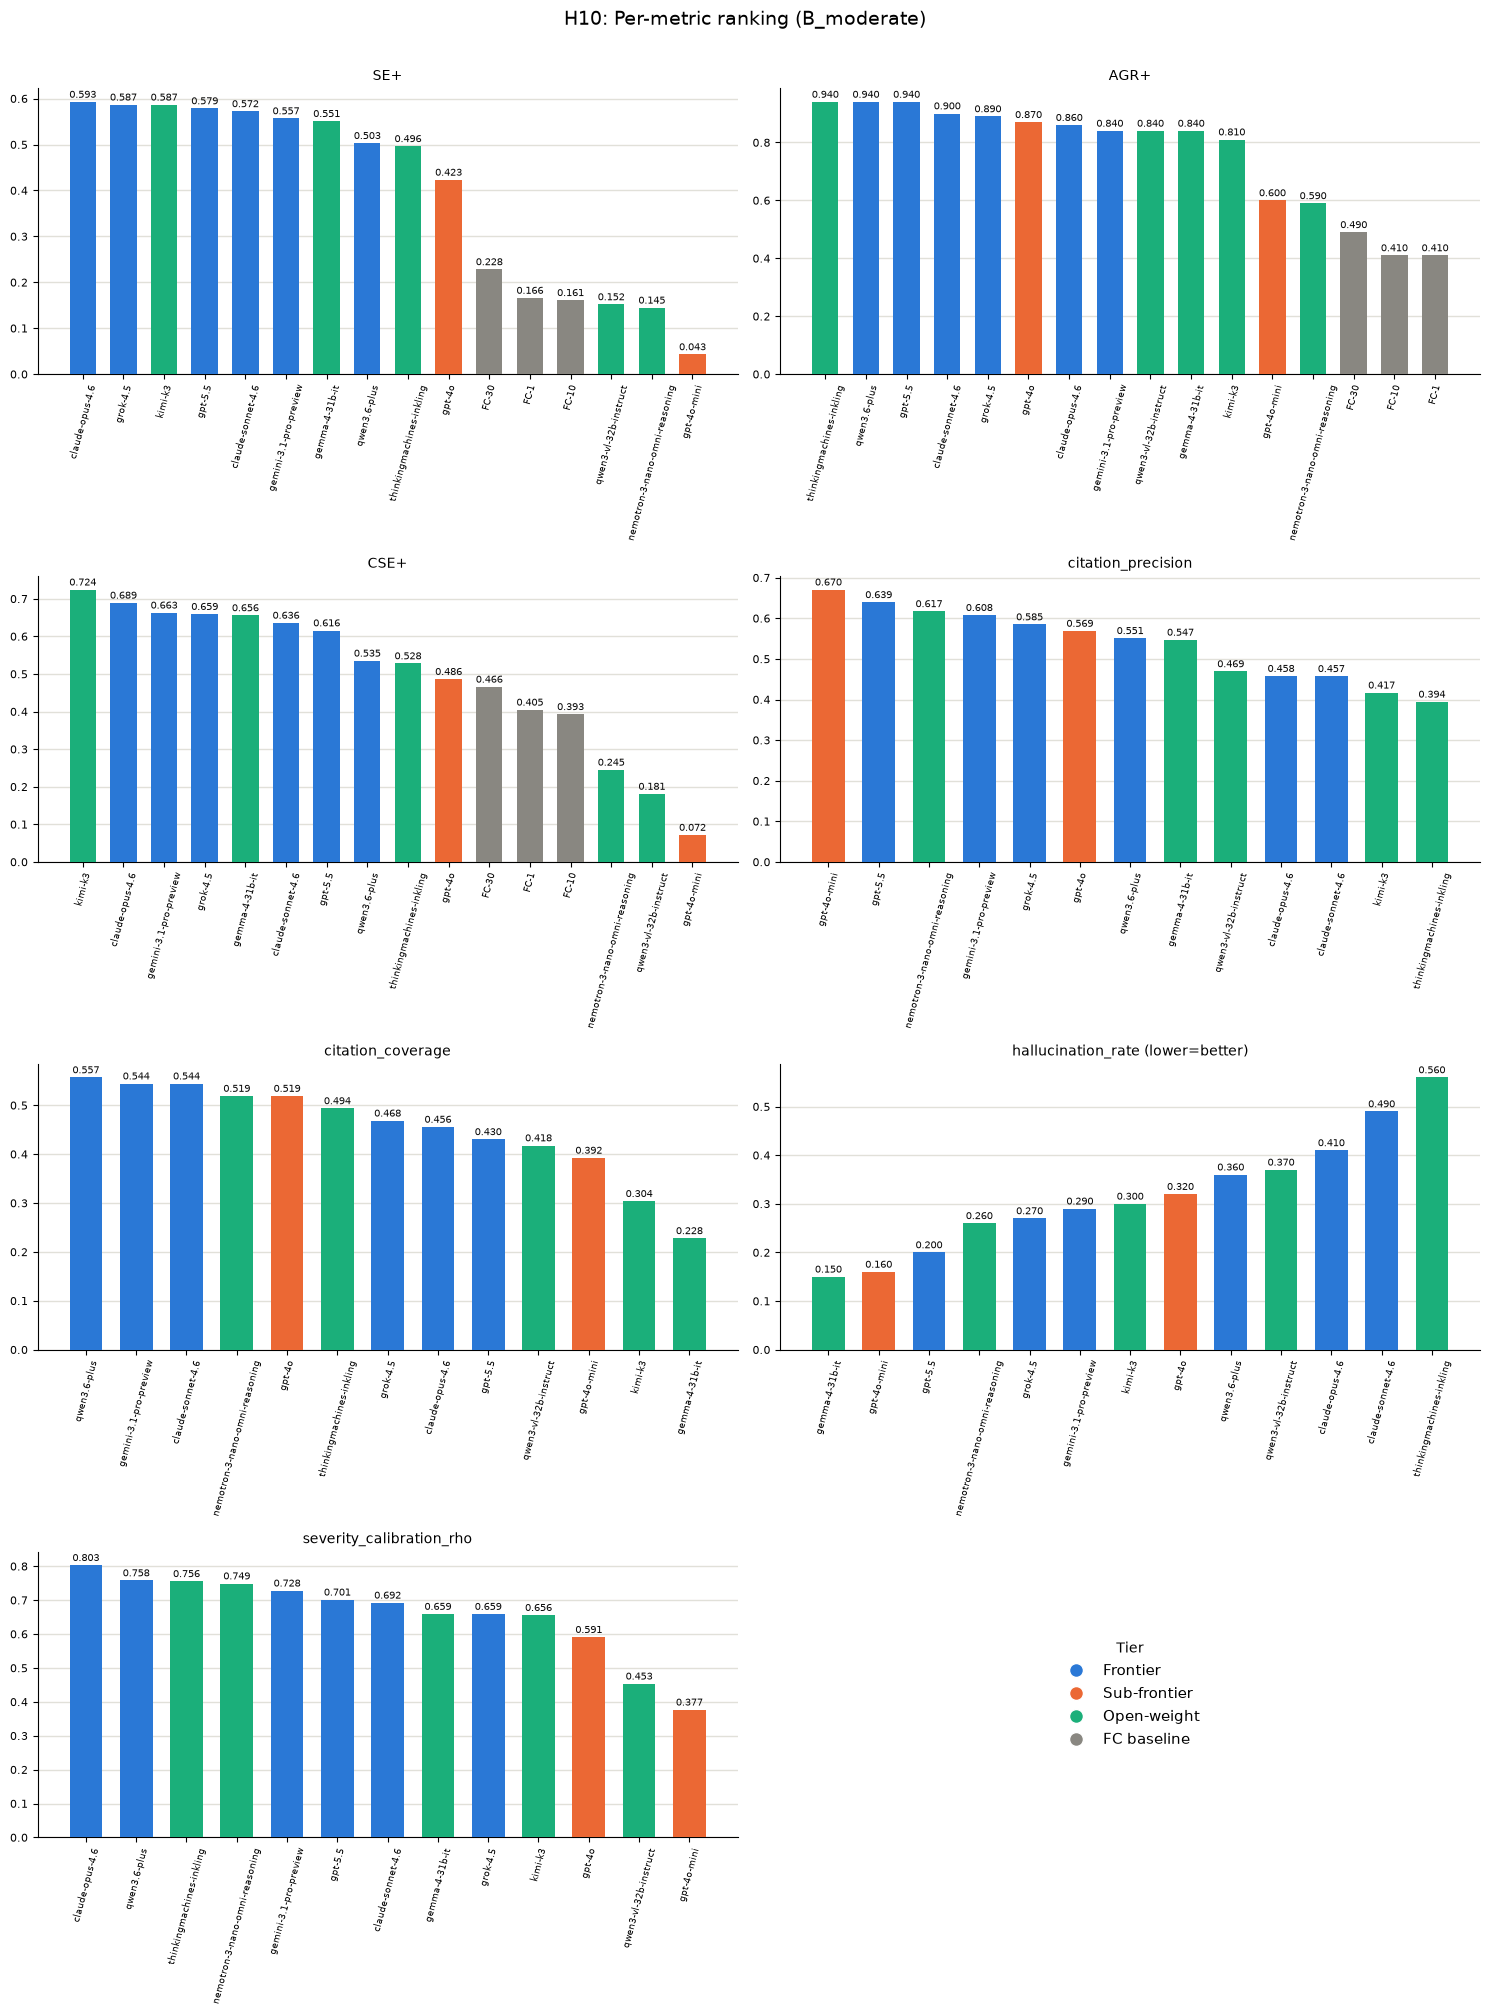

In [36]:
import matplotlib.pyplot as plt

TIER = {
    "FC-1": "FC baseline", "FC-10": "FC baseline", "FC-30": "FC baseline",
    "gpt-4o-mini": "Sub-frontier", "gpt-4o": "Sub-frontier",
    "gemma-4-31b-it": "Open-weight", "qwen3-vl-32b-instruct": "Open-weight",
    "thinkingmachines-inkling": "Open-weight", "nemotron-3-nano-omni-reasoning": "Open-weight",
    "kimi-k3": "Open-weight",
    "claude-opus-4.6": "Frontier", "claude-sonnet-4.6": "Frontier", "gemini-3.1-pro-preview": "Frontier",
    "gpt-5.5": "Frontier", "grok-4.5": "Frontier", "qwen3.6-plus": "Frontier",
}
TIER_COLOR = {"Frontier": "#2a78d6", "Sub-frontier": "#eb6834", "Open-weight": "#1baf7a", "FC baseline": "#898781"}
GRID_COLOR = "#e1e0d9"
LOWER_IS_BETTER = {"hallucination_rate"}
FC_BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
# FC는 애초에 결함을 인용 안 해서 이 4개 지표는 개념적으로 정의 불가 (citation_coverage/
# hallucination_rate는 metrics.py 계산상 0.0이 나오지만, "인용 안 함=0.0"을 "잘함"으로
# 그리면 오해의 소지가 커서 이 지표들에서는 FC를 통째로 제외)
EVIDENCE_METRICS = {"citation_precision", "citation_coverage", "hallucination_rate", "severity_calibration_rho"}

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, metric in enumerate(RANK_METRICS):
    ax = axes[idx]
    vals = df_h10_values[metric].dropna()
    if metric in EVIDENCE_METRICS:
        vals = vals.drop(index=[a for a in FC_BASELINE_AGENTS if a in vals.index])

    higher_is_better = metric not in LOWER_IS_BETTER
    sorted_vals = vals.sort_values(ascending=not higher_is_better)  # 왼쪽=1등이 되도록
    labels = sorted_vals.index.tolist()
    values = sorted_vals.values
    colors = [TIER_COLOR[TIER[a]] for a in labels]

    ax.bar(labels, values, color=colors, width=0.65, zorder=3)
    for label, v in zip(labels, values):
        ax.annotate(f"{v:.3f}", (label, v), textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=7, color="#0b0b0b")

    ax.set_title(metric + (" (lower=better)" if metric in LOWER_IS_BETTER else ""), fontsize=10)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=6.5, rotation=75)
    ax.tick_params(axis="y", labelsize=8)

axes[7].axis("off")
from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=t)
                   for t, c in TIER_COLOR.items()]
axes[7].legend(handles=legend_handles, loc="center", frameon=False, fontsize=11, title="Tier")

fig.suptitle("H10: Per-metric ranking (B_moderate)", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


### H11: 결함 유무 대비 — visual grounding의 값싼 사전 신호

**동기**: 논문의 핵심 novelty는 "시각 증거 활용 역량"인데, 정작 image on/off를
직접 통제하는 `visual_ablation.py`는 예산 문제로 아직 정식 실행 전이다(decisions_log
2026-08-02). 대신 이미 돌려둔 `mapping_robustness` 데이터 안에 **결함이 아예 없는
아이템(100개 중 21개, mapping 전체에 걸쳐 defect_type/quadrant 완전 일치 확인됨)**이
섞여 있다는 걸 이용해서, 추가 API 비용 없이 "agent가 이미지 내용을 실제로 따라가며
인용하는가"를 먼저 봤다. `item.description`은 결함을 절대 자진 공개하지 않으므로
(env.py 설계 전제), 결함 유무에 따라 인용 행동이 달라진다면 그 정보는 이미지에서 온
것이라고 볼 수 있다.

**한계**: 진짜 image on/off 짝비교(같은 episode를 이미지 있이/없이 두 번 돌리는 것)가
아니라 "결함 있는 79개 아이템 집합 vs 없는 21개 아이템 집합"의 비교라, 두 집합의 다른
특성(아이템 카테고리/가격대 등)이 섞여 들어갈 여지가 있다. 정식 검증은 아니고,
예비 신호로만 사용.

**방법**: 13개 LLM agent(FC baseline 제외) 각각에 대해
- `false_citation_rate` = 결함 없는 21개 아이템에서 그래도 뭔가 인용한 episode 비율
  (정의상 전부 할루시네이션)
- `citation_rate` = 결함 있는 79개 아이템에서 인용한 episode 비율
- `gap` = citation_rate − false_citation_rate (클수록 "결함 유무를 구분해서 인용한다")


In [53]:
# mapping에 상관없이 같은 episode_idx가 같은 defect_type/quadrant를 갖는지 먼저 확인
by_idx = {}
for m in MAPPINGS:
    for r in episodes_by_mapping[m]:
        idx = r["episode_idx"]
        sig = tuple((d["defect_type"], d["quadrant"]) for d in r["item"]["defects"])
        by_idx.setdefault(idx, set()).add(sig)

mismatch = sum(1 for sigs in by_idx.values() if len(sigs) > 1)
print(f"mapping 간 defect_type/quadrant 불일치 episode_idx 수: {mismatch} / {len(by_idx)}")

n_with = sum(1 for sigs in by_idx.values() if next(iter(sigs)) != ())
n_without = sum(1 for sigs in by_idx.values() if next(iter(sigs)) == ())
print(f"진짜 아이템 기준 -- 결함 있음: {n_with}, 결함 없음: {n_without}")


mapping 간 defect_type/quadrant 불일치 episode_idx 수: 0 / 100
진짜 아이템 기준 -- 결함 있음: 79, 결함 없음: 21


In [56]:
BASELINE_AGENTS = {"FC-1", "FC-10", "FC-30"}
llm_agents = [a for a in AGENTS if a not in BASELINE_AGENTS]

def agent_citations(rec):
    C = set()
    for t in rec["transcript"]:
        if t["side"] == "agent" and t.get("cited_defect_ids"):
            C.update(t["cited_defect_ids"])
    return C

no_defect_idxs = {idx for idx, sigs in by_idx.items() if next(iter(sigs)) == ()}

rows = []
for agent in llm_agents:
    recs_no_defect = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                       if r["agent"] == agent and not r["violations"]
                       and r["episode_idx"] in no_defect_idxs]
    recs_with_defect = [r for m in MAPPINGS for r in episodes_by_mapping[m]
                         if r["agent"] == agent and not r["violations"]
                         and r["episode_idx"] not in no_defect_idxs]
    n_nd, n_wd = len(recs_no_defect), len(recs_with_defect)
    false_cite_rate = sum(1 for r in recs_no_defect if agent_citations(r)) / n_nd if n_nd else None
    true_cite_rate = sum(1 for r in recs_with_defect if agent_citations(r)) / n_wd if n_wd else None
    rows.append({
        "agent": agent, "n_no_defect": n_nd, "n_with_defect": n_wd,
        "false_citation_rate": false_cite_rate, "citation_rate": true_cite_rate,
    })

df_false_cite = pd.DataFrame(rows)
df_false_cite["gap"] = df_false_cite["citation_rate"] - df_false_cite["false_citation_rate"]
df_false_cite.sort_values("gap", ascending=False)


,agent,n_no_defect,n_with_defect,false_citation_rate,citation_rate,gap
9,nemotron-3-nano-omni-reasoning,56,258,0.107143,0.821705,0.714563
6,gpt-5.5,78,302,0.000000,0.622517,0.622517
7,grok-4.5,82,309,0.085366,0.689320,0.603955
10,qwen3-vl-32b-instruct,39,209,0.205128,0.765550,0.560422
5,gpt-4o-mini,51,231,0.078431,0.597403,0.518971
2,gemini-3.1-pro-preview,82,313,0.207317,0.715655,0.508338
4,gpt-4o,44,278,0.295455,0.751799,0.456344
3,gemma-4-31b-it,78,316,0.025641,0.411392,0.385751
11,qwen3.6-plus,74,311,0.432432,0.800643,0.368211
12,thinkingmachines-inkling,79,304,0.607595,0.907895,0.300300


**표 읽는 법**

- `false_citation_rate`: 결함이 아예 없는 아이템에서 뭐라도 인용한 비율 (전부
  할루시네이션 — 낮을수록 좋음)
- `citation_rate`: 결함이 있는 아이템에서 인용한 비율
- `gap`: 둘의 차이 — 결함 유무에 따라 인용 행동이 실제로 갈리는 정도. 0에 가까우면
  "결함이 있든 없든 비슷하게 인용한다"는 뜻이라 이미지 내용을 근거로 안 쓰고 있다는
  신호

**해석**

- **gpt-5.5**: false_citation_rate=0.000(21개 전부에서 단 한 번도 결함을 지어내지
  않음) — gap=0.623로 상위권. obvious_aligned에서의 협상 전술 약점(H6-2)과는 별개로,
  "없는 걸 있다고 우기지 않는" 신중함은 뚜렷함.
- **nemotron-3-nano-omni-reasoning**: gap=0.715로 13개 중 **1위**. H6-2에서 확인한
  약점(상대가 완강할 때 유보가격까지 끌려감)은 협상 전술 축의 문제였을 뿐, "결함
  유무를 이미지로 구분하는" 축에서는 오히려 최상위 — 지표마다 완전히 다른 능력을 잰다는
  걸 보여주는 사례.
- **claude-opus-4.6**: gap=0.042로 **최하위** — 결함이 있든(64.7%) 없든(60.5%)
  인용률이 거의 같다. H6-1에서 발견한 "subtle_misaligned를 잘 못 잡는다"보다 훨씬
  일반적인 결론: 이 quadrant 문제가 아니라 **결함 존재 여부 자체를 이미지로 구분하는
  능력이 전반적으로 약하다**는 뜻. claude-sonnet-4.6(gap=0.195)도 하위권.

**한 줄 요약**: image on/off 정식 ablation은 아직 안 돌았지만, 이미 있는 데이터의
결함 유무 대비만으로도 agent 간 "이미지 근거 사용도" 격차가 뚜렷하게 나타난다 —
claude 계열이 가장 약하고 nemotron/gpt-5.5가 가장 강함. 정식 visual ablation
실행 전 예비 증거로 논문에 사용 가능.
